# **European Drugs Development**

Team 10: Samuel Buelvas, Chamnan Suon, Gurveen Rekhi, Roberto Albornoz

## **Executive Summary**

Drug development in Europe plays a crucial role in shaping the pharmaceutical industry both in Europe and around the world. By understanding the behaviors of drug development stages and regulatory processes, we could uncover patterns and trends which would ultimately allow companies to better develop business strategies and adjust its internal process in order to optimize the successful implementation of the development.

Preliminary exploratory data analysis (EDA) was conducted on the European Medicines Agency (EMA) dataset to understand the portfolio structure and ensure the data support unsupervised learning. We began by examining authorization trends over time and expanding therapeutic area classifications to observe how the regulatory landscape has evolved. The time-series view highlights periods of acceleration and reveals whether surges in approvals are aligned with specific dominant disease areas or reflect broader diversification, directly informing our investigation into authorization trends.

Next, we assessed market concentration by identifying which marketing authorization holders account for the highest volume of medicines. This step determines whether approvals are broadly distributed across the industry or concentrated among a small group of firms. Understanding this distribution provides a baseline for segmenting companies in later stages, specifically to explore if certain portfolios or regulatory capabilities correlate with higher authorization accumulation.

The project refines its focus to two connected themes: (1) how regulatory pathway combinations (“special approval” flags) relate to authorization outcomes and time trends, and (2) how to restructure veterinary features because many human-only regulatory indicators do not apply to veterinary medicines, requiring separate segmentation logic.

Across Milestones 2–3, the integrated analyses show that drug approvals do not fall into clean, separable clusters; instead, medicines exhibit overlapping regulatory and therapeutic profiles. However, one consistent and actionable structure emerged: special pathways co-occur in repeatable bundles—notably orphan designation, accelerated assessment, conditional approval, and exceptional circumstances—suggesting regulators evaluate applications holistically rather than as independent flags. Additional monitoring appears more independent, aligning more with post-market safety than expedited access.
Outcome analysis indicates that medicines following a standard pathway tend to have lower refusal rates, while accelerated/conditional pathways are associated with higher refusal risk, consistent with higher uncertainty in evidence despite the goal of earlier access. For veterinary products, the dataset is structurally different and more homogeneous (several special approval flags are absent), making clustering on standard regulatory indicators less informative; market basket analysis was more effective in identifying “regulatory recipes” and high-lift feature bundles for veterinary segments.

Methodologically, the team streamlined approaches based on Milestone 2 feedback: k-means and k-modes were deemphasized/removed where categorical dominance and frequency imbalance distorted results, and feature engineering was used cautiously where numeric clustering was attempted. The overall conclusion is that clustering can summarize broad patterns but is not sufficient alone; stronger insight requires combining multiple signals (pathways, therapeutic descriptors, outcomes) and using methods better suited to sparse categorical + text data.

Next steps: extend market basket analysis to human medicines, study revision number vs authorization outcomes, apply text embeddings to therapeutic/indication fields to capture semantics beyond categorical labels, and use anomaly detection to flag unusually structured approved/refused medicines.

Milestone 4 work begins at section: M4 - Market Basket Analysis.

## **Data Dictionary**

 `drugs_dataset.csv`

|Column  |Class      |Description          |
|:-------|:----------|:--------------------|
|category|character | human or veterinary|
|medicine_name | character | brand name of the medicine|
|therapeutic_area | character | semicolon-separated list of therapeutic areas|
|common_name | character | international non-proprietary name (INN) or common name|
|active_substance | character | common name of the active chemical in the drug|
|product_number | character | EMEA/H/C/ (human) or EMEA/V/C/ (veterinary) number for the drug|
|patient_safety | logical | has patient safety notices|
|authorisation_status | character | whether the drug was authorised, withdrawn, or refused (or does not have a reported status)|
|atc_code | character | anatomical therapeutic chemical code|
|additional_monitoring | logical | when true, the medicine is under additional monitoring, meaning that it is monitored even more intensively than other medicines|
|generic | logical | whether the drug is a generic medicine, which is developed to be the same as a medicine that has already been authorised, called the reference medicine. A generic medicine contains the same active substance(s) as the reference medicine, and is used at the same dose(s) to treat the same disease(s)|
|biosimilar | logical | whether the drug is a biosimilar medicine, which is a biological medicine highly similar to another already approved biological medicine called the reference medicine.|
|conditional_approval | logical | whether the medicine received a conditional marketing authorisation. This was granted in the interest of public health because the medicine addresses an unmet medical need and the benefit of immediate availability outweighs the risk from less comprehensive data than normally required.|
|exceptional_circumstances | logical | whether the medicine was authorised under exceptional circumstances, because the applicant was unable to provide comprehensive data on the efficacy and safety of the medicine under normal conditions of use. This can happen because the condition to be treated is rare or because collection of full information is not possible or is unethical.|
|accelerated_assessment | logical | whether the medicine had an accelerated assessment. This means that it is a medicine of major interest for public health, so its timeframe for review was 150 evaluation days rather than 210.|
|orphan_medicine | logical | whether the medicine was designated an orphan medicine. This means that it was developed for use against a rare, life-threatening or chronically debilitating condition or, for economic reasons, it would be unlikely to have been developed without incentives.|
|marketing_authorisation_date | date | date on which the drug was authorised|
|date_of_refusal_of_marketing_authorisation | date | date on which the drug was refused|
|marketing_authorisation_holder_company_name | character | name of the company that is authorised to market the drug|
|pharmacotherapeutic_group | character | the target of the drug|
|date_of_opinion | date | date on which the opinion was made|
|decision_date | date | date on which the latest decision was made|
|revision_number | integer | integer revision number|
|condition_indication | character | language describing the specific uses of the drug|
|species | character | for veterinary medicines, the target species; might benefit from further cleaning|
|first_published | datetime | datetime when the information was first published|
|revision_date | datetime | datetime of the most recent revision|
|url | character | url for details about the drug and submission|

## **Preprocessing**

In [106]:
# Import pandas and numpy for DataFrame and operations
import pandas as pd
import numpy as np
import warnings

# Filter out DeprecationWarning for specific modules
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')
# warnings.filterwarnings("ignore", category=DeprecationWarning, module='matplotlib')
# warnings.filterwarnings("ignore", category=DeprecationWarning, module='pyparsing')

# print("Deprecation warnings are now suppressed.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [107]:
# Load dataset from github relative path
path = "https://raw.githubusercontent.com/SChamnan/ba820-unsupervised-ml-team10-project/refs/heads/main/european-drugs-development/drugs-dataset.csv"
drugs_df = pd.read_csv(path)
drugs_original=drugs_df.copy()
# Check out the first 5 rows of data
drugs_df.head(5)

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Takeda Pharma A/S,Antineoplastic agents,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,Cycle Pharmaceuticals (Europe) Ltd,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,Pierre Fabre Medicament,NaN,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,Roche Registration GmbH,"Immune sera and immunoglobulins,",2021-11-11,2023-02-24,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,2021-11-12T16:30:00Z,2023-03-10T12:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,Novartis Europharm Limited,Immunosuppressants,2014-11-20,2023-01-26,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,2018-06-07T11:59:00Z,2023-03-09T18:53:00Z,https://www.ema.europa.eu/en/medicines/human/E...


### **Data Cleaning and Preprocessing**

In [108]:
# Check number of rows and columns
drugs_df.shape

(1988, 28)

In [109]:
drugs_df.describe()

,product_number,revision_number
count,1988.000000,1892.000000
mean,2634.774145,13.527484
std,1915.734686,11.647056
min,24.000000,0.000000
25%,715.750000,4.750000
50%,2544.500000,11.000000
75%,4351.000000,19.000000
max,6039.000000,89.000000


Below shows number of missing values in each column. These missing values could be either removed or keep as they are. Imputation may not be the best option as it may misrepresenting data.

In [110]:
# Chart showing missing values of each column
missing_values = drugs_df.isnull().sum()
missing_percentage = ((drugs_df.isnull().sum() / len(drugs_df)) * 100).round(2)

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})

display(missing_info.sort_values(by='Missing Count', ascending=False))

,Missing Count,Missing Percentage (%)
date_of_refusal_of_marketing_authorisation,1913,96.23
species,1709,85.97
date_of_opinion,779,39.19
therapeutic_area,285,14.34
revision_number,96,4.83
marketing_authorisation_date,60,3.02
decision_date,45,2.26
pharmacotherapeutic_group,34,1.71
revision_date,29,1.46
atc_code,28,1.41


In [111]:
# Information of values of the variable 'species'
unique_species_with_nan = drugs_df['species'].value_counts(dropna=False)
print("\nUnique values and their counts (including NaN) in 'species' column:")
print(unique_species_with_nan)


Unique values and their counts (including NaN) in 'species' column:
species
NaN                                                                    1709
Dogs                                                                     70
Cats                                                                     28
Pigs                                                                     25
Dogs; Cats                                                               18
Horses                                                                   18
Chicken                                                                  15
Cattle                                                                   10
Cattle; Pigs; Sheep                                                       7
Sheep; Cattle                                                             6
Cats; Dogs                                                                5
Sheep                                                                     5
Rabbits    

In [112]:
# Get the count of all unique values, including NaN, for 'authorisation_status'
unique_auth_status_with_nan = drugs_df['authorisation_status'].value_counts(dropna=False)
print("Unique values and their counts (including NaN) in 'authorisation_status' column:")
print(unique_auth_status_with_nan)

# You can apply the same to other columns as needed, for example 'category'
unique_category_with_nan = drugs_df['category'].value_counts(dropna=False)
print("\nUnique values and their counts (including NaN) in 'category' column:")
print(unique_category_with_nan)

Unique values and their counts (including NaN) in 'authorisation_status' column:
authorisation_status
authorised    1573
withdrawn      357
refused         57
NaN              1
Name: count, dtype: int64

Unique values and their counts (including NaN) in 'category' column:
category
human         1706
veterinary     282
Name: count, dtype: int64


### **Categorization of the Columns**

In [113]:
# Categorize columns type
# Category cols
cat_cols = ["category",
            "medicine_name",
            "common_name",
            "active_substance",
            "authorisation_status",
            "atc_code",
            "marketing_authorisation_holder_company_name"]

#text cols
text_cols = ["condition_indication"]

# id cols
id_cols = ["url", "product_number"]

# list text cols
list_text_cols = ["therapeutic_area",
                  "pharmacotherapeutic_group",
                  "species"]

# Numeric cols
numeric_cols = ["revision_number"]

# Boolean cols
boolean_cols = ["patient_safety",
                "additional_monitoring",
                "generic",
                "biosimilar",
                "conditional_approval",
                "exceptional_circumstances",
                "accelerated_assessment",
                "orphan_medicine",
                ]

# Datetime cols
datetime_cols = ["marketing_authorisation_date",
             "date_of_refusal_of_marketing_authorisation",
             "date_of_opinion",
             "decision_date",
             "revision_date",
             "first_published"]


### **Preparing data for Analysis**

In [114]:

def clean_string_series(s):
    """
    Standard string cleanup:
    - converts to pandas 'string' dtype
    - normalizes whitespace (multiple spaces -> one)
    - trims leading/trailing whitespace
    """
    s = s.astype("string")
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

def to_bool_series(s):
    """
    Robust boolean conversion:
    Handles columns that might be stored as:
    - True/False
    - 1/0
    - 'TRUE'/'FALSE'
    - 'Yes'/'No'
    Missing values are treated as False (safe default for these regulatory flags).
    """
    if s.dtype == bool:
        return s.fillna(False)

    s_str = s.astype("string")
    s_norm = s_str.str.strip().str.lower()

    true_set = {"true", "t", "1", "yes", "y"}
    false_set = {"false", "f", "0", "no", "n", ""}

    out = pd.Series(pd.NA, index=s.index, dtype="boolean")
    out = out.mask(s_norm.isin(true_set), True)
    out = out.mask(s_norm.isin(false_set), False)

    # fallback numeric coercion for any remaining NAs
    if out.isna().any():
        num = pd.to_numeric(s_str, errors="coerce")
        out = out.fillna(num.eq(1))

    return out.fillna(False).astype(bool)

def clean_list_text_column(s):
    """
    Cleanup for semicolon-separated list fields like:
    therapeutic_area, pharmacotherapeutic_group, species.
    - normalizes whitespace
    - standardizes delimiter spacing: "A;B" -> "A; B"
    """
    s = clean_string_series(s)
    s = s.str.replace(r"\s*;\s*", "; ", regex=True)
    return s

def clean_species_column(s):
    """
    Extra cleanup for species:
    - removes parenthetical qualifiers: 'Pigs (for fattening)' -> 'Pigs'
    - standardizes semicolon spacing: 'Dogs;Cats' -> 'Dogs; Cats'
    """
    s = clean_list_text_column(s)
    s = s.str.replace(r"\s*\(.*?\)\s*", "", regex=True).str.strip()
    s = s.str.replace(r"\s*;\s*", "; ", regex=True)
    return s

**clean_string_series(s)**
This function cleans a text column in a consistent way. It converts the column to a string type, replaces multiple spaces with a single space, and removes extra spaces at the beginning and end of each value. This helps avoid errors caused by inconsistent spacing.

**to_bool_series(s)**
This function converts a column into True/False values even if the column is stored in different formats. It can handle values like True/False, 1/0, and text like "yes"/"no" or "true"/"false". Missing values are treated as False to keep regulatory flag columns safe and consistent for later analysis.

**clean_list_text_column(s)**
This function cleans columns that contain lists stored as text using semicolons (for example: "A;B"). It first applies basic text cleaning (spacing and trimming). Then it standardizes the semicolon format so items are separated as "; " (semicolon + one space). This makes splitting the list later more reliable.

**clean_species_column(s)**
This function is a specialized cleaner for the species column. It applies the semicolon list cleaning, removes extra text written inside parentheses (for example: "Pigs (for fattening)" becomes "Pigs"), and standardizes semicolon spacing again. This produces a cleaner and more consistent species field for later grouping and analysis.

### **Cleaning & Type casting columns**

In [115]:
drugs_df = drugs_df.copy()

# Clean category/text/id columns (trim + normalize spacing)
for c in (cat_cols + text_cols + id_cols):
    if c in drugs_df.columns:
        drugs_df[c] = clean_string_series(drugs_df[c])

# Clean list-text columns
for c in list_text_cols:
    if c in drugs_df.columns:
        if c == "species":
            drugs_df[c] = clean_species_column(drugs_df[c])
        else:
            drugs_df[c] = clean_list_text_column(drugs_df[c])

# Standardize small categorical fields
if "category" in drugs_df.columns:
    drugs_df["category"] = drugs_df["category"].astype("string").str.lower().str.strip()

if "authorisation_status" in drugs_df.columns:
    drugs_df["authorisation_status"] = drugs_df["authorisation_status"].astype("string").str.lower().str.strip()

if "atc_code" in drugs_df.columns:
    drugs_df["atc_code"] = drugs_df["atc_code"].astype("string").str.upper().str.strip()

# Cast booleans group
for c in boolean_cols:
    if c in drugs_df.columns:
        drugs_df[c] = to_bool_series(drugs_df[c])


# Cast numeric group
for c in numeric_cols:
    if c in drugs_df.columns:
        drugs_df[c] = pd.to_numeric(drugs_df[c], errors="coerce").astype("Int64")


# Cast datetimes group
for c in datetime_cols:
    if c in drugs_df.columns:
        drugs_df[c] = pd.to_datetime(drugs_df[c], errors="coerce")


# Quick checks
print("Category counts:\n", drugs_df["category"].value_counts(dropna=False), "\n")
print("Status counts:\n", drugs_df["authorisation_status"].value_counts(dropna=False), "\n")
if "species" in drugs_df.columns:
    print("Top species values:\n", drugs_df["species"].value_counts(dropna=False).head(10))


Category counts:
 category
human         1706
veterinary     282
Name: count, dtype: Int64 

Status counts:
 authorisation_status
authorised    1573
withdrawn      357
refused         57
<NA>             1
Name: count, dtype: Int64 

Top species values:
 species
<NA>                   1709
Dogs                     71
Pigs                     36
Cats                     28
Dogs; Cats               18
Horses                   18
Chicken                  15
Cattle                   12
Cattle; Pigs; Sheep       7
Sheep; Cattle             6
Name: count, dtype: Int64


**Clean category/text/id columns**
Since text fields can include extra spaces or inconsistent spacing, we clean these columns by standardizing whitespace and trimming leading and trailing spaces.

**Clean list-text columns**
Since some fields store multiple values in one cell using semicolons, we standardize the formatting of these list-style columns so they are consistent. For species, we also remove text inside parentheses to keep the names clean.

**Standardize small categorical fields**
Since category and authorisation_status may appear with different capitalization or spaces, we convert them to lowercase and trim spaces. Since atc_code should follow a consistent code format, we convert it to uppercase and trim spaces.

**Cast columns (booleans, numeric, and datetime)**
Since some columns may be stored with inconsistent data types (for example, booleans as text, numbers as strings, or dates in mixed formats), we convert boolean, numeric, and datetime columns into consistent types. Any values that cannot be converted are set to missing to avoid errors in later analysis.

**Quick checks**
Since we want to confirm the cleaning worked, we print basic value counts for category, authorisation_status, and the most common species values.

### **Create Derived columns for Analysis**

In [116]:
# Shared / Computed derived columns
drugs_df["category_clean"] = drugs_df["category"].astype("string").str.strip().str.lower().fillna("unknown")
drugs_df["authorisation_status_clean"] = drugs_df["authorisation_status"].astype("string").str.strip().str.lower().fillna("unknown")

drugs_df["is_veterinary"] = (drugs_df["category_clean"] == "veterinary").astype(int)
drugs_df["is_authorised"] = (drugs_df["authorisation_status_clean"] == "authorised").astype(int)
drugs_df["is_withdrawn"]  = (drugs_df["authorisation_status_clean"] == "withdrawn").astype(int)
drugs_df["is_refused"]    = (drugs_df["authorisation_status_clean"] == "refused").astype(int)


# Map diseases being targeted (Indication NLP readiness)
drugs_df["condition_indication_clean"] = (
    drugs_df["condition_indication"]
      .fillna("")
      .astype("string")
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
      .str.lower()
)
drugs_df["indication_length"] = drugs_df["condition_indication_clean"].str.len().astype(int)

# Helpful for interpretation later
drugs_df["therapeutic_area_list"] = drugs_df["therapeutic_area"].apply(
    lambda x: [] if pd.isna(x) or str(x).strip() == ""
    else sorted(set([p.strip().lower() for p in str(x).split(";") if p.strip()]))
)
drugs_df["therapeutic_area_count"] = drugs_df["therapeutic_area_list"].apply(len).astype(int)
drugs_df["missing_therapeutic_area"] = drugs_df["therapeutic_area"].isna().astype(int)

drugs_df["atc_code_clean"] = drugs_df["atc_code"].astype("string").str.strip().str.upper()
drugs_df["atc_level1"] = drugs_df["atc_code_clean"].str[0]
drugs_df["atc_level2"] = drugs_df["atc_code_clean"].str[:3].where(drugs_df["atc_code_clean"].str.len() >= 3, pd.NA)
drugs_df["missing_atc_code"] = drugs_df["atc_code"].isna().astype(int)

# What types of medicines get special approvals?
pathway_cols = [
    "orphan_medicine",
    "accelerated_assessment",
    "conditional_approval",
    "exceptional_circumstances",
    "additional_monitoring",
]

drugs_df["special_pathway_count"] = drugs_df[pathway_cols].sum(axis=1).astype(int)

drugs_df["pharm_group_list"] = drugs_df["pharmacotherapeutic_group"].apply(
    lambda x: [] if pd.isna(x) or str(x).strip() == ""
    else sorted(set([p.strip().lower() for p in str(x).split(";") if p.strip()]))
)

def make_pathway_profile(row):
    active = [c for c in pathway_cols if bool(row[c])]
    return "+".join(active) if active else "none"

drugs_df["pathway_profile"] = drugs_df.apply(make_pathway_profile, axis=1)

# Human vs veterinary + veterinary species segmentation
drugs_df["species_clean"] = np.where(
    drugs_df["category_clean"] == "human",
    "human",
    drugs_df["species"].astype("string").str.strip()
)

drugs_df["missing_species_vet"] = (
    (drugs_df["category_clean"] == "veterinary") & (drugs_df["species_clean"].isna())
).astype(int)

drugs_df["species_clean"] = np.where(
    (drugs_df["category_clean"] == "veterinary") & (drugs_df["species_clean"].isna()),
    "unknown",
    drugs_df["species_clean"]
)

drugs_df["species_list"] = drugs_df["species_clean"].apply(
    lambda v: [] if pd.isna(v) or v in ["human", "unknown", ""]
    else sorted(set([p.strip().lower() for p in str(v).split(";") if p.strip()]))
)
drugs_df["species_count"] = drugs_df["species_list"].apply(len).astype(int)
drugs_df["multi_species_flag"] = (drugs_df["species_count"] > 1).astype(int)

drugs_df["missing_atc2"] = drugs_df["atc_level2"].isna().astype(int)
drugs_df["missing_pg"] = drugs_df["pharm_group_list"].apply(lambda x: 1 if (not isinstance(x, list) or len(x)==0) else 0)
drugs_df[["missing_atc2","missing_pg"]].mean().to_frame("pct").mul(100).round(2)

# Missingness flags for clustering diagnostics
drugs_df["missing_atc2"] = drugs_df["atc_level2"].isna().astype(int)
drugs_df["missing_pg"] = drugs_df["pharm_group_list"].apply(
    lambda x: 1 if (not isinstance(x, list) or len(x)==0) else 0
)

# Quick checks
print("Derived status flag sum counts:\n",
      (drugs_df[["is_authorised", "is_withdrawn", "is_refused"]].sum(axis=1)).value_counts(dropna=False))

print("\nMissing species in veterinary rows:", drugs_df["missing_species_vet"].sum())
print("\nTop species_clean values:\n", drugs_df["species_clean"].value_counts(dropna=False).head(10))


Derived status flag sum counts:
 1    1987
0       1
Name: count, dtype: int64

Missing species in veterinary rows: 3

Top species_clean values:
 species_clean
human                  1706
Dogs                     71
Pigs                     36
Cats                     28
Dogs; Cats               18
Horses                   18
Chicken                  15
Cattle                   12
Cattle; Pigs; Sheep       7
Sheep; Cattle             6
Name: count, dtype: int64


**Clean and standardize key categorical fields**
Since categories may have extra spaces or different capitalization, we create category_clean by trimming, converting to lowercase, and replacing missing values with "unknown" so values like “Human” and “human” are treated the same.

Since authorisation_status is used to compare outcomes across medicines, we create authorisation_status_clean by trimming, converting to lowercase, and replacing missing values with "unknown" to support reliable grouping and analysis.

**Create simple indicator (0/1) variables**
Since unsupervised methods work better with numeric inputs than text labels, we create is_veterinary as a 0/1 indicator based on category_clean.

Since we often need quick counts by status, we create is_authorised, is_withdrawn, and is_refused as 0/1 indicators from authorisation_status_clean, where "unknown" results in all three indicators being 0.

**Prepare indication text for NLP and quality checks**
Since condition_indication is free text with inconsistent spacing and casing, we create condition_indication_clean by filling missing values with an empty string, normalizing spaces, trimming, and converting to lowercase so it is ready for NLP steps.

Since indications can be very short or very long, we compute indication_length as the character length of condition_indication_clean to support basic checks and descriptive analysis.

**Therapeutic area processing**
Since therapeutic_area is stored as a semicolon-separated list, we create therapeutic_area_list by splitting on semicolons, trimming and lowercasing items, and removing duplicates to get a clean set of areas per medicine.

Since medicines can be linked to one or many therapeutic areas, we compute therapeutic_area_count to measure how many areas each medicine has.

Since missing therapeutic_area values may affect interpretation, we create missing_therapeutic_area as a 0/1 indicator to track where this field is absent.

**ATC code standardization and hierarchy**
Since ATC codes can have inconsistent formatting, we create atc_code_clean by trimming and converting to uppercase so codes match consistently.

Since ATC codes are hierarchical, we create atc_level1 (first character) and atc_level2 (first three characters) to support analysis at different levels.

Since some medicines may not have an ATC code recorded, we create missing_atc_code as a 0/1 indicator to track missingness.

**Special regulatory pathway features**
Since a medicine can have multiple pathway flags at the same time, we compute special_pathway_count by summing these flags to measure how many special pathways apply.

Since it is useful to interpret the exact combination of pathways, we create pathway_profile as a label listing all active pathway flags for each medicine.

**Species cleaning and veterinary segmentation**
Since species is not applicable for human medicines, we set species_clean to "human" when category_clean is "human" so it is not treated as missing.

Since some veterinary medicines have missing species values, we create missing_species_vet to flag veterinary rows where species is missing.

Since veterinary rows should have an explicit value even when species is missing, we replace missing veterinary species values with "unknown" in species_clean.

Since species may include multiple values separated by semicolons, we create species_list by splitting, trimming, lowercasing, and removing duplicates to form a clean list per medicine.

Since multi-species products may behave differently than single-species products, we compute species_count and multi_species_flag to measure and flag medicines that target more than one species.

**Quick checks**
Since we need to confirm the derived status flags behave as expected, we print the distribution of the sum of is_authorised, is_withdrawn, and is_refused to verify most rows have exactly one active status and "unknown" rows have zero.

Since we want to confirm veterinary species missingness is small and isolated, we print the total count of missing_species_vet.

Since we want a quick view of species after cleaning, we print the most common values in species_clean.

#### **Further feature engineering**
Some feature engineering is needed to apply unsupervise ML methods to make a more in depth research, it is presented below.

In [117]:
# Step 1
# Using a different dataframe to avoid damaging the already cleaned one
df = drugs_df.copy()

# Pre-selecting features
features = df[[
    "category",
    "therapeutic_area",
    "atc_code",
    "generic",
    "biosimilar",
    "conditional_approval",
    "exceptional_circumstances",
    "accelerated_assessment",
    "orphan_medicine",
    "additional_monitoring",
    "patient_safety",
    "authorisation_status",
    "marketing_authorisation_date"
]].copy() # Features that can represent similarity

# Step 2
# Columns to encode from boolean to dummy
bool_cols = [
    "generic",
    "biosimilar",
    "conditional_approval",
    "exceptional_circumstances",
    "accelerated_assessment",
    "orphan_medicine",
    "additional_monitoring",
    "patient_safety"
]
features[bool_cols] = features[bool_cols].astype(int)

# Step 3
# Creating a regulatory complexity score to capture intensity of regulatory oversight and special approval pathways
features["regulatory_complexity_score"] = (
    features["conditional_approval"]
    + features["exceptional_circumstances"]
    + features["accelerated_assessment"]
    + features["orphan_medicine"]
    + features["additional_monitoring"]
)

# Step 4
# Retrieving the most common therapeutic areas to find patterns on this dimention
features["therapeutic_area_list"] = (
    features["therapeutic_area"]
    .fillna("")
    .str.split(";")
)

from collections import Counter

# Counting therapeutic areas
area_counts = Counter(
    area.strip()
    for sublist in features["therapeutic_area_list"]
    for area in sublist if area
)

area_counts.most_common(15)

# Selecting the top 20 - there were 1988 different possible combinations, to avoid an exesive amount columns, most of those had only 1 observations
top_areas = [a for a, _ in area_counts.most_common(20)]

for area in top_areas:
    features[f"ta_{area}"] = features["therapeutic_area_list"].apply(
        lambda x: int(area in x)
    )
# Removing the features used for encoding
features.drop(columns=["therapeutic_area", "therapeutic_area_list"], inplace=True)

# Step 5
# Using ATC to retrieve important information about grouping
features["atc_lvl1"] = features["atc_code"].str[0]
features.drop(columns=["atc_code"], inplace=True)

# Generating dummies
features = pd.get_dummies(features, columns=["atc_lvl1"], prefix="atc")

# Step 6
# Distinguishing drugs for humans and animals
features = pd.get_dummies(features, columns=["category"], prefix="cat")

# Authorization status
features = pd.get_dummies(features, columns=["authorisation_status"], prefix="auth")
# Authorization status may reflect post-approval outcomes rather than intrinsic drug characteristics. I include it experimentally to its impact afterwards

# Step 7
# Retieving the year of authorization - the date itself can't be used for clustering
features["auth_year"] = pd.to_datetime(
    df["marketing_authorisation_date"],
    errors="coerce"
).dt.year

features.drop(columns=["marketing_authorisation_date"], inplace=True)

# Step 8
# Filtering the data for clustering
X = features.drop(columns=["auth_year"])
X = X.fillna(0)

# Step 9
# Normalizing the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

### **Data Overview After Cleaning**

In [118]:
# show size, missingness, imbalance, and what fields are “strong enough” to analyze.
# Shape
print("Rows, Columns:", drugs_df.shape)

# Missingness table (top missing)
missing = drugs_df.isna().mean().sort_values(ascending=False).to_frame("missing_pct")
missing["missing_pct"] = (missing["missing_pct"] * 100).round(2)
print(missing.head(15))

# Uniqueness checks
print("Unique product_number:", drugs_df["product_number"].nunique(dropna=False))
print("Unique url:", drugs_df["url"].nunique(dropna=False))

Rows, Columns: (1988, 53)
                                             missing_pct
date_of_refusal_of_marketing_authorisation         96.23
species                                            85.97
date_of_opinion                                    39.19
therapeutic_area                                   14.34
revision_number                                     4.83
marketing_authorisation_date                        3.02
decision_date                                       2.26
pharmacotherapeutic_group                           1.71
revision_date                                       1.46
atc_code                                            1.41
atc_level1                                          1.41
atc_level2                                          1.41
atc_code_clean                                      1.41
condition_indication                                0.60
marketing_authorisation_holder_company_name         0.20
Unique product_number: 1932
Unique url: 1988


In [119]:
drugs_df.head()

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,special_pathway_count,pharm_group_list,pathway_profile,species_clean,missing_species_vet,species_list,species_count,multi_species_flag,missing_atc2,missing_pg
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,1,[antineoplastic agents],orphan_medicine,human,0,[],0,0,0,0
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,0,"[other alimentary tract and metabolism products,]",none,human,0,[],0,0,0,0
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,<NA>,True,...,3,[],orphan_medicine+exceptional_circumstances+addi...,human,0,[],0,0,1,1
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,1,"[immune sera and immunoglobulins,]",additional_monitoring,human,0,[],0,0,0,0
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis, ...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,0,[immunosuppressants],none,human,0,[],0,0,0,0


Dataset is cleaned and is ready for next steps.

## **Exploratory Data Analysis**

### **Authorized drugs trend over time**

Viewing trend of drugs being authorized to be marketed over time.

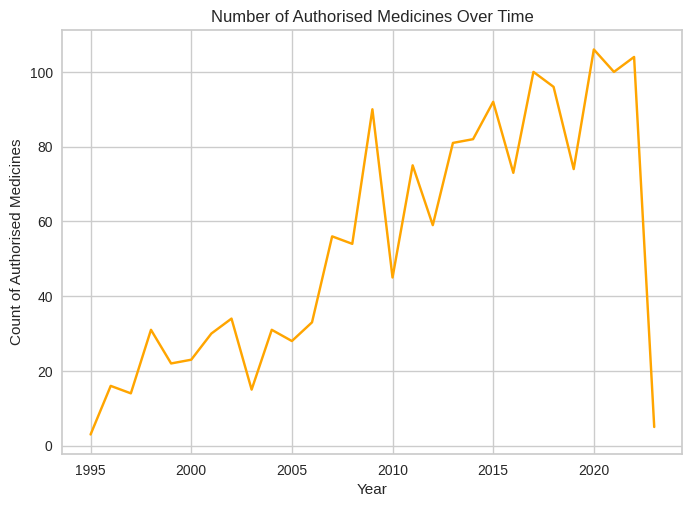

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns
##### Check out drugs authorized drugs trend overtime #####
# Authorised medicines only
authorised_df = drugs_df[drugs_df["authorisation_status_clean"] == "authorised"].copy()

# Year of authorisation
authorised_df["authorised_year"] = authorised_df["marketing_authorisation_date"].dt.year

# Count per year (drop NaN years)
authorised_per_year = authorised_df["authorised_year"].dropna().value_counts().sort_index()

plt.figure()
authorised_per_year.plot(kind="line", color='orange')
plt.title("Number of Authorised Medicines Over Time")
plt.xlabel("Year")
plt.ylabel("Count of Authorised Medicines")
plt.show()

In [121]:
drugs_df['authorisation_status'].value_counts()

,count
authorisation_status,
authorised,1573
withdrawn,357
refused,57


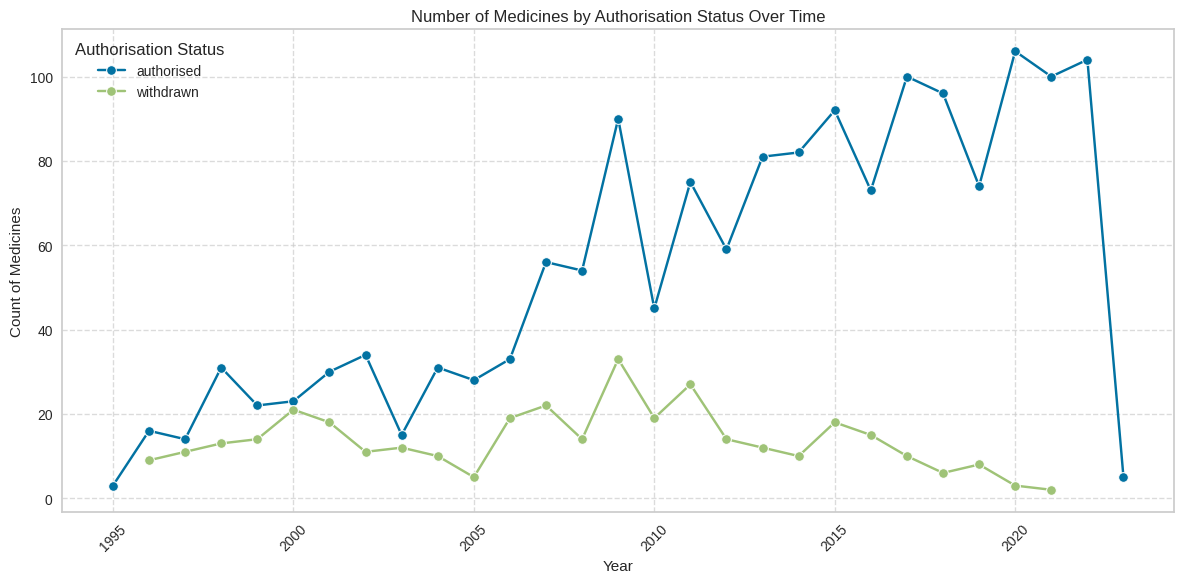

In [122]:
# Extract the year of authorisation
drugs_df["authorised_year"] = drugs_df["marketing_authorisation_date"].dt.year
# Group by authorised_year and authorisation_status_clean and count medicines
authorised_status_per_year = drugs_df.groupby(["authorised_year", "authorisation_status"]).size().reset_index(name='count')
# Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=authorised_status_per_year,
    x="authorised_year",
    y="count",
    hue="authorisation_status",
    marker='o' # Add markers for data points
)
plt.title("Number of Medicines by Authorisation Status Over Time")
plt.xlabel("Year")
plt.ylabel("Count of Medicines")
plt.xticks(rotation=45)
plt.legend(title="Authorisation Status")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Top companies with most authorised medicines**

Viewing list of top 10 companies with the most authorized medicines.

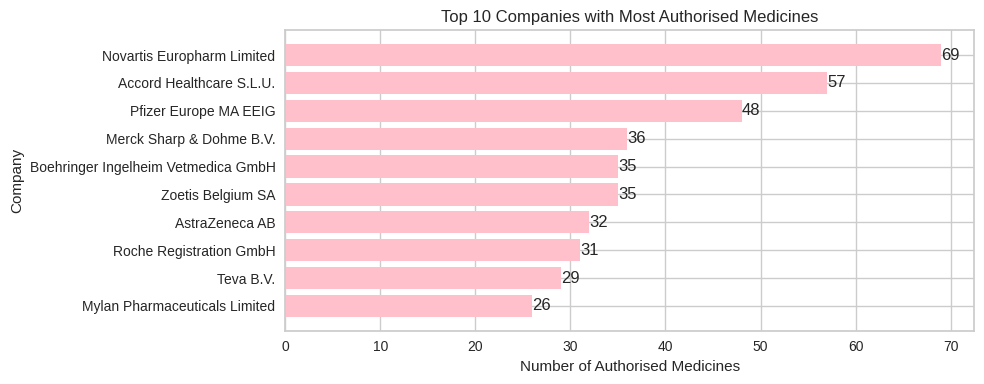

In [123]:
##### Check out companies with the most authorized medicines #####
authorised_df = drugs_df[drugs_df["authorisation_status_clean"] == "authorised"].copy()

company_counts = (
authorised_df["marketing_authorisation_holder_company_name"]
.value_counts()
.head(10)
.sort_values() # sort for barh readability
)

plt.figure(figsize=(10, 4))
plt.barh(company_counts.index, company_counts.values, color='pink')

# Add number on each bar for better readability
for i, v in enumerate(company_counts):
  plt.text(v, i, str(v), va='center')

plt.xlabel("Number of Authorised Medicines")
plt.ylabel("Company")
plt.title("Top 10 Companies with Most Authorised Medicines")
plt.tight_layout()
plt.show()

### **Top therapeutic areas by authorised medicines**

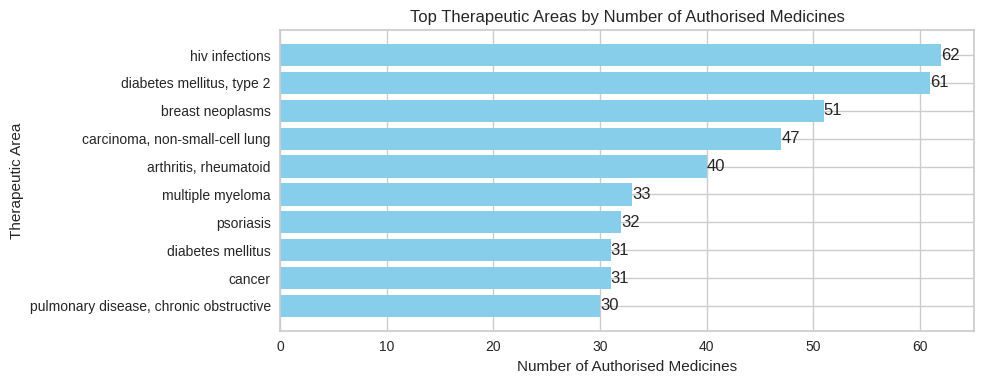

In [124]:
# Filter to get only authorized medicines
authorised_df = drugs_df[drugs_df["authorisation_status_clean"] == "authorised"].copy()

therapeutic_counts = (
authorised_df.explode("therapeutic_area_list")["therapeutic_area_list"]
.dropna()
.value_counts()
.head(10)
.sort_values()
)

# Plot bar graph
plt.figure(figsize=(10, 4))
plt.barh(therapeutic_counts.index, therapeutic_counts.values, color='skyblue')

# Add number on each bar for better readability
for i, v in enumerate(therapeutic_counts.values):
    plt.text(v, i, str(v), va='center')

plt.xlabel("Number of Authorised Medicines")
plt.ylabel("Therapeutic Area")
plt.title("Top Therapeutic Areas by Number of Authorised Medicines")
plt.tight_layout()
plt.show()

### **Patterns of Special Approvals and Overlap**

builds on (1–3) by asking whether approvals are “standard” or concentrated in special regulatory pathways, and whether those pathways form natural profiles for segmentation.


Special-pathway flag prevalence (share of medicines):
additional_monitoring        19.47%
orphan_medicine               8.15%
accelerated_assessment        2.41%
conditional_approval          2.41%
exceptional_circumstances     2.41%
dtype: object

Distribution of special_pathway_count:
special_pathway_count
0    1500
1     338
2      96
3      53
4       1
Name: count, dtype: int64

Most common pathway profiles:
pathway_profile
none                                                                 1500
additional_monitoring                                                 251
orphan_medicine                                                        50
orphan_medicine+additional_monitoring                                  50
orphan_medicine+conditional_approval+additional_monitoring             26
accelerated_assessment                                                 24
orphan_medicine+exceptional_circumstances+additional_monitoring        18
conditional_approval+additional_monitoring       

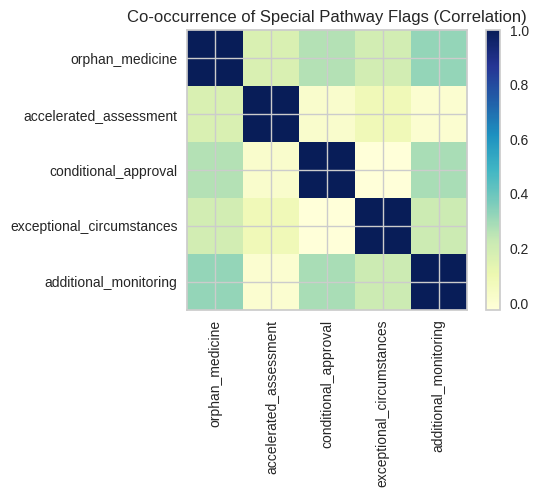

In [125]:

pathway_cols = [
    "orphan_medicine",
    "accelerated_assessment",
    "conditional_approval",
    "exceptional_circumstances",
    "additional_monitoring",
]

# How common is each special pathway flag?
flag_rates = drugs_df[pathway_cols].mean().sort_values(ascending=False)
print("Special-pathway flag prevalence (share of medicines):")
print((flag_rates * 100).round(2).astype(str) + "%")

# How many special flags per medicine?
print("\nDistribution of special_pathway_count:")
print(drugs_df["special_pathway_count"].value_counts().sort_index())

# Most common pathway combinations
print("\nMost common pathway profiles:")
print(drugs_df["pathway_profile"].value_counts().head(15))

# Co-occurrence (do flags tend to appear together?)
corr = drugs_df[pathway_cols].astype(int).corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr, interpolation="nearest", cmap="YlGnBu")
plt.xticks(range(len(pathway_cols)), pathway_cols, rotation=90)
plt.yticks(range(len(pathway_cols)), pathway_cols)
plt.title("Co-occurrence of Special Pathway Flags (Correlation)")
plt.colorbar()
plt.tight_layout()
plt.show()

### **Special approvals look different across categories and species**

It compares the regulatory “signal” across human vs veterinary, then zooming into veterinary species segmentation.


Special-pathway flag rates by category (mean of boolean flags):
                orphan_medicine  accelerated_assessment  conditional_approval  \
category_clean                                                                  
human                     0.095                   0.023                 0.028   
veterinary                0.000                   0.028                 0.000   

                exceptional_circumstances  additional_monitoring  
category_clean                                                    
human                               0.026                  0.227  
veterinary                          0.011                  0.000  


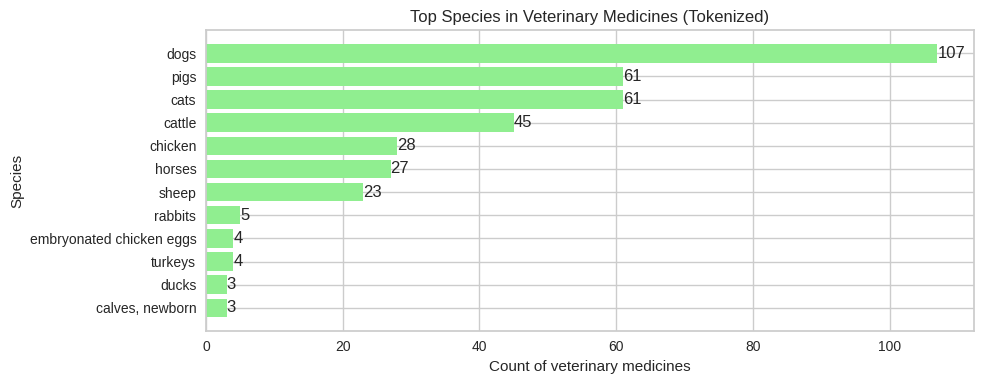


Share of veterinary medicines that target multiple species:
0.277


In [126]:
# Compare special-pathway rates across human vs veterinary
print("Special-pathway flag rates by category (mean of boolean flags):")
print(drugs_df.groupby("category_clean")[pathway_cols].mean().round(3))

# Veterinary-only: species distribution (tokenized list)
vet_df = drugs_df[drugs_df["category_clean"] == "veterinary"].copy()

species_counts = (
    vet_df.explode("species_list")["species_list"]
    .dropna()
    .value_counts()
    .head(12)
    .sort_values()
)

plt.figure(figsize=(10, 4))
plt.barh(species_counts.index, species_counts.values, color="lightgreen")
# Add number on each bar for better readability
for i, v in enumerate(species_counts.values):
    plt.text(v, i, str(v), va='center')
plt.xlabel("Count of veterinary medicines")
plt.ylabel("Species")
plt.title("Top Species in Veterinary Medicines (Tokenized)")
plt.tight_layout()
plt.show()

# Multi-species structure (useful segmentation signal)
print("\nShare of veterinary medicines that target multiple species:")
print(vet_df["multi_species_flag"].mean().round(3))

### **Variability for NLP clustering**

Unstructured text that will power unsupervised discovery of disease/indication clusters.

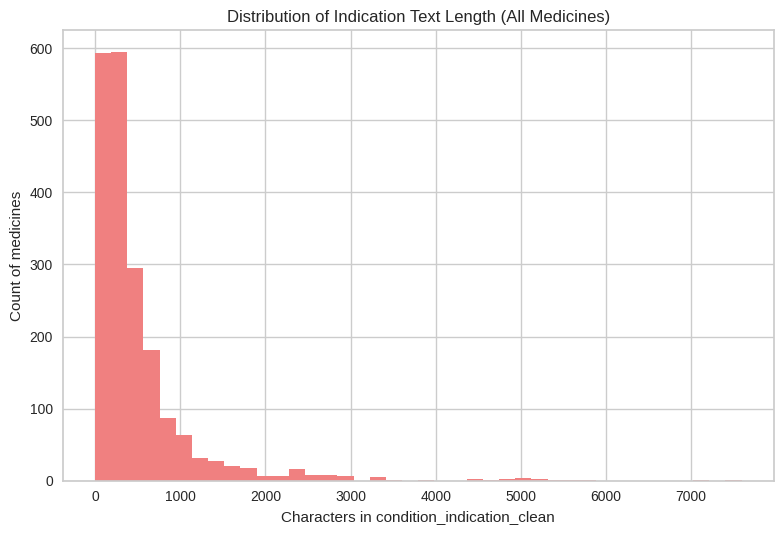


Indication length summary by category_clean:
                 count        mean    50%     max
category_clean                                   
human           1706.0  519.284877  299.5  7592.0
veterinary       282.0  431.574468  291.0  2513.0

Indication length summary by authorisation_status_clean:
                             count        mean    50%     max
authorisation_status_clean                                   
authorised                  1573.0  526.957406  311.0  7592.0
refused                       57.0  112.824561   40.0   971.0
unknown                        1.0    0.000000    0.0     0.0
withdrawn                    357.0  482.546218  301.0  4513.0

Top 25 words in authorised indication text:
[('with', 3636), ('and', 3403), ('the', 3314), ('for', 2839), ('treatment', 2527), ('patients', 2154), ('indicated', 2011), ('adult', 1088), ('who', 1018), ('combination', 956), ('have', 733), ('are', 603), ('therapy', 593), ('not', 572), ('adults', 541), ('years', 481), ('disea

In [127]:
from collections import Counter

# Distribution of text length
plt.figure()
plt.hist(drugs_df["indication_length"].dropna(), bins=40, color="lightcoral")
plt.title("Distribution of Indication Text Length (All Medicines)")
plt.xlabel("Characters in condition_indication_clean")
plt.ylabel("Count of medicines")
plt.tight_layout()
plt.show()

# Text length summaries by category and status
print("\nIndication length summary by category_clean:")
print(drugs_df.groupby("category_clean")["indication_length"].describe()[["count", "mean", "50%", "max"]])

print("\nIndication length summary by authorisation_status_clean:")
print(drugs_df.groupby("authorisation_status_clean")["indication_length"].describe()[["count", "mean", "50%", "max"]])

# Lightweight top-words check (gives intuition about recurring themes)
def top_words(series, n=25, min_len=3):
    words = []
    for txt in series:
        tokens = str(txt).split()
        tokens = [t for t in tokens if len(t) >= min_len]
        words.extend(tokens)
    return Counter(words).most_common(n)

authorised_df = drugs_df[drugs_df["authorisation_status_clean"] == "authorised"].copy()
withdrawn_df = drugs_df[drugs_df["authorisation_status_clean"] == "withdrawn"].copy()

print("\nTop 25 words in authorised indication text:")
print(top_words(authorised_df["condition_indication_clean"], n=25))

print("\nTop 25 words in withdrawn indication text:")
print(top_words(withdrawn_df["condition_indication_clean"], n=25))

## **In depth Analysis**

### **Question 1: Regulatory Paths**

How common are special regulatory pathways, such as orphan designation, accelerated assessment, conditional approval, exceptional circumstances, additional monitoring, and do these flags tend to appear together in recurring combinations?

‎

Moving forward with the question we will be using clustering to dive understand which special approvals are seen most often together.

#### **Exploring Hierarchical Clustering**

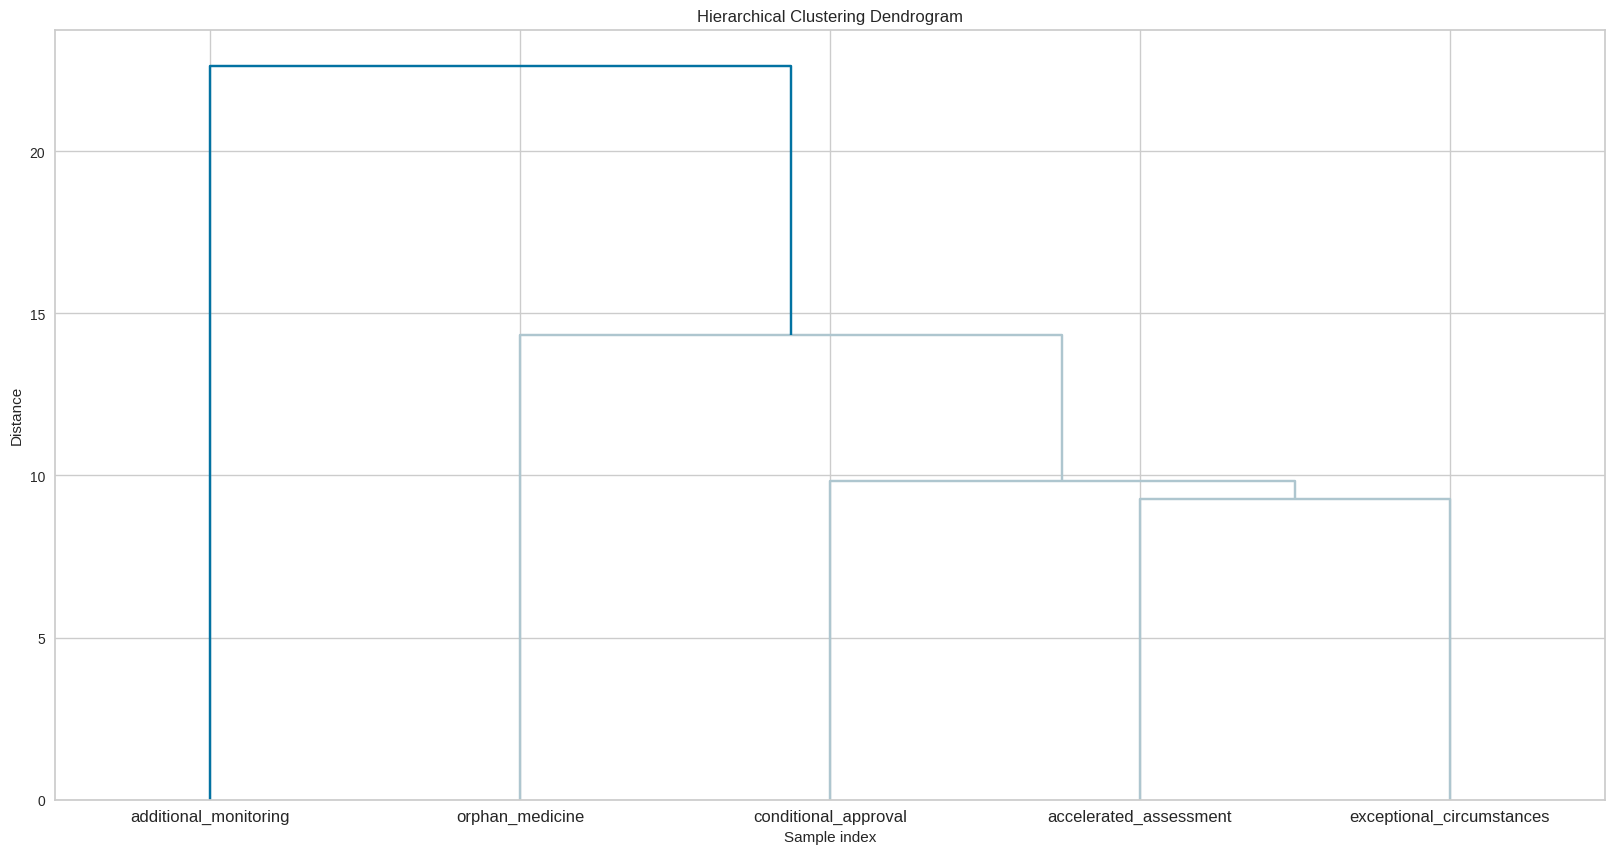

In [128]:
#Initial exploration using hierarchical clustering to check for natural aggregation in comparison with regulatory paths
from scipy.cluster.hierarchy import linkage, dendrogram
X = drugs_df[pathway_cols].astype(int)
Z = linkage(X.T, method="ward")
plt.figure(figsize=(20, 10))
dendrogram(Z, labels=pathway_cols)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()


We can see that accelerated assessment and exceptional circumstances are seen together most often. The dendogram clearly shows the co-occurence between the pathways.

#### **Exploring K-means Clustering**

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/pytho

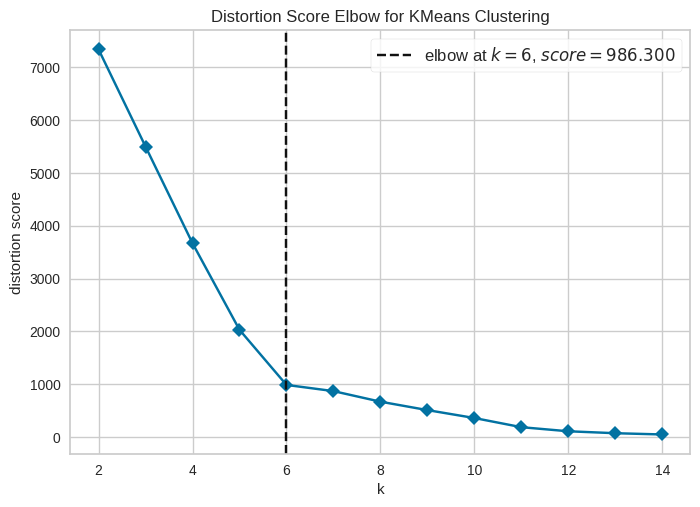

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [129]:
# Using the elbow method to determine the number of clusters
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.preprocessing import StandardScaler

kmeans = KMeans (n_clusters = 3, random_state=42)
drugs_df['cluster'] = kmeans.fit_predict(X)
sc = StandardScaler()
df_normalized = sc.fit_transform(X)
clustering = KMeans(random_state=42)
visualizer = KElbowVisualizer(
    clustering, k=(2, 15), metric='distortion', timings=False, random_state=42
)
visualizer.fit(df_normalized)      # Fit the data to the visualizer
visualizer.show()                  # Finalize and render the figure

In [130]:
cluster_summary = drugs_df.groupby('cluster')[pathway_cols].mean()
cluster_summary

,orphan_medicine,accelerated_assessment,conditional_approval,exceptional_circumstances,additional_monitoring
cluster,,,,,
0,0.000000,0.000000,0.002644,0.005948,0.000000
1,0.247368,0.007895,0.115789,0.089474,1.000000
2,0.715789,0.473684,0.000000,0.052632,0.073684


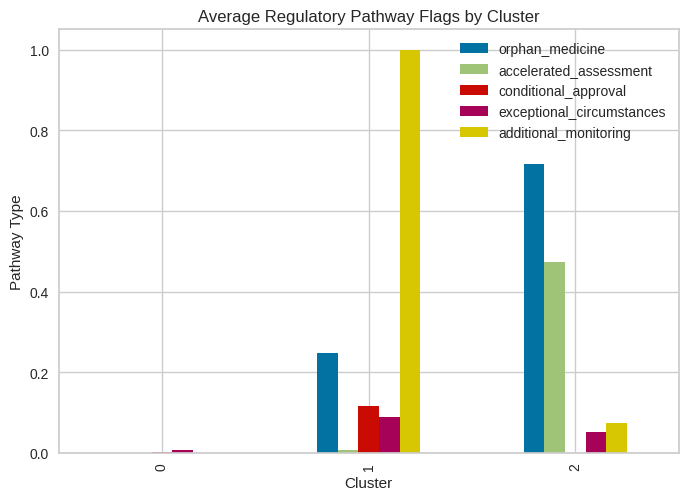

In [131]:
# Visualizing the clusters distribution among regulatory pathways
cluster_summary.plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Pathway Type')
plt.title('Average Regulatory Pathway Flags by Cluster')
plt.show()

We can see which clusters have higher averages together. In cluster 1 we see additional monitoring and orphan medicine with the most counts, but in cluster 2 orphan medicine and accelerated assessment have the highest averages.

‎

Now we want to confirm if this clusters are stable using the silhouette score, we expect to see some overlaping, since similar drugs could naturally group together regardless of their regulatory path(s).

/usr/local/lib/python3.12/dist-packages/yellowbrick/style/colors.py:104: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(colormap)


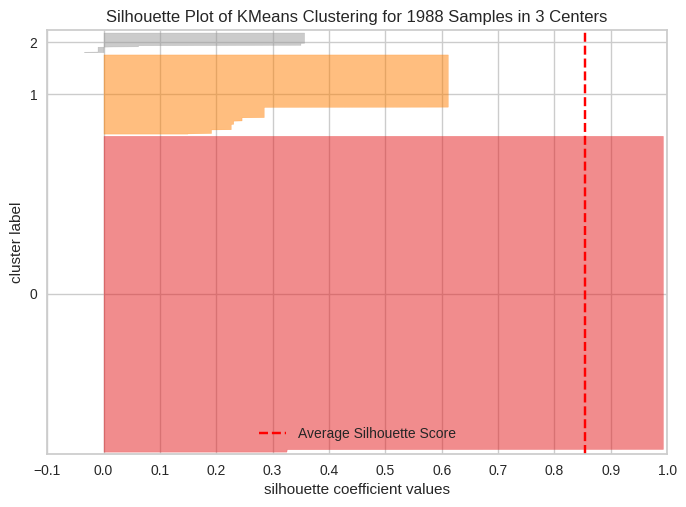

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1988 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [132]:
# Testing k=3
from yellowbrick.cluster import SilhouetteVisualizer
n_clusters_kmeans = 3
kmeans_model = KMeans(n_clusters_kmeans,random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)
visualizer.fit(X)
visualizer.show()

/usr/local/lib/python3.12/dist-packages/yellowbrick/style/colors.py:104: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(colormap)


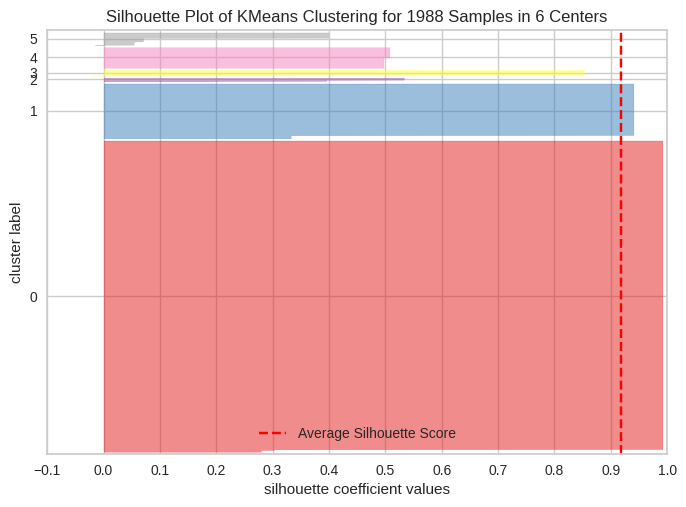

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1988 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [133]:
# Testing k=6
n_clusters_kmeans = 6
kmeans_model = KMeans(n_clusters_kmeans,random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)
visualizer.fit(X)
visualizer.show()

### **Question 2: Patterns in Approvals**
What patterns in regulatory characteristics and therapeutic areas agree with the observed increase in medicine authorizations between 2005 and 2010 and the subsequent decade?


In this second review the one of the lines of data interrogation is going to be explored into more detail. As a result of the initial EDA que following question: What patterns in regulatory characteristics and therapeutic areas agree with theo bserved increase in medicine authorizations between 2005 and 2010 and the subsequent decade?

Here is how my understanding of the problem evolved as I experimented with clustering:

#### **Exploring Hierarchical clustering**

After transforming the potentially relevant categorical variables into dummies, creating the regulatory complexity index and the most common therapeutical areas.

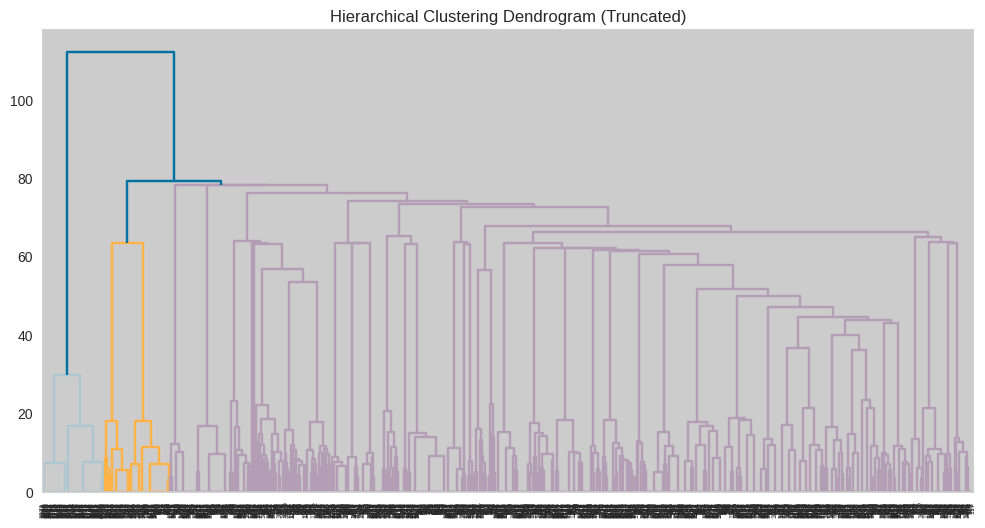

In [134]:
# Hierarchical clustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="level")
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.show()


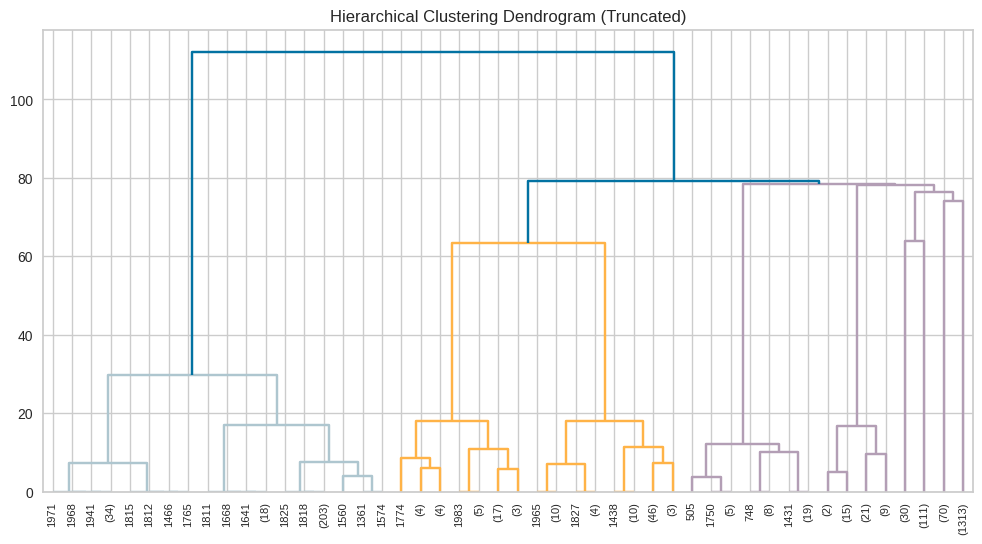

In [135]:
# Hierarchical clustering - Simplified version
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.show()


After reviewing the dendrogram showing the hierarchical clustering it looks like there is a natural aggreagation in 7 groups, considering that many high level merges occur between 70 and 80 in distance, which looks like good breaking point to contrast possible different enough groups. This grouping makes one of the clusters to have around 60\% of de data points, which seems very unbalanced.

Still, let's explore how does the clusters look like:

In [136]:
# From the dendogram a "natural" clustering seems to appear
n_clusters = 7
df['cluster_labels'] = fcluster(Z, n_clusters, criterion='maxclust').astype(str)
df.head()

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,pharm_group_list,pathway_profile,species_clean,missing_species_vet,species_list,species_count,multi_species_flag,missing_atc2,missing_pg,cluster_labels
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,[antineoplastic agents],orphan_medicine,human,0,[],0,0,0,0,7
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,"[other alimentary tract and metabolism products,]",none,human,0,[],0,0,0,0,7
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,<NA>,True,...,[],orphan_medicine+exceptional_circumstances+addi...,human,0,[],0,0,1,1,5
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,"[immune sera and immunoglobulins,]",additional_monitoring,human,0,[],0,0,0,0,7
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis, ...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,[immunosuppressants],none,human,0,[],0,0,0,0,7


In [137]:
df['cluster_labels'].value_counts()

,count
cluster_labels,
7,1313
1,270
5,141
2,111
6,70
4,47
3,36


In [138]:
# Creating a cross-tabulation of atc_level1 and cluster_labels
atc_cluster_crosstab = pd.crosstab( df['cluster_labels'],df['atc_level1'])
display(atc_cluster_crosstab)

atc_level1,A,B,C,D,G,H,J,L,M,N,P,Q,R,S,V
cluster_labels,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,1,0,267,0,0,0
2,111,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,36,0,0
4,0,0,47,0,0,0,0,0,0,0,0,0,0,0,0
5,17,9,4,0,0,2,17,59,5,6,2,8,1,3,3
6,0,0,0,0,0,0,0,0,0,70,0,0,0,0,0
7,73,126,44,18,59,38,236,404,49,110,0,3,32,31,69


The used clustering method is not necessarily reflecting the ATC classification system, this can be due to the features or method used to group the data, and only seems to capture (cluster) the typologies Q, A and R in a single aggregation.

In [139]:
# Generate a cross-tabulation of cluster_labels and regulatory_complexity_score
bool_cols=['conditional_approval','exceptional_circumstances','orphan_medicine','additional_monitoring']
df[bool_cols] = df[bool_cols].astype(int)
df["regulatory_complexity_score"] = (
    df["conditional_approval"]
    + df["exceptional_circumstances"]
    + df["accelerated_assessment"]
    + df["orphan_medicine"]
    + df["additional_monitoring"]
)
regulatory_complexity_crosstab = pd.crosstab(df['cluster_labels'], df['regulatory_complexity_score'])
display(regulatory_complexity_crosstab)

regulatory_complexity_score,0,1,2,3,4
cluster_labels,,,,,
1,270,0,0,0,0
2,101,10,0,0,0
3,26,10,0,0,0
4,46,1,0,0,0
5,18,33,39,50,1
6,68,2,0,0,0
7,971,282,57,3,0


The proposed complexity score also proven not to be the best way to differentiate between groups by using hierarchical clustering. Most of the drugs have a low regulatory complexity score, and those in a higher level doesn't seem to be similar enough to naturally group.

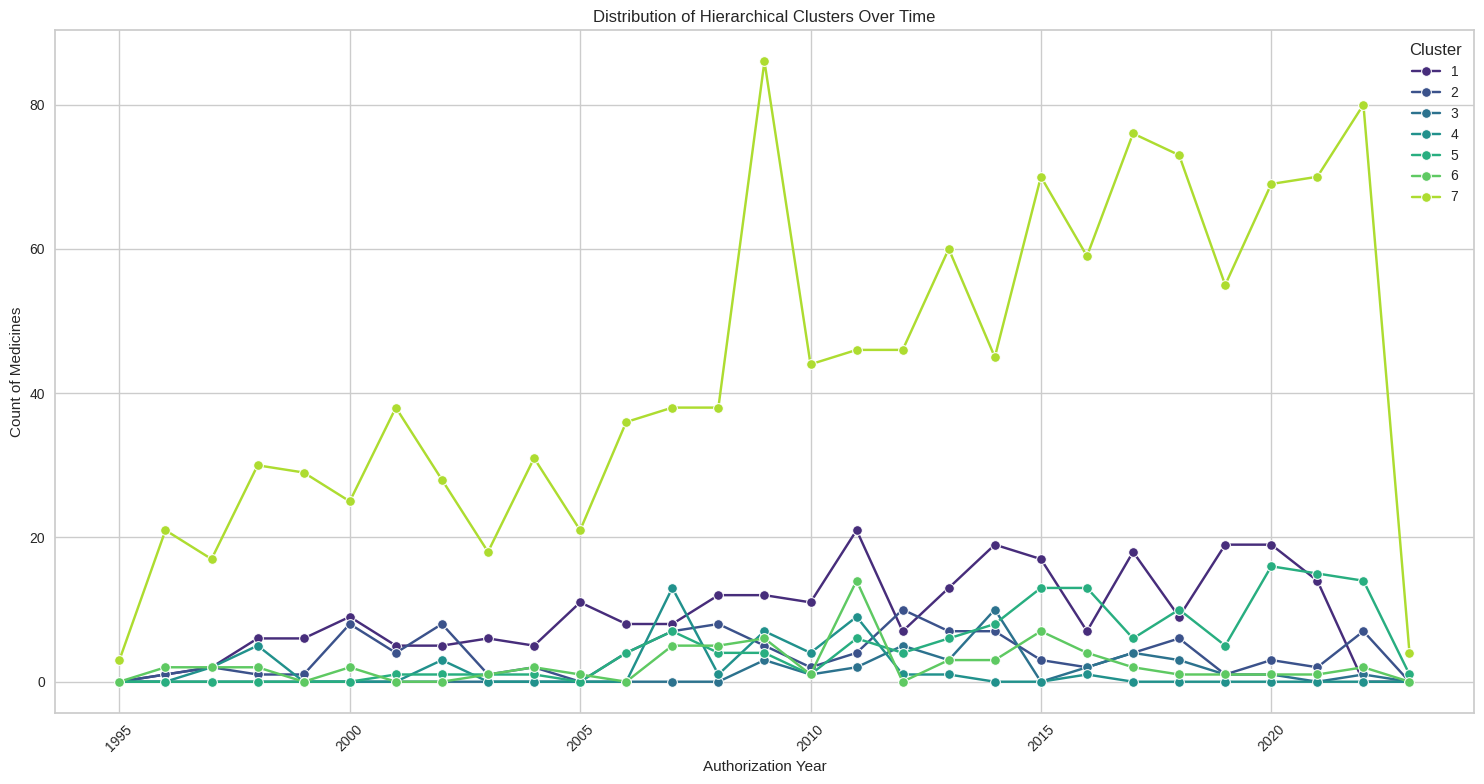

In [140]:
# Making a graph using the previous crosstab as base
import matplotlib.pyplot as plt
import seaborn as sns

df["auth_year"] = pd.to_datetime(
    df["marketing_authorisation_date"],
    errors="coerce"
).dt.year

# Prepare data from the crosstab for plotting
crosstab_df = pd.crosstab(df["cluster_labels"], df["auth_year"])
plot_data = crosstab_df.stack().reset_index(name='count')
plot_data.rename(columns={'level_0': 'cluster_labels'}, inplace=True)

plt.figure(figsize=(15, 8))
sns.lineplot(
    x='auth_year',
    y='count',
    hue='cluster_labels',
    data=plot_data,
    palette='viridis',
    marker='o' # Add markers for data points
)

plt.title('Distribution of Hierarchical Clusters Over Time')
plt.xlabel('Authorization Year')
plt.ylabel('Count of Medicines')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

#### **Exploring K-Means Clustering**

Starting by checking the silhouette score and elbow method to determine the possible best number of clusters (k).

In [141]:
# Reseting the clustering labels
df = df.drop('cluster_labels',axis=1)

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/pytho

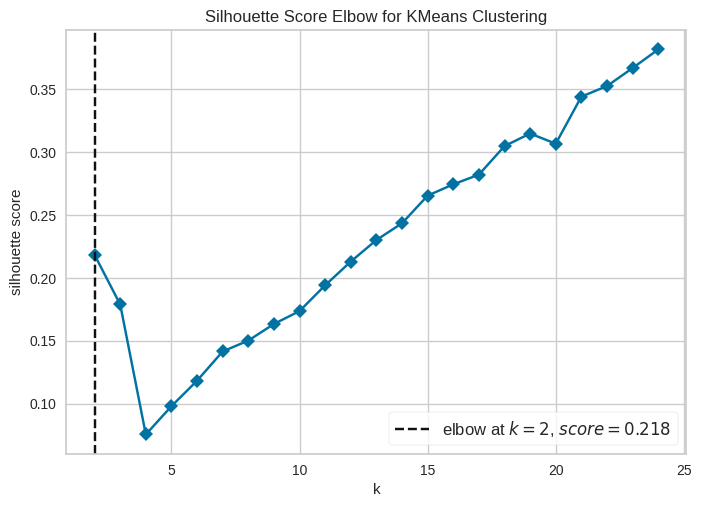

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [142]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

clustering = KMeans(random_state=42)
visualizer = KElbowVisualizer(
    clustering, k=(2, 25), metric='silhouette', timings=False, random_state=42
)

visualizer.fit(X_scaled)        # Fit the data to the visualizer
visualizer.show()               # Finalize and render the figure

/usr/local/lib/python3.12/dist-packages/yellowbrick/style/colors.py:104: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(colormap)


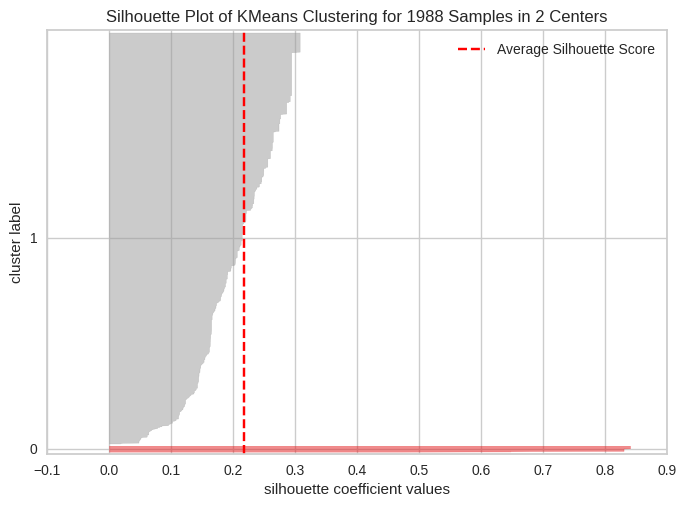

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1988 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [143]:
n_clusters_kmeans = 2

from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(n_clusters_kmeans, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_scaled)        # Fit the data to the visualizer
visualizer.show()               # Finalize and render the figure

/usr/local/lib/python3.12/dist-packages/yellowbrick/style/colors.py:104: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(colormap)


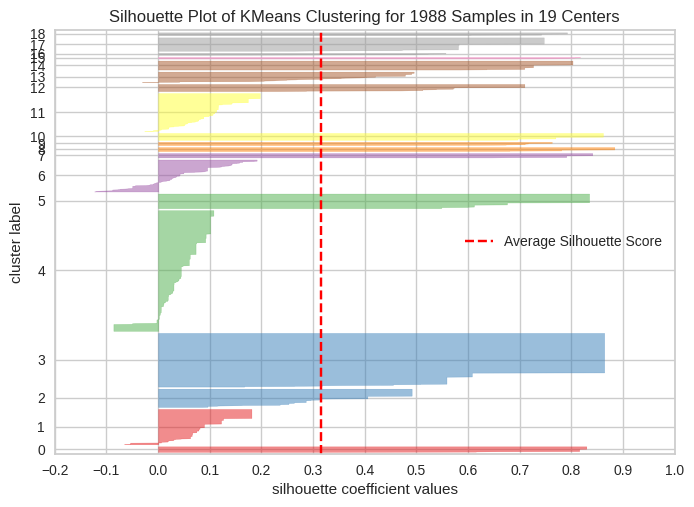

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1988 Samples in 19 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [144]:
n_clusters_kmeans = 19

from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(n_clusters_kmeans, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_scaled)        # Fit the data to the visualizer
visualizer.show()               # Finalize and render the figure

The silhouette score provides two possible number of clusters, by displaying 2 local maximumns, one at K=2 and one at K=19.

‎

From the silhouette plot its evident that increasing k provides more diverse clusters with low overlaping, while making a higher cut (k=2) don't provide enough differentiation between groups.

‎

To make a decision to choose a suitable K let's contrast this results with the elbow method.

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/pytho

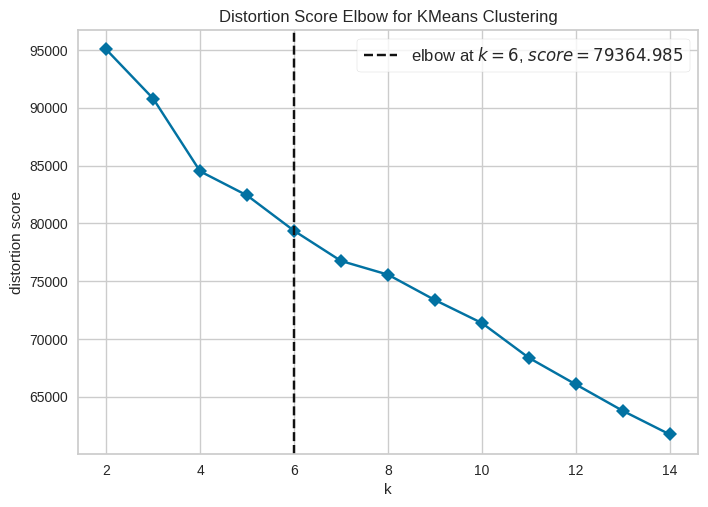

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [145]:
# Using the elbow method to determine the number of clusters
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

clustering = KMeans(random_state=42)
visualizer = KElbowVisualizer(
    clustering, k=(2, 15), metric='distortion', timings=False, random_state=42
)

visualizer.fit(X_scaled.values)      # Fit the data to the visualizer
visualizer.show()                    # Finalize and render the figure

The elbow method's function recommendation is K=6, but from the graph K=4 visually seems to be the true elbow. It would be consistent with the behavior observed in the silhouette plot. Let's explore K=4 and K=6.

##### **Trying K=4**

In [146]:
# Checking the clusters ditribution K=4
df["cluster_k4"] = KMeans(n_clusters=4, random_state=42, n_init=10)\
                    .fit_predict(X_scaled)
df['cluster_k4'].value_counts()

,count
cluster_k4,
1,1478
3,282
2,199
0,29


In [147]:
# Creating a cross-tabulation of atc_level1 and cluster_labels
atc_cluster_crosstab = pd.crosstab( df['cluster_k4'],df['atc_level1'])
display(atc_cluster_crosstab)

atc_level1,A,B,C,D,G,H,J,L,M,N,P,Q,R,S,V
cluster_k4,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,29,0,0,0,0,0
1,171,120,89,16,59,33,235,384,47,142,1,0,67,29,68
2,30,15,6,2,0,7,18,79,7,15,1,0,2,5,4
3,0,0,0,0,0,0,0,0,0,1,0,278,0,0,0


In [148]:
# Generate a cross-tabulation of cluster_labels and regulatory_complexity_score
bool_cols=['conditional_approval','exceptional_circumstances','orphan_medicine','additional_monitoring']
df[bool_cols] = df[bool_cols].astype(int)
df["regulatory_complexity_score"] = (
    df["conditional_approval"]
    + df["exceptional_circumstances"]
    + df["accelerated_assessment"]
    + df["orphan_medicine"]
    + df["additional_monitoring"]
)
regulatory_complexity_crosstab = pd.crosstab(df['cluster_k4'], df['regulatory_complexity_score'])
display(regulatory_complexity_crosstab)

regulatory_complexity_score,0,1,2,3,4
cluster_k4,,,,,
0,28,1,0,0,0
1,1198,280,0,0,0
2,0,52,93,53,1
3,274,5,3,0,0


In [149]:
# Checking persistence over time

df["auth_year"] = pd.to_datetime(
    df["marketing_authorisation_date"],
    errors="coerce"
).dt.year

pd.crosstab(df["cluster_k4"], df["auth_year"])

auth_year,1995.0,1996.0,1997.0,1998.0,1999.0,2000.0,2001.0,2002.0,2003.0,2004.0,...,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0
cluster_k4,,,,,,,,,,,,,,,,,,,,,
0,0,2,0,0,0,1,0,0,0,1,...,2,4,0,1,1,0,1,0,1,0
1,3,22,23,38,30,34,43,40,21,35,...,61,76,67,78,71,52,66,66,75,4
2,0,0,0,0,0,0,0,0,0,0,...,10,13,14,13,21,11,23,22,28,1
3,0,1,2,6,6,9,5,5,6,5,...,19,17,7,18,9,19,19,14,0,0


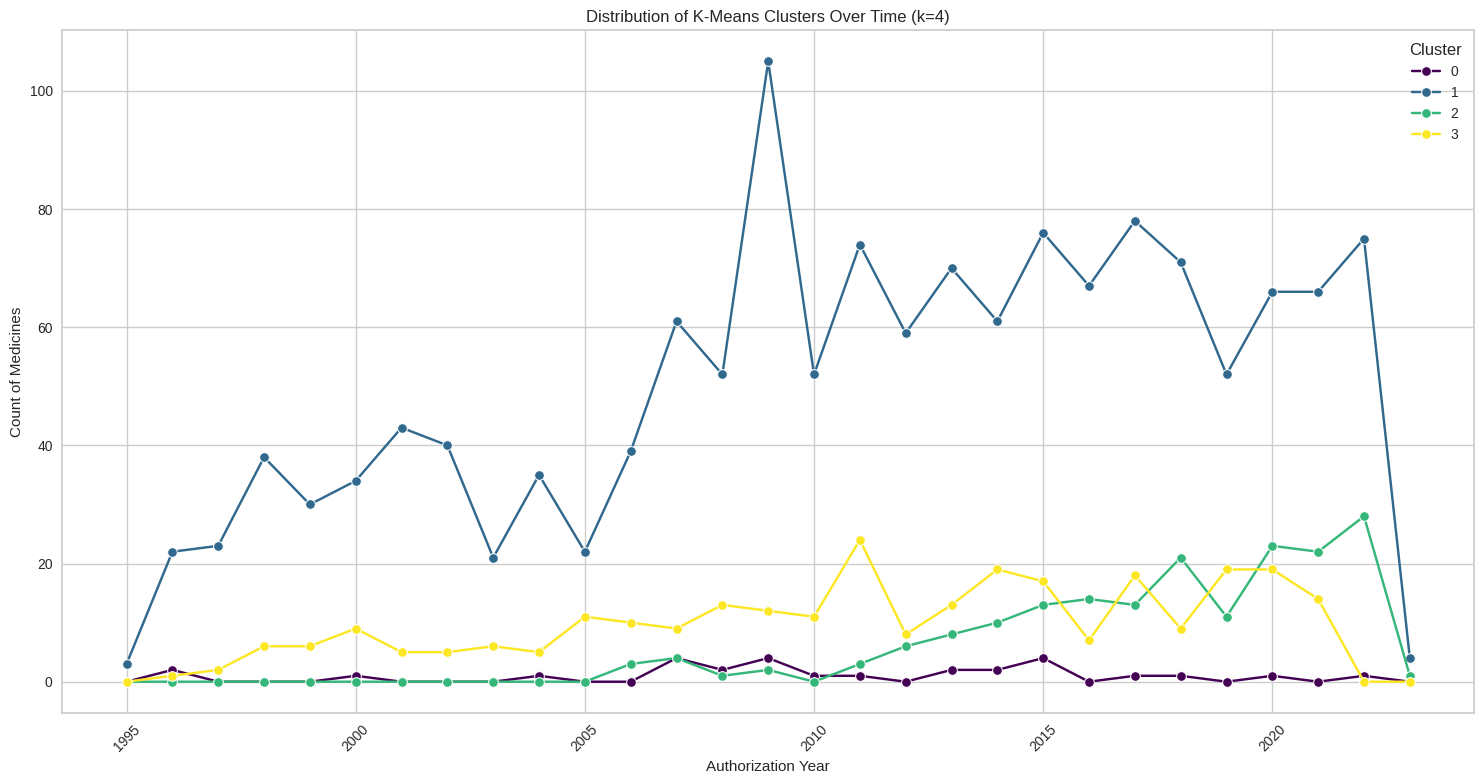

In [150]:
# Making a graph using the previous crosstab as base
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data from the crosstab for plotting
crosstab_df = pd.crosstab(df["cluster_k4"], df["auth_year"])
plot_data = crosstab_df.stack().reset_index(name='count')
plot_data.rename(columns={'level_0': 'cluster_k4'}, inplace=True)

plt.figure(figsize=(15, 8))
sns.lineplot(
    x='auth_year',
    y='count',
    hue='cluster_k4',
    data=plot_data,
    palette='viridis',
    marker='o' # Add markers for data points
)

plt.title('Distribution of K-Means Clusters Over Time (k=4)')
plt.xlabel('Authorization Year')
plt.ylabel('Count of Medicines')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

##### **Trying K=6**

In [151]:
# Checking the clusters ditribution K=6
df["cluster_k6"] = KMeans(n_clusters=6, random_state=42, n_init=10)\
                    .fit_predict(X_scaled)
df['cluster_k6'].value_counts()

,count
cluster_k6,
4,1405
0,282
1,155
5,76
2,47
3,23


In [152]:
# Creating a cross-tabulation of atc_level1 and cluster_labels
atc_cluster_crosstab = pd.crosstab( df['cluster_k6'],df['atc_level1'])
display(atc_cluster_crosstab)

atc_level1,A,B,C,D,G,H,J,L,M,N,P,Q,R,S,V
cluster_k6,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,1,0,278,0,0,0
1,24,12,4,1,0,5,18,58,6,12,1,0,2,3,2
2,0,0,47,0,0,0,0,0,0,0,0,0,0,0,0
3,0,23,0,0,0,0,0,0,0,0,0,0,0,0,0
4,101,100,44,17,59,35,235,405,48,174,1,0,67,31,70
5,76,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [153]:
# Generate a cross-tabulation of cluster_labels and regulatory_complexity_score
bool_cols=['conditional_approval','exceptional_circumstances','orphan_medicine','additional_monitoring']
df[bool_cols] = df[bool_cols].astype(int)
df["regulatory_complexity_score"] = (
    df["conditional_approval"]
    + df["exceptional_circumstances"]
    + df["accelerated_assessment"]
    + df["orphan_medicine"]
    + df["additional_monitoring"]
)
regulatory_complexity_crosstab = pd.crosstab(df['cluster_k6'], df['regulatory_complexity_score'])
display(regulatory_complexity_crosstab)

regulatory_complexity_score,0,1,2,3,4
cluster_k6,,,,,
0,274,5,3,0,0
1,0,8,93,53,1
2,46,1,0,0,0
3,23,0,0,0,0
4,1084,321,0,0,0
5,73,3,0,0,0


In [154]:
# Checking persistence over time
df["auth_year"] = pd.to_datetime(
    df["marketing_authorisation_date"],
    errors="coerce"
).dt.year
pd.crosstab(df["cluster_k6"], df["auth_year"])

auth_year,1995.0,1996.0,1997.0,1998.0,1999.0,2000.0,2001.0,2002.0,2003.0,2004.0,...,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0
cluster_k6,,,,,,,,,,,,,,,,,,,,,
0,0,1,2,6,6,9,5,5,6,5,...,19,17,7,18,9,19,19,14,0,0
1,0,0,0,0,0,0,0,0,0,0,...,8,10,10,7,17,9,21,21,26,1
2,0,0,2,5,0,0,0,3,0,0,...,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3,24,21,32,30,30,40,37,20,36,...,59,80,68,84,73,53,68,66,73,4
5,0,0,0,1,0,5,3,0,1,0,...,6,3,2,1,3,1,1,1,5,0


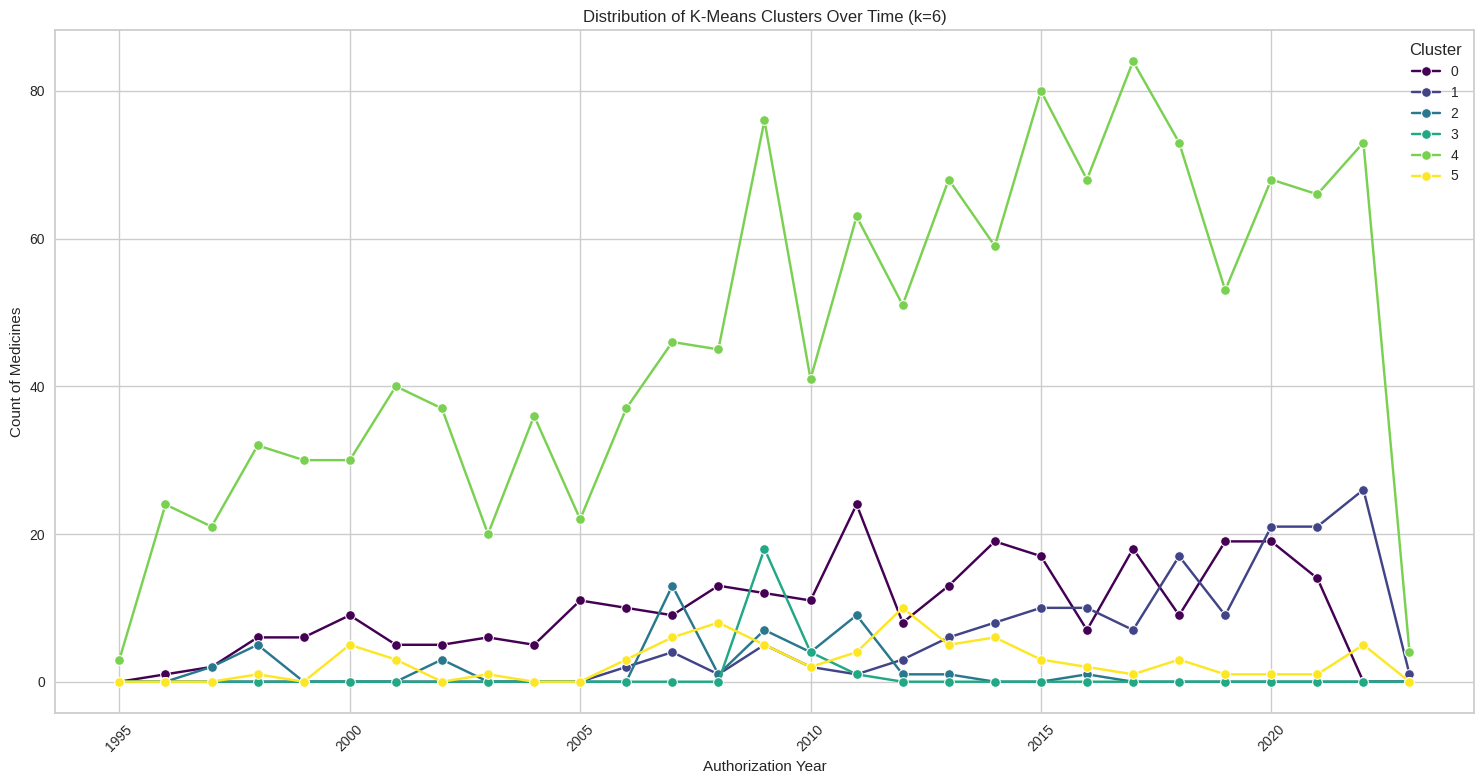

In [155]:
# Making a graph using the previous crosstab as base
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data from the crosstab for plotting
crosstab_df = pd.crosstab(df["cluster_k6"], df["auth_year"])
plot_data = crosstab_df.stack().reset_index(name='count')
plot_data.rename(columns={'level_0': 'cluster_k6'}, inplace=True)

plt.figure(figsize=(15, 8))
sns.lineplot(
    x='auth_year',
    y='count',
    hue='cluster_k6',
    data=plot_data,
    palette='viridis',
    marker='o' # Add markers for data points
)

plt.title('Distribution of K-Means Clusters Over Time (k=6)')
plt.xlabel('Authorization Year')
plt.ylabel('Count of Medicines')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

### **Question 3: Patterns in Rejections**

Which medicines are more likely to be refused to get authorization into the market? What features may influence this decision?

‎

To start we decided to visualiza the behaviour of rejected medicines over time, also those which got approved afterwards and the count per company to preliminarly identify some correlations and patterns.

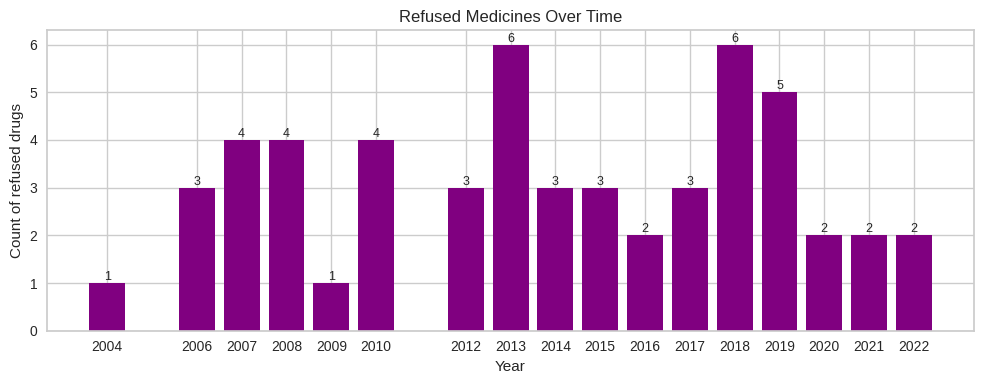

In [156]:
# Graph showing count of refused medicines over time
refused_df = drugs_df[drugs_df["authorisation_status"]=="refused"].copy() # Authorisation = refused
refused_df["refused_year"] = refused_df["date_of_refusal_of_marketing_authorisation"].dt.year
refused_count = refused_df["refused_year"].value_counts().sort_index()
plt.figure(figsize=(10,4))
bars = plt.bar(refused_count.index.astype(int), refused_count.values, color='purple')
# Adding data labels
for bar in bars:
  height = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=9
  )
plt.title("Refused Medicines Over Time")
plt.xlabel("Year")
plt.ylabel("Count of refused drugs")
plt.xticks(refused_count.index.astype(int))
plt.tight_layout()

plt.show()

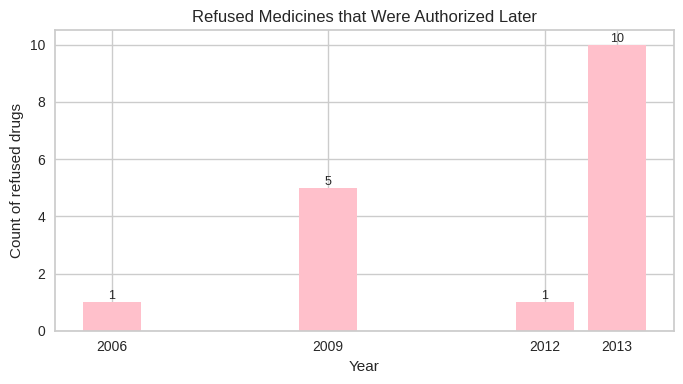

In [157]:
# Graph showing count of refused medicines that got approved later
refused_df2 = drugs_df[
    drugs_df["date_of_refusal_of_marketing_authorisation"].notna()&
    (drugs_df["authorisation_status"].str.lower()=="authorised")
].copy()
refused_df2["refused_year"] = refused_df2["date_of_refusal_of_marketing_authorisation"].dt.year
refused_count = refused_df2["refused_year"].value_counts().sort_index()
plt.figure(figsize=(7,4))
bars = plt.bar(refused_count.index.astype(int), refused_count.values, color='pink')

# Adding data labels
for bar in bars:
  height = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=9
  )
plt.title("Refused Medicines that Were Authorized Later")
plt.xlabel("Year")
plt.ylabel("Count of refused drugs")
plt.xticks(refused_count.index.astype(int))
plt.tight_layout()

plt.show()

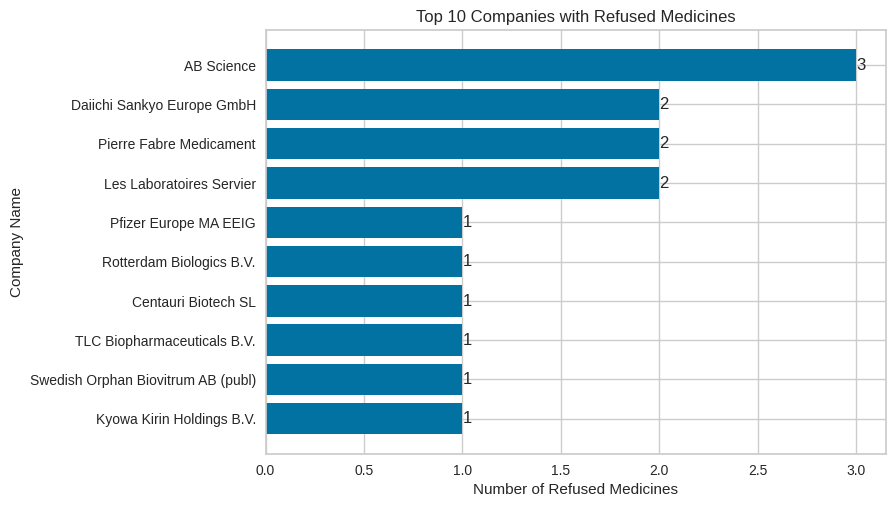

In [158]:
# Graph of company name with drugs refusal
# Filter refused medicines
refused_df = drugs_df[drugs_df['authorisation_status'].astype(str).str.strip().str.lower().eq("refused")].copy()
# Count refused medicines by company (top 10)
company_refused_count = (refused_df['marketing_authorisation_holder_company_name'].value_counts().head(10))
# Plot horizontal bar chart
plt.figure()
plt.barh(company_refused_count.index, company_refused_count.values)
plt.xlabel("Number of Refused Medicines")
plt.ylabel("Company Name")
plt.title("Top 10 Companies with Refused Medicines")
# Add data labels
for index, value in enumerate(company_refused_count.values):
    plt.text(value, index, str(int(value)), va='center')
# Show highest count at the top
plt.gca().invert_yaxis()
plt.show()

#### **Exploring Assosiation Rules Mining**
Result below shows, although still weak, orphan_medicine and additional_monitoring have the strongest association among other booleans. This means that being an orphan medicine or under additional monitoring slightly changes the likelyhood of authorization status. Note that it is directionally interesting but not predictive.

In [159]:
# Discover co-occurance pattern between regulatory pathways and medicine refusal
# setup association rules mining
boolean_cols = ["patient_safety", "additional_monitoring", "generic", "biosimilar", "conditional_approval", "exceptional_circumstances", "accelerated_assessment", "orphan_medicine"]
# Create a filterd dataframe including boolean features and authorisation_status
df_arm = drugs_df[boolean_cols+["authorisation_status"]].copy()
# Create boolean indicator for authorisation_status
df_arm["refused"] = (df_arm["authorisation_status"].astype(str).str.lower().str.contains("refus"))
# Convert each medicine into a transaction like basket of items in class
txn = []
for _, row in df_arm.iterrows():
  items=[]
  for col in boolean_cols:
    if row[col] is True:
      items.append(col)
  if row["refused"]:
    items.append("REFUSED")
  txn.append(items)

# Use one-hot encode to each transaction
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_array = te.fit(txn).transform(txn)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)
# Find frequent itemsets
from mlxtend.frequent_patterns import apriori
frequent_itemsets = apriori(df_encoded, min_support=0.0001, use_colnames=True)
# Create rules on the itemsets
from mlxtend.frequent_patterns import association_rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.002)
# filter to include only rules with refusal in outcome
refusal_rules = rules[rules["consequents"].apply(lambda x: "REFUSED" in x)].sort_values(by="lift", ascending=False)
refusal_rules[["antecedents","consequents","support","confidence","lift"]]

,antecedents,consequents,support,confidence,lift
40,(orphan_medicine),"(REFUSED, additional_monitoring)",0.000503,0.006173,12.271605
7,(orphan_medicine),(REFUSED),0.007545,0.092593,3.229370
3,(biosimilar),(REFUSED),0.001006,0.021739,0.758200
38,"(orphan_medicine, additional_monitoring)",(REFUSED),0.000503,0.009901,0.345319
41,(additional_monitoring),"(REFUSED, orphan_medicine)",0.000503,0.002584,0.342463
5,(generic),(REFUSED),0.000503,0.003175,0.110721
1,(additional_monitoring),(REFUSED),0.000503,0.002584,0.090122


#### **Exploring Hierarchical clustering**
Created to visualize the natural groupings of the medicines/observations which guides cluster selection

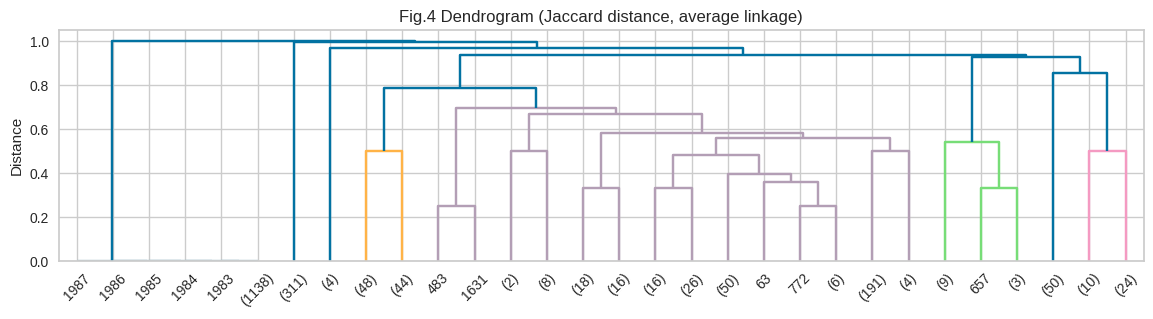

In [160]:
# import needed libraries
from scipy.spatial.distance import pdist, squareform

# encode booleans from True/False to 1/0
X = drugs_df[boolean_cols].astype(int).copy()

# compute distance with pdist() and condensed distance vector
distance = pdist(X, metric="jaccard")

# hierarchical clustering on distances
Z = linkage(distance, method="average")

# Plot
plt.figure(figsize=(14,3))
dendrogram(Z,
           truncate_mode="lastp", # show only the last p merged clusters to avoid error RecursionError: maximum recursion depth exceeded
           p=30,
           show_leaf_counts=True,
           no_labels=False)
plt.title("Fig.4 Dendrogram (Jaccard distance, average linkage)")
plt.ylabel("Distance")
plt.show()

**Creating Cluster Label**

After analyzing the dendrogram, n_clusters = 3 is chosen to create cluster label column. n_cluster = 4 was tried but eventually got abandoned as the total count in cluster 4 is far too small compared to the rest of the clusters, signaling 3 is the best number of clusters.



In [161]:
n_clusters = 3
drugs_df["cluster_labels"] = fcluster(Z, n_clusters, criterion="maxclust").astype(str)
# Look at count of medicines in each cluster
drugs_df["cluster_labels"].value_counts()

,count
cluster_labels,
1,1143
3,534
2,311


**Refusal Rate in Each Cluster**

Refusal rates differ substantially across clusters. Generic medicines shows a near-zero refusal rate, while both standard medicines and those subject to complex regulatory pathways show higher refusal rates. This suggests that regulatory complexity is associated with elevated uncertainty in authorization outcomes.

In [162]:
# Create refusal flag
drugs_df["is_refused"] = (
    drugs_df["authorisation_status"]
    .astype(str)
    .str.lower()
    .str.contains("refus")
)

# Calculate refusal rate for cluster
cluster_refusal = (
    drugs_df
    .groupby("cluster_labels")
    .agg(
        total_medicines=("cluster_labels", "size"),
        refused_medicines=("is_refused", "sum"),
        refusal_rate=("is_refused", "mean")
    )
    .reset_index()
)
cluster_refusal

,cluster_labels,total_medicines,refused_medicines,refusal_rate
0,1,1143,39,0.034121
1,2,311,1,0.003215
2,3,534,17,0.031835


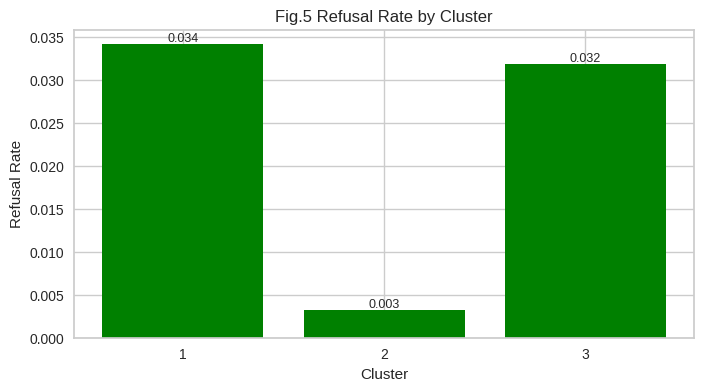

In [163]:
# Visualizing refusal rate in each cluster
plt.figure(figsize=(8,4))
bars = plt.bar(
    cluster_refusal.index + 1,
    cluster_refusal["refusal_rate"],
    color = "Green"
)

plt.xticks((cluster_refusal.index+1).astype(int))

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.3f}', # Format to 3 decimal places
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xlabel("Cluster")
plt.ylabel("Refusal Rate")
plt.title("Fig.5 Refusal Rate by Cluster")
plt.show()

#### **Exploring K-means**
Perform k-means clustering on `therapeutic_area` to find pattern in drugs refusal based on keywords in each clustering.

In [164]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Keep rows with therapeutic text
drugs_df_clean = drugs_df.dropna(subset=["therapeutic_area"]).copy()

# Identify refused drugs
drugs_df_clean["is_refused"] = drugs_df_clean["authorisation_status"].str.lower().str.contains("refus")

refused_df = drugs_df_clean[drugs_df_clean["is_refused"]].copy()
# Convert text in therapeutic_area into a numeric matrix to analyze patterns
vectorizer = TfidfVectorizer(stop_words="english",ngram_range=(1, 2),min_df=2,max_df=0.9)
X_refused = vectorizer.fit_transform(refused_df["therapeutic_area"])
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
refused_df["cluster"] = kmeans.fit_predict(X_refused)

# list items in each cluster
terms = np.array(vectorizer.get_feature_names_out())

for c in range(k):
    top_idx = kmeans.cluster_centers_[c].argsort()[-10:][::-1]
    print(f"\nCluster {c+1} – top therapeutic terms:")
    print(", ".join(terms[top_idx]))


Cluster 1 – top therapeutic terms:
neoplasms, breast, breast neoplasms, sclerosis, syndrome, tissue, myeloid acute, myeloid, major, lymphoma non

Cluster 2 – top therapeutic terms:
disease, tissue, sclerosis, non hodgkin, non, syndrome, myeloid acute, myeloid, major, lymphoma non

Cluster 3 – top therapeutic terms:
diseases, cell, fibromyalgia, disorders, syndrome, sclerosis, disease, tissue, lymphoma, non


In [165]:
# Apply the same vectorizer + model to all drugs
X_all = vectorizer.transform(drugs_df_clean["therapeutic_area"])
drugs_df_clean["cluster"] = kmeans.predict(X_all) +1

cluster_refusal = (
    drugs_df_clean.groupby("cluster")
    .agg(
        total_medicines=("authorisation_status", "size"),
        refused_medicines=("is_refused", "sum"),
        refusal_rate=("is_refused", "mean")
    )
    .reset_index()
    .sort_values("cluster", ascending=True)
)

cluster_refusal

,cluster,total_medicines,refused_medicines,refusal_rate
0,1,127,5,0.03937
1,2,106,2,0.018868
2,3,1470,46,0.031293


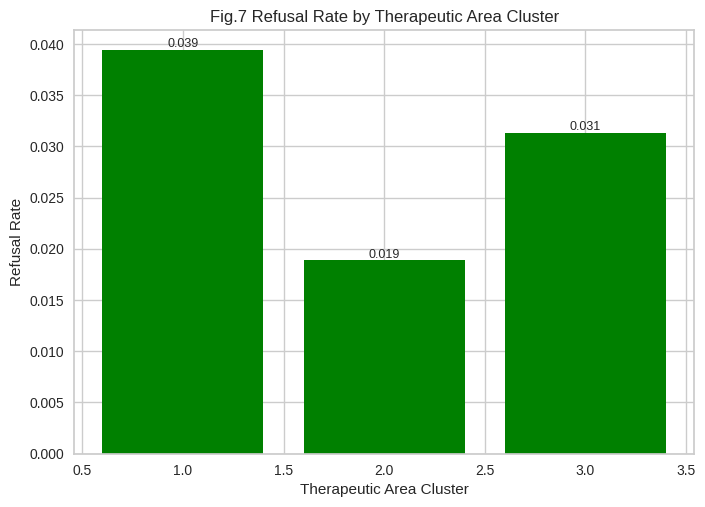

In [166]:
# Refusal rate by each cluster
plt.figure()
bars = plt.bar(cluster_refusal["cluster"], cluster_refusal["refusal_rate"], color='green')

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.3f}', # Format to 3 decimal places
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xlabel("Therapeutic Area Cluster")
plt.ylabel("Refusal Rate")
plt.title("Fig.7 Refusal Rate by Therapeutic Area Cluster")
plt.show()

### **Question 4: Veterinary Medicaments**
How do special approvals differ between human and veterinary medicines? Within veterinary medicines, which species segments have unique combinations of regulatory flags?

#### **Contrasting Veterinary and Humans Drugs**

In [167]:
# Number of drugs per regulatory path - veterinary drugs
vet = drugs_df[drugs_df["category_clean"] == "veterinary"].copy()
vet_flag_summary = pd.DataFrame({
    "vet_true_count": vet[pathway_cols].sum().astype(int),
    "vet_true_rate_%": (vet[pathway_cols].mean() * 100).round(2)
}).sort_values("vet_true_count", ascending=False)
vet_flag_summary

,vet_true_count,vet_true_rate_%
accelerated_assessment,8,2.84
exceptional_circumstances,3,1.06
orphan_medicine,0,0.00
conditional_approval,0,0.00
additional_monitoring,0,0.00


In [168]:
# Veterinary drugs with multiple flags
print(f'The number of veterinary observations is: {len(vet)}\n')

any_special_vet = (vet["special_pathway_count"] > 0).sum()
total_vet = len(vet)

print(f"Vet with any special flag: {any_special_vet}/{total_vet} ({any_special_vet/total_vet:.2%})")

drugs_df["special_pathway_label"] = pd.cut(
    drugs_df["special_pathway_count"],
    bins=[-1, 0, 1, 2, 5],
    labels=["none", "one_flag", "two_flags", "3+_flags"]
)

vet["special_pathway_label"] = drugs_df.loc[vet.index, "special_pathway_label"]
vet["special_pathway_label"].value_counts()

The number of veterinary observations is: 282

Vet with any special flag: 8/282 (2.84%)


,count
special_pathway_label,
none,274
one_flag,5
two_flags,3
3+_flags,0


The number of data points for veterinary drugs is much lower thatn for humans. An in detail revision is needed to check the consistency of regulatory flags distribution for humans as well.

In [169]:
# counts and rates by category
by_cat_counts = drugs_df.groupby("category_clean")[pathway_cols].sum().astype(int)
by_cat_rates = (drugs_df.groupby("category_clean")[pathway_cols].mean() * 100).round(2)
summary = (pd.concat([by_cat_counts.add_suffix("_true_count"),by_cat_rates.add_suffix("_true_rate_%")],axis=1))

# reshape into a flag-by-flag table for human vs vet
rows = []
for f in pathway_cols:
    h_true = summary.loc["human", f"{f}_true_count"]
    v_true = summary.loc["veterinary", f"{f}_true_count"]
    h_rate = summary.loc["human", f"{f}_true_rate_%"]
    v_rate = summary.loc["veterinary", f"{f}_true_rate_%"]
    rows.append({
        "flag": f,
        "human_true": int(h_true),
        "human_rate_%": float(h_rate),
        "vet_true": int(v_true),
        "vet_rate_%": float(v_rate),
        "rate_diff_pp": float(h_rate - v_rate)   # percentage points
    })

flag_prevalence = pd.DataFrame(rows).sort_values("rate_diff_pp", ascending=False)
flag_prevalence

,flag,human_true,human_rate_%,vet_true,vet_rate_%,rate_diff_pp
4,additional_monitoring,387,22.68,0,0.00,22.68
0,orphan_medicine,162,9.50,0,0.00,9.50
2,conditional_approval,48,2.81,0,0.00,2.81
3,exceptional_circumstances,45,2.64,3,1.06,1.58
1,accelerated_assessment,40,2.34,8,2.84,-0.50


A subsequent statistical analysis was made, using Chi-Squared test of independence of the observed frequencies in the contingency table, as well as a Fisher's exact test (more suitable for small samples), to account for the different rates between human and veterinary drugs.

In [170]:
from scipy.stats import chi2_contingency, fisher_exact
# Chi Square
def make_2x2(flag):
    obs = np.array([
        [
            int(((drugs_df["category_clean"]=="human") & (drugs_df[flag]==True)).sum()),
            int(((drugs_df["category_clean"]=="human") & (drugs_df[flag]==False)).sum())
        ],
        [
            int(((drugs_df["category_clean"]=="veterinary") & (drugs_df[flag]==True)).sum()),
            int(((drugs_df["category_clean"]=="veterinary") & (drugs_df[flag]==False)).sum())
        ]
    ])
    return obs
checks = []
for f in pathway_cols:
    obs = make_2x2(f)
    chi2, p, dof, exp = chi2_contingency(obs, correction=False)
    checks.append({
        "flag": f,
        "observed": obs.tolist(),
        "expected": np.round(exp, 2).tolist(),
        "min_expected": float(exp.min()),
        "n_expected_lt_5": int((exp < 5).sum()),
        "vet_true": int(obs[1,0])
    })
assumption_df = pd.DataFrame(checks).sort_values("min_expected")

# Fisher
results = []
for f in pathway_cols:
    obs = make_2x2(f)

    # Fisher (two-sided)
    OR, p_fisher = fisher_exact(obs, alternative="two-sided")

    # Chi-square (uncorrected + Yates corrected)
    chi2, p_chi, dof, exp = chi2_contingency(obs, correction=False)
    chi2_y, p_chi_y, dof_y, exp_y = chi2_contingency(obs, correction=True)

    results.append({
        "flag": f,
        "observed_table": obs.tolist(),
        "min_expected": float(exp.min()),
        "fisher_p": p_fisher,
        "chi_p": p_chi,
        "chi_p_yates": p_chi_y, # Yates correction is a math filter to make Chi test more conservative when small numbers
        "fisher_OR": OR
    })

test_results = pd.DataFrame(results).sort_values("fisher_p")
test_results


,flag,observed_table,min_expected,fisher_p,chi_p,chi_p_yates,fisher_OR
4,additional_monitoring,"[[387, 1319], [0, 282]]",54.896378,2.705223e-29,4.986219e-19,1.033777e-18,inf
0,orphan_medicine,"[[162, 1544], [0, 282]]",22.979879,1.055087e-11,6.684168e-08,1.277966e-07,inf
2,conditional_approval,"[[48, 1658], [0, 282]]",6.808853,1.134761e-03,4.352283e-03,8.240825e-03,inf
3,exceptional_circumstances,"[[45, 1661], [3, 279]]",6.808853,1.411080e-01,1.106937e-01,1.658412e-01,2.519567
1,accelerated_assessment,"[[40, 1666], [8, 274]]",6.808853,6.737490e-01,6.178977e-01,7.722443e-01,0.822329


There is a clear, systematic difference between human and veterinary medicines. Three labels, additional monitoring, orphan medicine, and conditional approval, appear frequently in human drugs but not at all in veterinary ones, indicating an intentional regulatory gap rather than chance.

By contrast, exceptional circumstances and accelerated assessment show no meaningful difference between the two groups.

These five flags alone are not useful for grouping veterinary medicines due to limited variation. To move forward, we should either (1) analyze the few positive cases in detail or (2) incorporate additional regulatory labels to better capture how veterinary drugs are approved.

#### **Veterinary Specific Features Analysis**

In [171]:
# Start from boolean_cols plus status flags
base_binary = boolean_cols + ["is_authorised", "is_withdrawn", "is_refused"]

# Keep only features that are not constant in veterinary (0 < mean < 1)
binary_means = vet[base_binary].mean()
binary_keep = binary_means[(binary_means > 0) & (binary_means < 1)].index.tolist()
binary_means.reset_index().rename({'index':'Feature',0:'mean'},axis=1).sort_values(by='mean')

,Feature,mean
0,patient_safety,0.000000
1,additional_monitoring,0.000000
3,biosimilar,0.000000
4,conditional_approval,0.000000
7,orphan_medicine,0.000000
5,exceptional_circumstances,0.010638
10,is_refused,0.014184
6,accelerated_assessment,0.028369
2,generic,0.088652
9,is_withdrawn,0.163121


Because this binary space is still small, the next step is to expand feature representation using structured categorical and list-text fields (ATC and pharmacotherapeutic group), while keeping species out of the feature set to avoid leakage.

A further exploration of the therapeutical areas that concer veterinary drugs should be done to account for their influence in pattern determination.

In [172]:
# Veterinary only feature matrix
needed = binary_keep + ["pharm_group_list", "atc_level1", "atc_level2"]

from sklearn.preprocessing import MultiLabelBinarizer

# Frequency of each pharm group label within vet - to keep
pg_counts = pd.Series([i for sub in vet["pharm_group_list"] for i in sub]).value_counts()
print(pg_counts.head(15))

min_count = 5
keep_pg = set(pg_counts[pg_counts >= min_count].index)
print("Labels kept (>= min_count):", len(keep_pg))

pg_filtered = vet["pharm_group_list"].apply(lambda lst: [x for x in lst if x in keep_pg])

mlb = MultiLabelBinarizer()
pg_X = pd.DataFrame(
    mlb.fit_transform(pg_filtered),
    columns=[f"pg__{c}" for c in mlb.classes_],
    index=vet.index
)

immunologicals                                                 23
antibacterials for systemic use                                13
immunologicals for suidae                                      11
immunologicals for felidae,                                     9
immunologicals for aves                                         9
oxicams                                                         8
anti-inflammatory and anti-rheumatic products, non-steroids     6
ectoparasiticides for topical use, incl. insecticides           6
antiparasitic products, insecticides and repellents             5
immunologicals for bovidae                                      4
immunologicals for equidae                                      4
musculo-skeletal system                                         4
inactivated viral vaccines                                      3
corticosteroids, dermatological preparations                    3
immunologicals for canidae                                      3
Name: coun

To reduce noise and capture meaningful patterns, we encoded pharmacotherapeutic groups using multi-hot binary features. Because medicines can belong to multiple categories, we converted them into nine binary variables and applied a frequency threshold (min_count = 5). This removes rare labels and retains common categories (e.g., immunologicals), giving the clustering model consistent, informative features.

#### **ATC Labels Analysis**

In [173]:
# Extracting the first two levels from ATC
atc1_X = pd.get_dummies(vet["atc_level1"].fillna("missing"), prefix="atc1")
atc2_X = pd.get_dummies(vet["atc_level2"].fillna("missing"), prefix="atc2")

atc1_x has three categorical columns (Broad class - Anatomical/Pharmacological group)

atc2_x has twenty-one categorical columns (Specific Class - therapeutic/pharmacological subgroup)

In [174]:
X_bin = pd.concat([vet[binary_keep].astype(int),pg_X.astype(int),atc1_X.astype(int),atc2_X.astype(int),],axis=1)
active_per_row = X_bin.sum(axis=1)
pd.DataFrame(active_per_row.value_counts()).reset_index().rename({'index':'Active Features',0:'Count'},axis=1)

,Active Features,count
0,3,179
1,4,83
2,5,17
3,6,3


Veterinary medicines typically have 3–4 active features (ATC + pharmacotherapeutic groups). Most cluster around this range, with only a few reaching 5–6 features, usually due to multiple therapeutic labels or additional flags like generic or withdrawn.

#### **Exploring Assosiation Rules Mining**

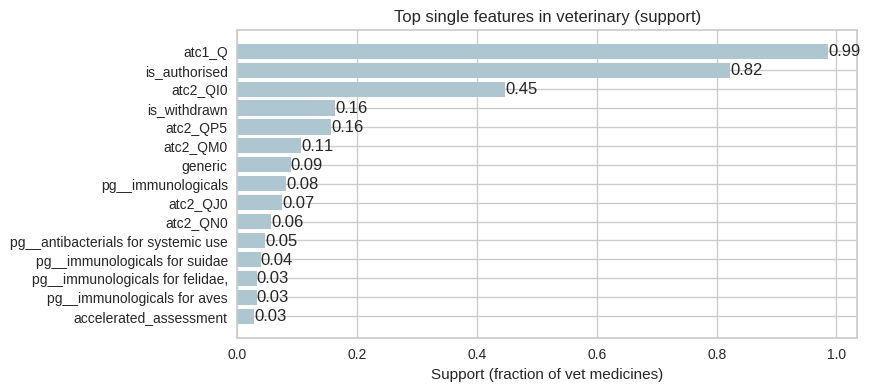

In [175]:
freq = apriori(X_bin.astype(bool), min_support=0.02, use_colnames=True)
freq["itemset_size"] = freq["itemsets"].apply(len)

# Rules (lift is the key metric to avoid “confidence traps”)
rules = association_rules(freq, metric="lift", min_threshold=1.0)

# Add helper columns for plotting
rules["antecedent_len"] = rules["antecedents"].apply(len)
rules["consequent_len"] = rules["consequents"].apply(len)
rules["rule"] = rules.apply(lambda r: f"{list(r['antecedents'])} → {list(r['consequents'])}", axis=1)

# Plotting
top1 = (freq[freq["itemset_size"]==1]
        .sort_values("support", ascending=False)
        .head(15)
        .copy())
top1["label"] = top1["itemsets"].apply(lambda s: list(s)[0])

plt.figure(figsize=(8,4))
bars = plt.barh(top1["label"][::-1], top1["support"][::-1], color="#AEC6CF")

# Adding data labels
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.2f}',
        va='center',
        ha='left'
    )
plt.title("Top single features in veterinary (support)")
plt.xlabel("Support (fraction of vet medicines)")
plt.show()

Feature frequency (“support”) shows that the most common variables are structural, not informative. For example, ATC level 1 = Q is a standard veterinary coding convention, and the high share of authorized products (~82%) reflects the regulatory context rather than a distinct segment.


The real analytical signal lies in mid-frequency features, specific ATC sublevels (e.g., QI0, QP5, QM0) and flags like generic or withdrawn. Less common pharmacotherapeutic groups (e.g., immunologicals, systemic antibacterials) add the variation needed to meaningfully differentiate clusters, while near-constant features mainly provide background context.

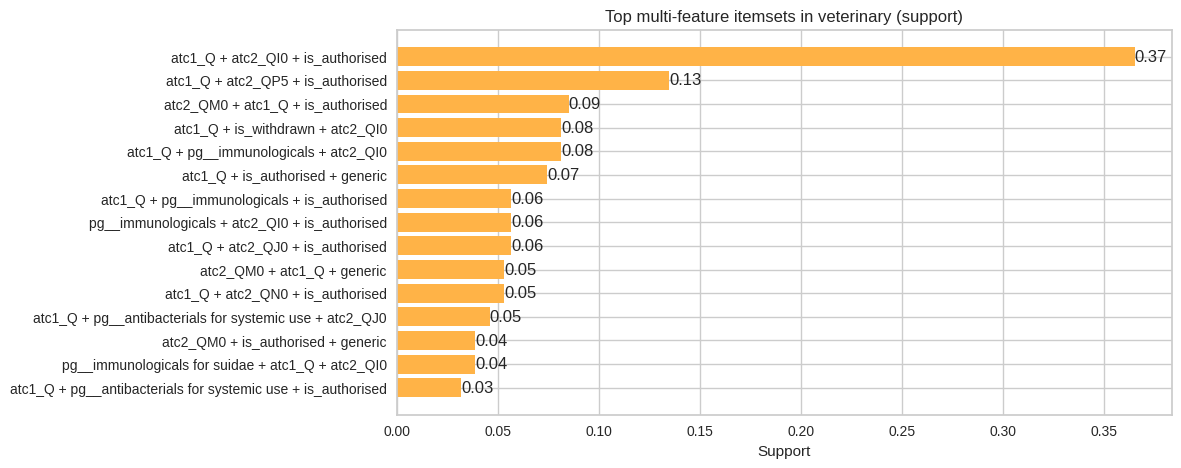

In [176]:
# Top itemsets with more than one item
topk = (freq[freq["itemset_size"]>=3]
        .sort_values(["itemset_size","support"], ascending=[True, False])
        .head(15)
        .copy())
topk["label"] = topk["itemsets"].apply(lambda s: " + ".join(list(s)))

plt.figure(figsize=(10,5))
bars = plt.barh(topk["label"][::-1], topk["support"][::-1], color="#FFB347")

# Adding data labels
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.2f}',
        va='center',
        ha='left'
    )
plt.title("Top multi-feature itemsets in veterinary (support)")
plt.xlabel("Support")
plt.show()

Now we check the correlation between suppot and lift for the dataset's rules

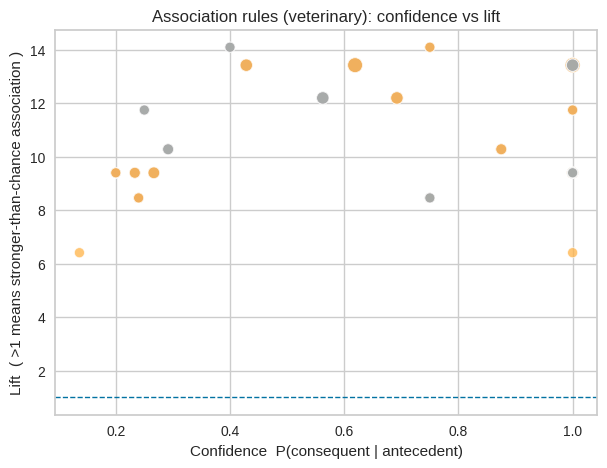

In [177]:
# Colors to differentiate data points
PASTELS = ["#AEC6CF","#FFB347","#B39EB5","#77DD77","#F49AC2",
           "#CFCFC4","#FFD1DC","#C9C9FF","#FDFD96","#B0E0E6"]
# keep only a reasonable number of rules for a readable plot
plot_rules = rules.sort_values(["lift","support"], ascending=False).head(80).copy()
plt.figure(figsize=(7,5))
plt.scatter(
    plot_rules["confidence"],
    plot_rules["lift"],
    s=(plot_rules["support"]*2500).clip(30, 400),
    c=[PASTELS[min(i, len(PASTELS)-1)] for i in plot_rules["antecedent_len"]],
    alpha=0.75,
    edgecolors="white",
    linewidths=0.6
)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.title("Association rules (veterinary): confidence vs lift")
plt.xlabel("Confidence  P(consequent | antecedent)")
plt.ylabel("Lift  ( >1 means stronger-than-chance association )")
plt.show()

In this plot, confidence reflects how often the outcome occurs given the condition, while lift measures how much stronger that link is than chance. The many rules with very high lift (8–14) show that some rare categories become highly predictable when specific precursors are present.

This indicates strong internal consistency: ATC2 codes and pharmacotherapeutic labels are closely aligned, not independent. Overall, the rules reflect the logical mapping between classification systems and the link between product status and generic designation.

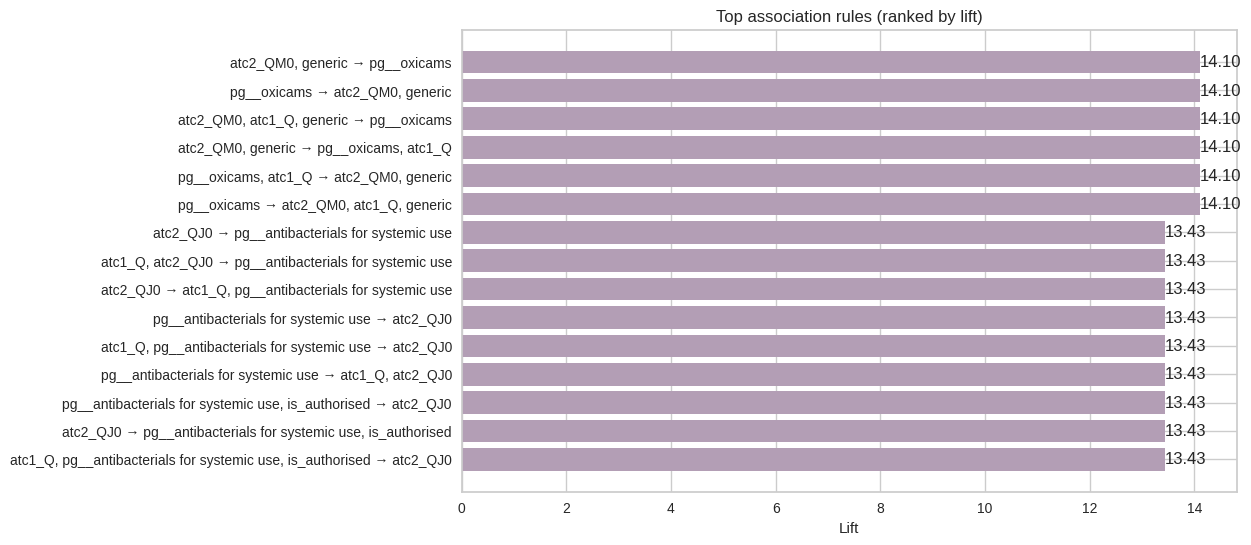

In [178]:
# Take top rules by lift (filter out trivial 1→1 rules if you want)
top_rules = (rules
             .sort_values(["lift","support"], ascending=False)
             .head(15)
             .copy())

top_rules["rule_str"] = top_rules.apply(
    lambda r: f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}",
    axis=1
)
plt.figure(figsize=(10,6))
bars = plt.barh(top_rules["rule_str"][::-1], top_rules["lift"][::-1], color="#B39EB5")

# Adding data labels
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.2f}',
        va='center',
        ha='left'
    )
plt.title("Top association rules (ranked by lift)")
plt.xlabel("Lift")
plt.show()

Because some features are nearly universal (e.g., atc1_Q) or very common (e.g., is_authorised), they dominate high-support itemsets and can make top combinations seem obvious. This doesn’t invalidate the analysis, it reflects the dataset’s baseline structure.

More actionable insights come from itemsets with high lift and specific combinations (e.g., ATC2 + pharmacotherapeutic group + status/generic), rather than those driven by near-constant features.

#### **Exploring Clustering**

In [179]:
from sklearn.metrics import pairwise_distances
X = X_bin.astype(int).to_numpy()
D_full = pairwise_distances(X, metric="jaccard") #Using jacard
# summarize distances (exclude diagonal)
mask = ~np.eye(D_full.shape[0], dtype=bool)
vals = D_full[mask]

print(pd.Series(vals).describe())

count    79242.000000
mean         0.566274
std          0.229727
min          0.000000
25%          0.500000
50%          0.600000
75%          0.714286
max          1.000000
dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


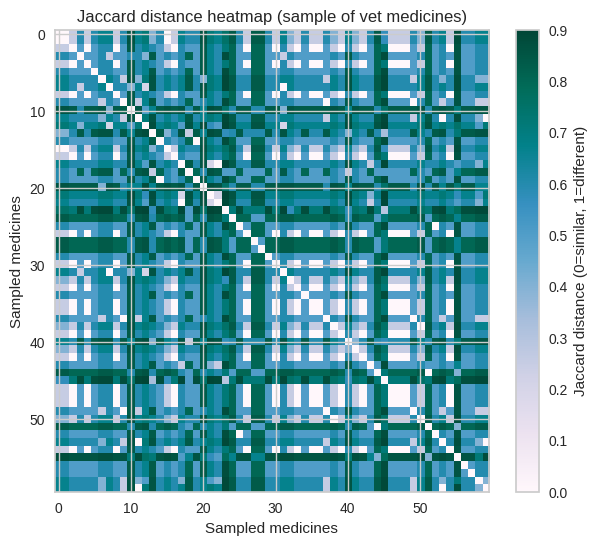

In [180]:
# Creating a heatmap to visualize distances between different medicines
np.random.seed(7)
sample_size = 60
idx = np.random.choice(np.arange(X.shape[0]), size=sample_size, replace=False)
D_sample = D_full[np.ix_(idx, idx)]
plt.figure(figsize=(7,6))
plt.imshow(D_sample, aspect="auto", cmap="PuBuGn")
plt.colorbar(label="Jaccard distance (0=similar, 1=different)")
plt.title("Jaccard distance heatmap (sample of vet medicines)")
plt.xlabel("Sampled medicines")
plt.ylabel("Sampled medicines")
plt.show()


The Jaccard distance analysis shows moderate differentiation among veterinary medicines (median = 0.60, SD = 0.23), an ideal balance for unsupervised learning. The data are neither overly uniform nor randomly dispersed. A minimum distance of 0.0 indicates some identical feature profiles, suggesting natural archetypes. Overall, the dataset has sufficient structure and variation for hierarchical clustering to identify meaningful segments.

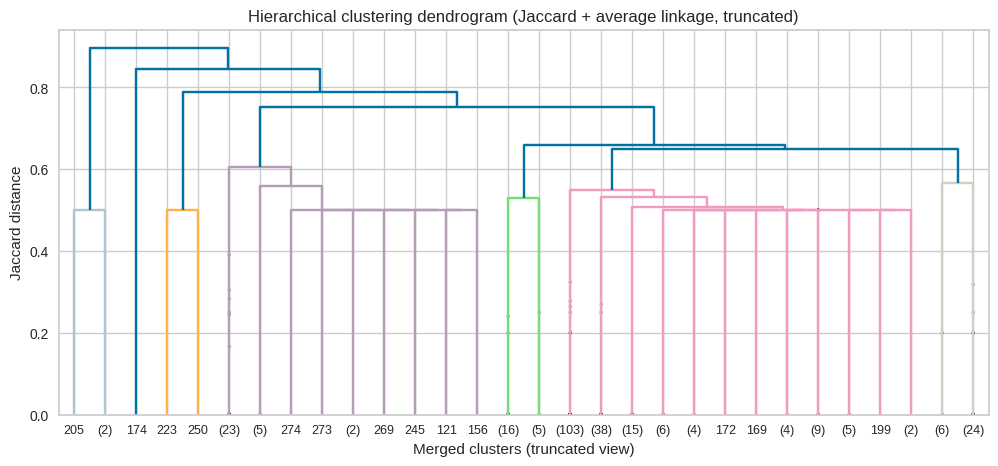

In [181]:
from scipy.cluster.hierarchy import set_link_color_palette
# Convert full distance matrix to condensed form for scipy
condensed = squareform(D_full, checks=False)

# Hierarchical clustering using average linkage
Z = linkage(condensed, method="average")

# pastel palette for dendrogram branches
set_link_color_palette(PASTELS)

plt.figure(figsize=(12,5))
dendrogram(
    Z,
    truncate_mode="lastp",  # show only last merges
    p=30,                   # number of leaf clusters displayed
    leaf_rotation=0,
    leaf_font_size=9,
    show_contracted=True
)
plt.title("Hierarchical clustering dendrogram (Jaccard + average linkage, truncated)")
plt.xlabel("Merged clusters (truncated view)")
plt.ylabel("Jaccard distance")
plt.show()


The hierarchical clustering dendrogram maps how veterinary medicines group by feature similarity. Merges at high Jaccard distances (0.8–0.9) show a few clearly distinct primary groups that only combine when highly dissimilar items are forced together.

At mid-range distances (0.5–0.65), gradual branching reveals meaningful sub-clusters—medicines that share core traits but still differ in relevant ways. The visible gaps between merges suggest that 3–6 clusters would provide a statistically sound segmentation, confirming the presence of structured “families” rather than random variation.

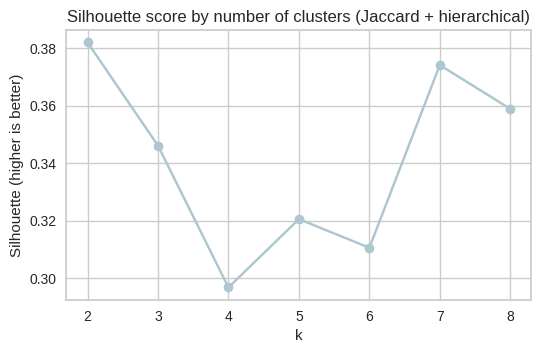

In [182]:
# Using silhouette score to determine number of clusters
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
scores = []
for k in range(2, 9):
    model = AgglomerativeClustering(n_clusters=k, metric="precomputed", linkage="average")
    labels = model.fit_predict(D_full)
    s = silhouette_score(D_full, labels, metric="precomputed")
    scores.append((k, s))

scores_df = pd.DataFrame(scores, columns=["k", "silhouette"])
plt.figure(figsize=(6,3.5))
plt.plot(scores_df["k"], scores_df["silhouette"], marker="o", color=PASTELS[0])
plt.title("Silhouette score by number of clusters (Jaccard + hierarchical)")
plt.xlabel("k")
plt.ylabel("Silhouette (higher is better)")
plt.xticks(scores_df["k"])
plt.show()


Silhouette suggests k=2 is the strongest coarse split, but k=7 provides almost the same silhouette while producing a more granular segmentation. Because the project goal is to characterize different combinations of regulatory/product features (and later compare by species), I select k=7 as a balance between cluster quality and interpretability.

In [183]:
# Testing k=7 and k=2

k = 7
model = AgglomerativeClustering(n_clusters=k, metric="precomputed", linkage="average")
labels = model.fit_predict(D_full)
print("Clusters compsition using k=7 ")
display(pd.Series(labels).value_counts().sort_index())
print("Clusters compsition using k=2 ")
k = 2
model = AgglomerativeClustering(n_clusters=k, metric="precomputed", linkage="average")
labels = model.fit_predict(D_full)
display(pd.Series(labels).value_counts().sort_index())

Clusters compsition using k=7 


,count
0,36
1,30
2,189
3,3
4,2
5,1
6,21


Clusters compsition using k=2 


,count
0,279
1,3


1. Clustering as a diagnostic tool
Hierarchical clustering was used to assess the dataset’s natural structure. Under the current features, the veterinary data are highly homogeneous: most medicines fall into one dominant baseline cluster. This suggests a cohesive market profile rather than multiple dense subsegments.

2. Why k = 2 is the most defensible cut
Although silhouette scores were high at k = 2 and k = 7, cluster-size diagnostics favor k = 2. At this level, the model separates the large baseline group from a small set of atypical outliers. Higher k values merely split these outliers into tiny, unstable clusters, which are better viewed as exceptions than true segments. Thus, k = 2 best reflects the global structure.

3. MBA as the primary discovery tool
Market Basket Analysis (MBA) serves as the main analytical method, with clustering used to validate the feature space. Since most medicines share a similar signal (3–4 active features), segmentation adds limited value. Association rules (support, confidence, lift) instead highlight meaningful attribute bundles, capturing differentiation without over-interpreting rare outliers.

In [184]:
from sklearn.metrics import pairwise_distances
# Distance matrix using jaccard
X = X_bin.astype(int).to_numpy()
D_full = pairwise_distances(X, metric="jaccard")
# k=2
model = AgglomerativeClustering(n_clusters=2, metric="precomputed", linkage="average")
vet["cluster_k2"] = model.fit_predict(D_full)
print("Clusters composition k=2")
display(pd.DataFrame(vet["cluster_k2"].value_counts()))
display(vet.groupby("cluster_k2")[["missing_atc2","missing_pg"]].mean().mul(100).round(2))
print("Identified outliers")
small_label = vet["cluster_k2"].value_counts().idxmin()

outliers = vet[vet["cluster_k2"]==small_label].copy()

outliers[["medicine_name","authorisation_status_clean","atc_level2","pharm_group_list",
          "missing_atc2","missing_pg","generic","accelerated_assessment","exceptional_circumstances",
          "is_withdrawn","is_refused"]]

Clusters composition k=2


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


,count
cluster_k2,
0,279
1,3


,missing_atc2,missing_pg
cluster_k2,,
0,0.0,1.08
1,100.0,66.67


Identified outliers


,medicine_name,authorisation_status_clean,atc_level2,pharm_group_list,missing_atc2,missing_pg,generic,accelerated_assessment,exceptional_circumstances,is_withdrawn,is_refused
1361,Vectormune FP ILT,authorised,<NA>,[],1,1,False,False,False,0,False
1574,Solensia,authorised,<NA>,[analgesics],1,0,False,False,False,0,False
1629,Horse Allo 20,refused,<NA>,[],1,1,False,False,False,0,True


Hierarchical clustering (Jaccard, average linkage) initially appeared plausible across k = 3–7, but cluster-size diagnostics consistently showed one dominant cluster and several tiny groups (1–3 medicines). This indicated fragmentation rather than true segmentation.

Profiling the k = 2 solution revealed that the small cluster (n = 3) was defined entirely by missing metadata: absent ATC level-2 codes and largely empty pharmacotherapeutic labels. These medicines were not enriched for special approvals or distinct regulatory pathways, confirming that separation was driven by incomplete coding, not strategic or therapeutic differences.

A sensitivity analysis excluding incomplete records eliminated the apparent separation altogether. Thus, clustering was capturing metadata completeness rather than meaningful regulatory structure.

Consequently, clustering is retained only as a diagnostic tool. The results highlight the strong homogeneity of veterinary medicines under the available features and support shifting to methods (e.g., co-occurrence/association analysis) that identify attribute bundles rather than forcing artificial partitions.

#### **Exploring Species Segmentation**

In [185]:
# 1) Primary species label (one value per medicine)
def primary_species(species_list):
    if not isinstance(species_list, list) or len(species_list) == 0:
        return "unknown"
    if len(species_list) == 1:
        return species_list[0]
    return "multi"
vet["species_primary"] = vet["species_list"].apply(primary_species)

# 2) Map primary species to species groups
SPECIES_GROUP_MAP = {
    # companion animals
    "dogs":"companion", "cats":"companion", "ferrets":"companion",
    "rabbits":"companion", "guinea pigs":"companion",

    # livestock
    "cattle":"livestock", "pigs":"livestock", "sheep":"livestock", "goats":"livestock",

    # equine
    "horses":"equine",

    # poultry
    "chicken":"poultry", "turkeys":"poultry", "ducks":"poultry",
    "pheasants":"poultry", "avian":"poultry",
    "embryonated chicken eggs":"poultry",

    # aquaculture
    "atlantic salmon":"aquaculture",
    "salmonidae":"aquaculture",
    "salmonid fish":"aquaculture",

    # apiary
    "bees":"apiary", "honey bees":"apiary",
}

def to_species_group(sp):
    if sp in ["unknown", ""]:
        return "unknown"
    if sp == "multi":
        return "multi"
    return SPECIES_GROUP_MAP.get(sp, "other")

vet["species_group"] = vet["species_primary"].apply(to_species_group)

# Check distributions
print("species_primary counts:")
display(vet["species_primary"].value_counts())

print("\nspecies_group counts:")
display(vet["species_group"].value_counts())

species_primary counts:


,count
species_primary,
multi,78
dogs,71
pigs,36
cats,28
horses,18
chicken,15
cattle,13
sheep,5
rabbits,4



species_group counts:


,count
species_group,
companion,103
multi,78
livestock,54
equine,18
poultry,17
other,5
unknown,3
apiary,3
aquaculture,1


The species distribution within the veterinary dataset is largely concentrated in three core segments: companion animals ($n=103$), multi-species applications ($n=78$), and livestock ($n=54$). Together, these form the analytical backbone of the study. In contrast, niche categories such as aquaculture ($n=1$) and apiary ($n=3$) exhibit very low frequencies. To maintain statistical integrity, we will treat these minor groups as descriptive outliers rather than primary segments for heavy inference. This ensures that our conclusions regarding "special approvals" remain representative of broader market trends while acknowledging the presence of specialized, low-frequency medical pathways.

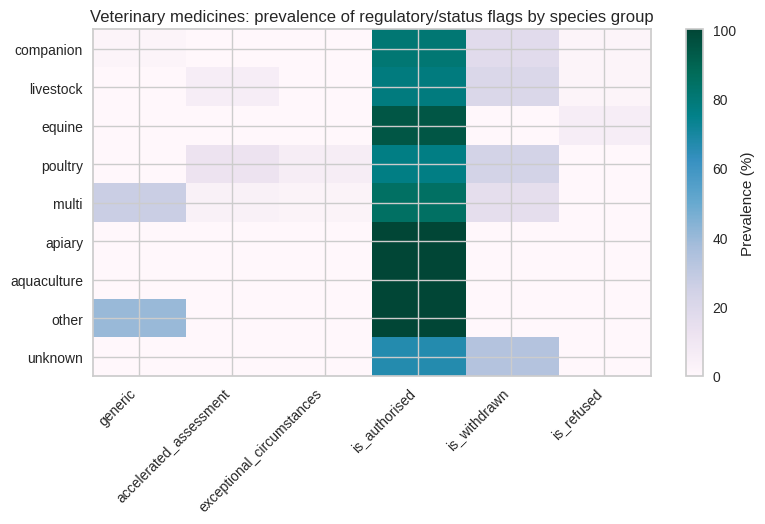

In [186]:
# Reviewing species group prevalence of regulatory flags
flag_cols = [
    "generic",
    "accelerated_assessment",
    "exceptional_circumstances",
    "is_authorised",
    "is_withdrawn",
    "is_refused"
]
# prevalence (%) by species group
prev = (
    vet.groupby("species_group")[flag_cols]
       .mean()
       .mul(100)
       .round(2)
)
# order rows for readability
row_order = ["companion","livestock","equine","poultry","multi","apiary","aquaculture","other","unknown"]
prev = prev.reindex([r for r in row_order if r in prev.index])

# Plotting
plt.figure(figsize=(9,4.5))
plt.imshow(prev.values, aspect="auto", cmap="PuBuGn")  # soft/pastel-ish
plt.colorbar(label="Prevalence (%)")
plt.xticks(range(len(prev.columns)), prev.columns, rotation=45, ha="right")
plt.yticks(range(len(prev.index)), prev.index)
plt.title("Veterinary medicines: prevalence of regulatory/status flags by species group")
plt.show()

Regulatory flags and authorization outcomes vary by species group. Poultry has the highest accelerated assessments and is the only group with notable exceptional-circumstances cases, livestock is moderate. Generic designation is concentrated in multi-species medicines. Equine products are mostly authorized but have the highest refusal rate, while poultry and livestock show higher withdrawal rates. These differences support species-based segmentation and stratified unsupervised mining to identify group-specific feature patterns.

**Exploring Regulatory Complexity**

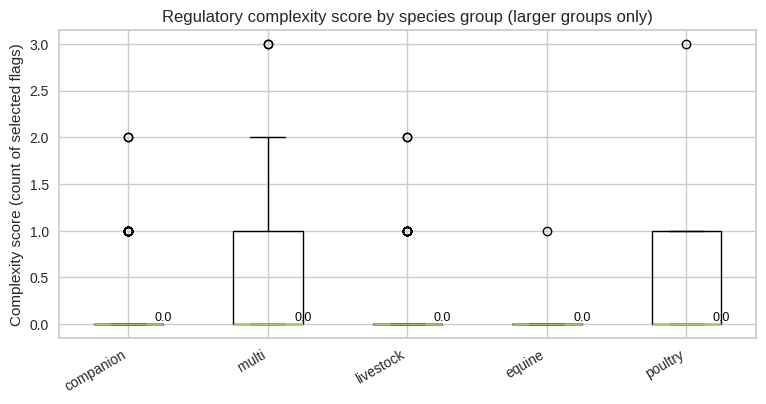

In [187]:
complexity_cols = ["generic","accelerated_assessment","exceptional_circumstances","is_withdrawn","is_refused"]
vet["reg_complexity_score"] = vet[complexity_cols].sum(axis=1).astype(int)
groups = [g for g, n in vet["species_group"].value_counts().items() if n >= 10]  # avoid tiny groups
plot_df = vet[vet["species_group"].isin(groups)].copy()

plt.figure(figsize=(9,4))
data = [plot_df.loc[plot_df["species_group"]==g, "reg_complexity_score"] for g in groups]
boxplot = plt.boxplot(data, tick_labels=groups)
plt.title("Regulatory complexity score by species group (larger groups only)")
plt.ylabel("Complexity score (count of selected flags)")
plt.xticks(rotation=30, ha="right")

# Add data labels (median values)
for i, line in enumerate(boxplot['medians']):
    x, y = line.get_xdata()[1], line.get_ydata()[1] # x and y coordinates of the median line
    median_val = round(y, 1)
    plt.text(x, y, f'{median_val}', ha='center', va='bottom', fontsize=9, color='black')

plt.show()

In [188]:
score_summary = vet.groupby("species_group").agg(
    n=("reg_complexity_score","size"),
    mean_score=("reg_complexity_score","mean"),
    pct_ge1=("reg_complexity_score", lambda s: (s>=1).mean()*100),
    pct_ge2=("reg_complexity_score", lambda s: (s>=2).mean()*100),
).round({"mean_score":3, "pct_ge1":2, "pct_ge2":2})
score_summary

,n,mean_score,pct_ge1,pct_ge2
species_group,,,,
apiary,3,0.000,0.00,0.00
aquaculture,1,0.000,0.00,0.00
companion,103,0.214,19.42,1.94
equine,18,0.056,5.56,0.00
livestock,54,0.278,24.07,3.70
multi,78,0.487,41.03,5.13
other,5,0.400,40.00,0.00
poultry,17,0.412,29.41,5.88
unknown,3,0.333,33.33,0.00


When regulatory/status indicators are summarized into a simple complexity score, clear differences emerge across veterinary species groups. Multi-species medicines have the highest average complexity and the highest share of products with at least one complexity indicator (≈41%), suggesting that products authorized across multiple species are more likely to exhibit non-trivial regulatory/status features (e.g., generic designation, accelerated assessment, withdrawal/refusal). Poultry also shows relatively elevated complexity (≈29% with score ≥1 and ≈6% with score ≥2), consistent with its higher prevalence of accelerated assessment and exceptional circumstances. Livestock and companion segments are intermediate, while equine medicines show very low complexity signal under this definition. These results demonstrate that veterinary medicines are not homogeneous by species segment, and they motivate species-stratified unsupervised mining to identify which specific feature bundles characterize each segment.

**Exploring Assosiation Rules Mining**

In [189]:
# groups we will analyze (enough rows to be meaningful)
major_groups = ["companion", "livestock", "multi", "equine", "poultry"]

def mba_for_group(Xg, min_support=0.10):
    """
    Returns frequent itemsets + rules for one group.
    min_support is set per-group below (as a function of n).
    """
    freq = apriori(Xg.astype(bool), min_support=min_support, use_colnames=True)
    if len(freq) == 0:
        return freq, pd.DataFrame()
    rules = association_rules(freq, metric="lift", min_threshold=1.0)
    return freq, rules

group_outputs = {}

for g in major_groups:
    sub = vet[vet["species_group"] == g].copy()
    n = len(sub)
    if n < 10:
        continue

    # Set support threshold to avoid rules driven by 1–2 cases:
    # at least 3 medicines per group => min_support = 3/n (capped between 0.10 and 0.30)
    min_support = min(max(3/n, 0.10), 0.30)

    Xg = X_bin.loc[sub.index]

    freq_g, rules_g = mba_for_group(Xg, min_support=min_support)
    group_outputs[g] = {"n": n, "min_support": min_support, "freq": freq_g, "rules": rules_g}

    print(f"\n=== {g.upper()} ===")
    print(f"n={n}, min_support={min_support:.3f}, freq_itemsets={len(freq_g)}, rules={len(rules_g)}")


=== COMPANION ===
n=103, min_support=0.100, freq_itemsets=15, rules=18

=== LIVESTOCK ===
n=54, min_support=0.100, freq_itemsets=27, rules=62

=== MULTI ===
n=78, min_support=0.100, freq_itemsets=37, rules=96

=== EQUINE ===
n=18, min_support=0.167, freq_itemsets=11, rules=22

=== POULTRY ===
n=17, min_support=0.176, freq_itemsets=23, rules=64


/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)
/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


In [190]:
# Top rules by lift per animal group
for g, obj in group_outputs.items():
    rules_g = obj["rules"].copy()
    if len(rules_g) == 0:
        print(f"\n--- {g.upper()} --- (no rules found)")
        continue

    # nicer readable columns
    rules_g["antecedents_str"] = rules_g["antecedents"].apply(lambda s: ", ".join(sorted(list(s))))
    rules_g["consequents_str"] = rules_g["consequents"].apply(lambda s: ", ".join(sorted(list(s))))

    top = (rules_g.sort_values(["lift","support"], ascending=False)
                 .head(10)[["support","confidence","lift","antecedents_str","consequents_str"]])

    print(f"\n--- {g.upper()} (Top 10 rules by lift) ---")
    display(top)




--- COMPANION (Top 10 rules by lift) ---


,support,confidence,lift,antecedents_str,consequents_str
11,0.281553,0.353659,1.138338,"atc1_Q, is_authorised",atc2_QI0
14,0.281553,0.906250,1.138338,atc2_QI0,"atc1_Q, is_authorised"
0,0.281553,0.906250,1.124623,atc2_QI0,is_authorised
1,0.281553,0.349398,1.124623,is_authorised,atc2_QI0
10,0.281553,0.906250,1.124623,"atc1_Q, atc2_QI0",is_authorised
15,0.281553,0.349398,1.124623,is_authorised,"atc1_Q, atc2_QI0"
4,0.310680,0.313725,1.009804,atc1_Q,atc2_QI0
5,0.310680,1.000000,1.009804,atc2_QI0,atc1_Q
12,0.281553,1.000000,1.009804,"atc2_QI0, is_authorised",atc1_Q
13,0.281553,0.284314,1.009804,atc1_Q,"atc2_QI0, is_authorised"



--- LIVESTOCK (Top 10 rules by lift) ---


,support,confidence,lift,antecedents_str,consequents_str
8,0.222222,1.000000,1.2,pg__immunologicals,atc2_QI0
9,0.222222,0.266667,1.2,atc2_QI0,pg__immunologicals
34,0.222222,1.000000,1.2,"atc1_Q, pg__immunologicals",atc2_QI0
35,0.222222,0.266667,1.2,"atc1_Q, atc2_QI0",pg__immunologicals
38,0.222222,1.000000,1.2,pg__immunologicals,"atc1_Q, atc2_QI0"
39,0.222222,0.266667,1.2,atc2_QI0,"atc1_Q, pg__immunologicals"
4,0.203704,1.000000,1.2,is_withdrawn,atc2_QI0
5,0.203704,0.244444,1.2,atc2_QI0,is_withdrawn
28,0.203704,1.000000,1.2,"atc1_Q, is_withdrawn",atc2_QI0
29,0.203704,0.244444,1.2,"atc1_Q, atc2_QI0",is_withdrawn



--- MULTI (Top 10 rules by lift) ---


,support,confidence,lift,antecedents_str,consequents_str
17,0.141026,0.647059,4.588235,atc2_QJ0,pg__antibacterials for systemic use
67,0.141026,0.647059,4.588235,"atc1_Q, atc2_QJ0",pg__antibacterials for systemic use
71,0.141026,0.647059,4.588235,atc2_QJ0,"atc1_Q, pg__antibacterials for systemic use"
16,0.141026,1.000000,4.588235,pg__antibacterials for systemic use,atc2_QJ0
66,0.141026,1.000000,4.588235,"atc1_Q, pg__antibacterials for systemic use",atc2_QJ0
70,0.141026,1.000000,4.588235,pg__antibacterials for systemic use,"atc1_Q, atc2_QJ0"
46,0.115385,1.000000,4.588235,"is_authorised, pg__antibacterials for systemic...",atc2_QJ0
49,0.115385,0.529412,4.588235,atc2_QJ0,"is_authorised, pg__antibacterials for systemic..."
86,0.115385,1.000000,4.588235,"atc1_Q, is_authorised, pg__antibacterials for ...",atc2_QJ0
90,0.115385,0.529412,4.588235,"atc1_Q, atc2_QJ0","is_authorised, pg__antibacterials for systemic..."



--- EQUINE (Top 10 rules by lift) ---


,support,confidence,lift,antecedents_str,consequents_str
0,0.944444,1.000000,1.058824,atc1_Q,is_authorised
1,0.944444,1.000000,1.058824,is_authorised,atc1_Q
2,0.555556,1.000000,1.058824,atc2_QI0,is_authorised
3,0.555556,0.588235,1.058824,is_authorised,atc2_QI0
6,0.555556,0.588235,1.058824,atc1_Q,atc2_QI0
7,0.555556,1.000000,1.058824,atc2_QI0,atc1_Q
10,0.555556,1.000000,1.058824,"atc1_Q, atc2_QI0",is_authorised
11,0.555556,0.588235,1.058824,"atc1_Q, is_authorised",atc2_QI0
12,0.555556,1.000000,1.058824,"atc2_QI0, is_authorised",atc1_Q
13,0.555556,0.588235,1.058824,atc1_Q,"atc2_QI0, is_authorised"



--- POULTRY (Top 10 rules by lift) ---


,support,confidence,lift,antecedents_str,consequents_str
0,0.176471,0.50,2.125,pg__immunologicals for aves,is_withdrawn
1,0.176471,0.75,2.125,is_withdrawn,pg__immunologicals for aves
20,0.176471,0.50,2.125,"atc1_Q, pg__immunologicals for aves",is_withdrawn
21,0.176471,0.75,2.125,"atc1_Q, is_withdrawn",pg__immunologicals for aves
24,0.176471,0.50,2.125,pg__immunologicals for aves,"atc1_Q, is_withdrawn"
25,0.176471,0.75,2.125,is_withdrawn,"atc1_Q, pg__immunologicals for aves"
27,0.176471,0.50,2.125,"atc2_QI0, pg__immunologicals for aves",is_withdrawn
28,0.176471,0.75,2.125,"atc2_QI0, is_withdrawn",pg__immunologicals for aves
29,0.176471,0.50,2.125,pg__immunologicals for aves,"atc2_QI0, is_withdrawn"
30,0.176471,0.75,2.125,is_withdrawn,"atc2_QI0, pg__immunologicals for aves"


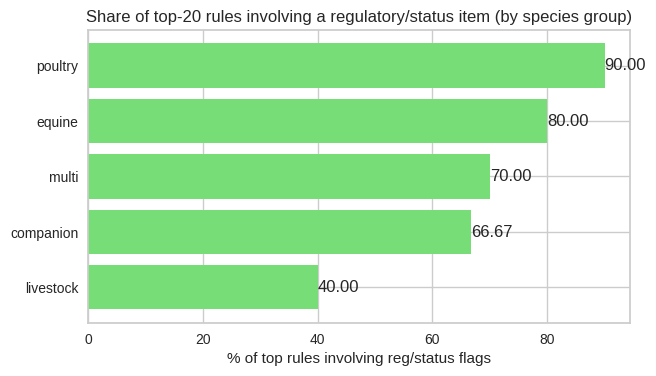

In [191]:
reg_items = {"generic","accelerated_assessment","exceptional_circumstances","is_withdrawn","is_refused","is_authorised"}

summary = []
for g, obj in group_outputs.items():
    rules_g = obj["rules"]
    if len(rules_g)==0:
        continue
    top = rules_g.sort_values(["lift","support"], ascending=False).head(20)

    def has_reg_items(s):
        return any(item in reg_items for item in s)

    pct_reg = ((top["antecedents"].apply(has_reg_items) | top["consequents"].apply(has_reg_items)).mean())*100
    summary.append((g, obj["n"], pct_reg))

summary_df = pd.DataFrame(summary, columns=["species_group","n","pct_top20_rules_with_reg_item"]).sort_values("pct_top20_rules_with_reg_item", ascending=False)

# Plotting
plt.figure(figsize=(7,3.8))
bars = plt.barh(summary_df["species_group"][::-1], summary_df["pct_top20_rules_with_reg_item"][::-1], color=PASTELS[3])

# Adding data labels
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.2f}',
        va='center',
        ha='left'
    )

plt.title("Share of top-20 rules involving a regulatory/status item (by species group)")
plt.xlabel("% of top rules involving reg/status flags")
plt.show()

Across species groups, the share of top association rules that include a regulatory/status indicator differs substantially. Poultry has the highest share (≈90%), reflecting that its strongest co-occurrence bundles repeatedly involve status outcomes such as withdrawal alongside therapeutic classification (e.g., immunologicals for aves). Multi-species and companion groups also show many rules involving regulatory/status items, partly because high-frequency status indicators (especially “authorised”) commonly co-occur with classification features. Livestock shows a lower share (≈40%), but its top rules include meaningful status structure such as withdrawal concentrating in specific ATC subgroups. Overall, the rule composition supports that species segments differ not only in prevalence of flags but also in which feature bundles (classification vs regulatory/status) dominate their co-occurrence structure.

##**M4 - Market Basket Analysis**

###**Motivation and Scope**

Milestone 3 demonstrated that traditional clustering methods are poorly suited for the European medicines dataset, as overlapping indicators and gradual profile shifts prevent the formation of distinct categories. Challenges such as skewed binary distributions and the rarity of refusal decisions often cause dominant patterns to obscure more nuanced insights. Consequently, the project has transitioned from forced categorization toward identifying frequently co-occurring features. This shift allows us to better capture the regulatory signatures that define medicine profiles without relying on rigid, artificial groupings.

While the veterinary medicine analysis provided a vital baseline, validating Market Basket Analysis as an effective tool for identifying "regulatory combinations", it will now serve as a parallel reference rather than the primary focus. By concentrating on human medicines, the project can more deeply investigate how special approval pathways, such as orphan designations and accelerated assessments, cluster into consistent combinations. This approach recognizes that these pathways reflect a holistic regulatory judgment, which Market Basket Analysis is uniquely equipped to decode and analyze.

In Milestone 4, my individual contribution is a refined Market Basket-Association Rules analysis on human medicines to identify, first, the most consistent and non-random bundles of regulatory pathway indicators, and second, which bundles are disproportionately associated with authorization outcomes, especially refusal/withdrawal versus authorization, given prior evidence that accelerated conditional mechanisms appear linked to higher refusal risk compared to standard pathways.

###**Individual Domain Question**

Which combinations of regulatory pathway indicators co-occur most consistently in human medicines, and which combinations are disproportionately associated with authorization outcomes?

###**Scope Boundaries and Unit of Analysis**

**Primary scope:** Human medicines only (main analysis and conclusions).

**Parallel reference:** Veterinary medicine MBA results are used only as a comparison point.

**Outcomes of interest:** Authorization status categories, with an emphasis on refusal and withdrawal patterns relative to authorization.

**Transaction (basket)** = one medicine record (one product observation).

**Items** = observed medicine features, primarily regulatory pathway indicators (binary flags), optionally enriched later with a limited set of therapeutic descriptors if it improves interpretability without creating excessive sparsity as seen in veterinary medicine results.

###**Refinement for Milestone 4**

Given this milestone is for refining and streghtening previous investigations and assessments, we can stregthen MBA by conducting the following goals:

*  Expanding beyond veterinary to human medicines (primary objective)
*  Running systematic parameter tuning (support, confidence, lift, max rule length)
*  Adding robustness checks such as sensitivity to thresholds, and stability of top rules











##**Human Only Extraction & Basket Matrix Creation**

In [192]:
# Distribution of flags in humans
human_df = drugs_df[drugs_df["category_clean"] == "human"].copy()

print("Human rows:", len(human_df))
print("Unique product_number:", human_df["product_number"].nunique())
print("product_number is unique:", human_df["product_number"].is_unique)
print("\nHuman status counts:\n", human_df["authorisation_status_clean"].value_counts(dropna=False))


Human rows: 1706
Unique product_number: 1706
product_number is unique: True

Human status counts:
 authorisation_status_clean
authorised    1341
withdrawn      311
refused         53
unknown          1
Name: count, dtype: Int64


In [193]:
# Only keep rows where the outcome is one of the authorisation_status_clean categories.
human_known = human_df[human_df["authorisation_status_clean"].isin(["authorised", "refused", "withdrawn"])
].copy()

print("Human known-outcome rows:", len(human_known))
print("\nKnown outcome counts:\n", human_known["authorisation_status_clean"].value_counts())
print("\nCheck exactly-one outcome flag (should be 1s only):\n",
      (human_known[["is_authorised","is_refused","is_withdrawn"]].sum(axis=1)).value_counts(dropna=False).head())

Human known-outcome rows: 1705

Known outcome counts:
 authorisation_status_clean
authorised    1341
withdrawn      311
refused         53
Name: count, dtype: Int64

Check exactly-one outcome flag (should be 1s only):
 1    1705
Name: count, dtype: int64


In [194]:
reg_items = [
    "generic",
    "biosimilar",
    "patient_safety",
    "orphan_medicine",
    "accelerated_assessment",
    "conditional_approval",
    "exceptional_circumstances",
    "additional_monitoring",
]

###**Basket Matrix - Regulatory-Only**

In [195]:
X_human_A = (
    human_df
    .set_index("product_number")[reg_items]
    .fillna(False)
    .astype(int)
)

print("X_human_A shape:", X_human_A.shape)
X_human_A.head()

X_human_A shape: (1706, 8)


,generic,biosimilar,patient_safety,orphan_medicine,accelerated_assessment,conditional_approval,exceptional_circumstances,additional_monitoring
product_number,,,,,,,,
2455,0,0,0,1,0,0,0,0
4582,1,0,0,0,0,0,0,0
4577,0,0,0,1,0,0,1,1
5814,0,0,0,0,0,0,0,1
3729,0,0,0,0,0,0,0,0


The foundation of this phase is the construction of a Basket Matrix, which transforms the European medicines dataset into a binary transactional format. In this model, each row represents a unique Product Number, acting as a "shopping basket." The columns represent various Regulatory Features, such as Orphan Designation or Accelerated Assessment, where a value of 1 indicates the presence of an attribute and 0 its absence. This structure is essential for Market Basket Analysis, as it allows algorithms like Apriori to identify "Frequent Itemsets", groups of features that appear together significantly more often than chance would suggest. For example, while Product 2455 contains a simple basket of (orphan_medicine), Product 4577 reveals a more complex regulatory bundle: (orphan_medicine, exceptional_circumstances, additional_monitoring).

###**Basket Matrix - Regulatory + Outcome Items**

In [196]:
X_known_A = (
    human_known
    .set_index("product_number")[reg_items]
    .fillna(False)
    .astype(int)
)

X_outcomes = (
    human_known
    .set_index("product_number")[["is_authorised","is_refused","is_withdrawn"]]
    .rename(columns={
        "is_authorised": "OUTCOME_authorised",
        "is_refused": "OUTCOME_refused",
        "is_withdrawn": "OUTCOME_withdrawn"
    })
    .astype(int)
)

X_human_B = X_known_A.join(X_outcomes)

print("X_human_B shape:", X_human_B.shape)
print("Outcome sum check (should all be 1):",
      (X_human_B[["OUTCOME_authorised","OUTCOME_refused","OUTCOME_withdrawn"]].sum(axis=1) == 1).all())
X_human_B.head()

X_human_B shape: (1705, 11)
Outcome sum check (should all be 1): True


,generic,biosimilar,patient_safety,orphan_medicine,accelerated_assessment,conditional_approval,exceptional_circumstances,additional_monitoring,OUTCOME_authorised,OUTCOME_refused,OUTCOME_withdrawn
product_number,,,,,,,,,,,
2455,0,0,0,1,0,0,0,0,1,0,0
4582,1,0,0,0,0,0,0,0,1,0,0
4577,0,0,0,1,0,0,1,1,1,0,0
5814,0,0,0,0,0,0,0,1,1,0,0
3729,0,0,0,0,0,0,0,0,1,0,0


By expanding the matrix to include Outcome Items (Authorised, Refused, or Withdrawn), the analysis shifts from simple co-occurrence to outcome-driven association. In this expanded matrix, every medicine is assigned exactly one outcome indicator. This allows the model to learn the relationship between "Pathway Bundles" and their eventual success or failure in the regulatory process. For instance, Product 2455's basket becomes (orphan_medicine, OUTCOME_authorised), providing a data point for the model to calculate the probability of authorization when certain indicators are present.

##**Market basket Analysis Settings - Items and Thersholds**

###**Calibrating Thresholds**

Before generating association rules, it is essential to analyze the Support, the percentage of "baskets" in which an item appears, for both Universe A (Regulatory) and Universe B (Regulatory + Outcomes). By calculating the mean of these binary matrices, we establish the baseline frequency for every indicator. This diagnostic step is vital for two reasons: avoiding "dominant signals" that mask nuanced patterns and ensuring that rare, high-value events are not mathematically erased from the analysis.

In any MBA, items with extremely high support (e.g., >95%) can dominate the resulting rules, creating "noise" that reflects baseline requirements rather than interesting regulatory behaviors. Conversely, we must be hypersensitive to sparsity, as we saw before with the veterinary data.
Our data shows that "Refused" outcomes account for only 3.1% of the dataset (53 out of 1,705 cases). If we were to set a standard min_support threshold of 5%, every single refusal-related rule would be filtered out before the algorithm even begins.

In [197]:
support_A = X_human_A.mean().sort_values(ascending=False)
print("Universe A supports (%):\n", (support_A * 100).round(2))

support_B = X_human_B.mean().sort_values(ascending=False)
print("\nUniverse B supports (%):\n", (support_B * 100).round(2))

Universe A supports (%):
 additional_monitoring        22.68
generic                      17.00
orphan_medicine               9.50
biosimilar                    5.39
conditional_approval          2.81
exceptional_circumstances     2.64
accelerated_assessment        2.34
patient_safety                0.64
dtype: float64

Universe B supports (%):
 OUTCOME_authorised           78.65
additional_monitoring        22.70
OUTCOME_withdrawn            18.24
generic                      17.01
orphan_medicine               9.44
biosimilar                    5.40
OUTCOME_refused               3.11
conditional_approval          2.82
exceptional_circumstances     2.64
accelerated_assessment        2.35
patient_safety                0.65
dtype: float64


The distribution of items across the dataset reveals a clear hierarchy of regulatory features:

Common Indicators: additional_monitoring (22.7%) and generic (17.0%) are the most prevalent, likely serving as the "baseline" items in many frequent itemsets.

Moderate Pathways: orphan_medicine (9.4%) and biosimilar (5.4%) appear frequently enough to allow for robust rule mining at standard thresholds.

Rare "High-Stakes" Pathways: conditional_approval, exceptional_circumstances and accelerated_assessment all hover between 2.3% and 2.8%. These are critical for our analysis but sit near the lower bound of statistical significance.

The patient_safety indicator presents a unique challenge, appearing in only 0.65% of cases. Including it in the primary MBA would necessitate an extremely low min_support threshold (e.g., < 0.005), which risks generating thousands of unstable, coincidental rules. To maintain the integrity of the model, we should treat patient_safety as a qualitative outlier. Rather than forcing it into the general MBA, it is better analyzed as a standalone feature or through a targeted "high-sensitivity" run to see its specific associations without lowering the bar for the rest of the dataset.

###**Core Items for Universe**

Given that patient_safety indicator appears only 0.65% of cases, it will give unstable rules that are hard to defend, therefore we are removing it from the core item set.

In [198]:
reg_items_core = [
    "generic",
    "biosimilar",
    "orphan_medicine",
    "accelerated_assessment",
    "conditional_approval",
    "exceptional_circumstances",
    "additional_monitoring",
]

###**Support Thresholds**

Following the findings of previous steps we are difining a minimun support for each Universe for the primary run.

Universe A: min_support = 0.02

Universe B: min_support = 0.01

Also, we can create a range around these percentages to have a more conservative approach or to explore a smaller pattern.

Also, we will control noise by limiting rule lenght and by filtering by lift and confidence.

In [199]:
min_support_A_main = 0.02
min_support_A_compare = [0.03, 0.015]

min_support_B_refusal = 0.01
min_support_B_compare = [0.02]

# Control of lenght
max_len_main = 3
max_len_baseline = 2

X_human_A_core = X_human_A[reg_items_core].copy()
X_human_B_core = X_human_B[reg_items_core + ["OUTCOME_authorised","OUTCOME_refused","OUTCOME_withdrawn"]].copy()


##**Frequent Itemsets & Association Rules**

In [200]:
#@title **Mine frequent itemsets**
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth

min_support = 0.02
max_len = 3

itemsets_A = apriori(
    X_human_A_core,
    min_support=min_support,
    use_colnames=True,
    max_len=max_len
).sort_values("support", ascending=False)

print("Frequent itemsets found:", len(itemsets_A))
itemsets_A.head(15)

Frequent itemsets found: 11


/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
6,0.226846,(additional_monitoring)
0,0.169988,(generic)
2,0.094959,(orphan_medicine)
8,0.059203,"(orphan_medicine, additional_monitoring)"
1,0.053927,(biosimilar)
7,0.028136,"(additional_monitoring, biosimilar)"
4,0.028136,(conditional_approval)
5,0.026377,(exceptional_circumstances)
9,0.025791,"(conditional_approval, additional_monitoring)"
3,0.023447,(accelerated_assessment)


In [201]:
itemsets_A["k"] = itemsets_A["itemsets"].apply(len)
itemsets_A["k"].value_counts().sort_index()

,count
k,
1,7
2,4


###**Market Basket Analysis: Regulatory Patterns**

1. Parameters and Support Thresholds
To ensure statistical stability, the analysis utilized a 2% minimum support threshold (min_support = 0.02). In a dataset of approximately 1,700 human medicines, an itemset must appear at least 34 times to be considered significant. While the model was configured to detect "triplets" (three-way combinations), the results predominantly identified individual features and pairs, reflecting the actual distribution of regulatory pathways.

2. The "Hub" of Regulatory Oversight
Seven individual features surpassed the 2% threshold. The most prominent is additional_monitoring, which acts as the dataset's central hub. Appearing in 22.68% of medicines, nearly one in five, it is the most prevalent tool used by authorities to oversee safety and efficacy post-authorization.

3. Association Signatures and Complexity
The analysis identified four frequent pairs, all of which include additional_monitoring. This creates a clear "regulatory signature":
Primary Pair: Additional monitoring + Orphan medicines (approximately 6% support).
Secondary Pairs: Additional monitoring linked with Biosimilars, Conditional Approvals, and Exceptional Circumstances.

The absence of 3-itemsets at the 2% level is telling. It suggests that while specific pathways are common, it is rare for a single medicine to trigger three simultaneous regulatory flags. These complex "recipes" are either statistically infrequent or sit within the data's long tail, below our current sensitivity threshold.

The data confirms that the European regulatory landscape is not a collection of isolated flags, but a system built upon a central pillar of post-market monitoring. This established baseline allows us to see how specialized designations almost universally trigger a requirement for extra oversight.


In [202]:
#@title **Association Rules**
rules_A = association_rules(itemsets_A, metric="lift", min_threshold=1.0).copy()

# Helpful columns
rules_A["ante_len"] = rules_A["antecedents"].apply(len)
rules_A["cons_len"] = rules_A["consequents"].apply(len)
rules_A["rule_len"] = rules_A["ante_len"] + rules_A["cons_len"]

print("Rules generated (lift>=1):", len(rules_A))
rules_A[["antecedents","consequents","support","confidence","lift","leverage","conviction"]].head(10)

Rules generated (lift>=1): 8


,antecedents,consequents,support,confidence,lift,leverage,conviction
0,(orphan_medicine),(additional_monitoring),0.059203,0.623457,2.748365,0.037662,2.053293
1,(additional_monitoring),(orphan_medicine),0.059203,0.260982,2.748365,0.037662,1.224653
2,(additional_monitoring),(biosimilar),0.028136,0.124031,2.299966,0.015903,1.080030
3,(biosimilar),(additional_monitoring),0.028136,0.521739,2.299966,0.015903,1.616594
4,(conditional_approval),(additional_monitoring),0.025791,0.916667,4.040913,0.019409,9.277843
5,(additional_monitoring),(conditional_approval),0.025791,0.113695,4.040913,0.019409,1.096535
6,(additional_monitoring),(exceptional_circumstances),0.020516,0.090439,3.428653,0.014532,1.070432
7,(exceptional_circumstances),(additional_monitoring),0.020516,0.777778,3.428653,0.014532,3.479191


The data reveal a distinct, one-way relationship between specialized medicine categories and the requirement for additional monitoring. When a medicine is classified under a special pathway, such as a conditional approval, an exceptional circumstance, or as an orphan drug for rare diseases, there is a very high probability that it will also be flagged for extra oversight. For instance, the analysis shows a "confidence" level of over 91% for conditional approvals, meaning that nearly every medicine in this category is automatically paired with additional monitoring. This suggests that these special pathways serve as a direct trigger for increased regulatory scrutiny.

Conversely, the relationship does not work the same way in reverse. While a specialized drug almost always requires additional monitoring, a drug under additional monitoring is not necessarily a specialized drug. Because additional monitoring is a broad and common tool used across many different types of medicines, it is a poor predictor of whether a drug falls into a specific sub-category like "biosimilar" or "orphan." In simpler terms, while almost all "special" medicines are monitored, only a small fraction of "monitored" medicines are "special." This confirms that additional monitoring acts as a wide safety net that catches all specialized products, as well as many standard ones, but does not imply any single special pathway.

###**Top Rules by Lift**

In [203]:
rules_A_sorted_lift = (
    rules_A
    .sort_values(["lift", "support"], ascending=[False, False])
    .reset_index(drop=True)
)

rules_A_sorted_lift[["antecedents","consequents","support","confidence","lift","leverage","conviction"]].head(15)


,antecedents,consequents,support,confidence,lift,leverage,conviction
0,(conditional_approval),(additional_monitoring),0.025791,0.916667,4.040913,0.019409,9.277843
1,(additional_monitoring),(conditional_approval),0.025791,0.113695,4.040913,0.019409,1.096535
2,(additional_monitoring),(exceptional_circumstances),0.020516,0.090439,3.428653,0.014532,1.070432
3,(exceptional_circumstances),(additional_monitoring),0.020516,0.777778,3.428653,0.014532,3.479191
4,(orphan_medicine),(additional_monitoring),0.059203,0.623457,2.748365,0.037662,2.053293
5,(additional_monitoring),(orphan_medicine),0.059203,0.260982,2.748365,0.037662,1.224653
6,(additional_monitoring),(biosimilar),0.028136,0.124031,2.299966,0.015903,1.080030
7,(biosimilar),(additional_monitoring),0.028136,0.521739,2.299966,0.015903,1.616594


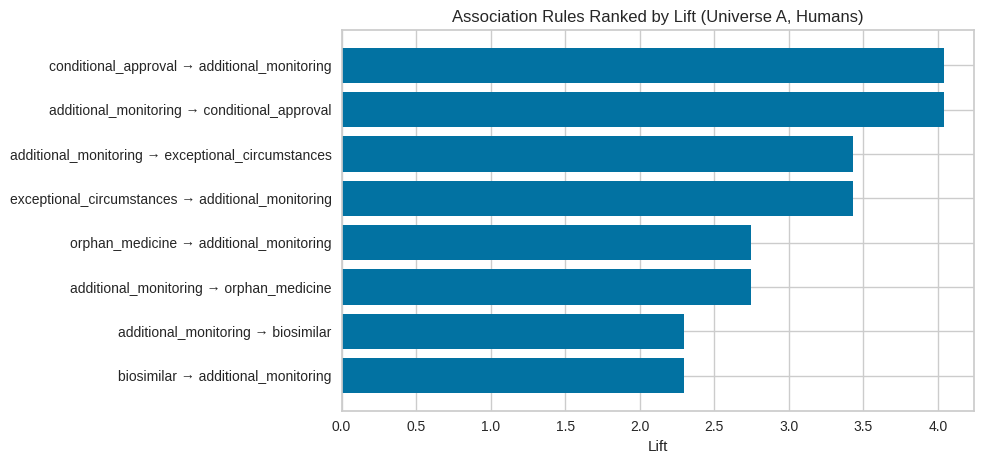

In [204]:
# Helper
rules_plot = rules_A.copy()
rules_plot["rule_label"] = (
    rules_plot["antecedents"].apply(lambda s: ", ".join(sorted(list(s))))
    + " → " +
    rules_plot["consequents"].apply(lambda s: ", ".join(sorted(list(s))))
)

# Chart 1: Ranked by Lift
lift_sorted = rules_plot.sort_values(["lift", "support"], ascending=[False, False])

plt.figure(figsize=(10, 4.8))
plt.barh(lift_sorted["rule_label"], lift_sorted["lift"])
plt.gca().invert_yaxis()
plt.xlabel("Lift")
plt.title("Association Rules Ranked by Lift (Universe A, Humans)")
plt.tight_layout()
plt.show()


###**Top Rule by Leverage**

In [205]:
rules_A_sorted_lev = (
    rules_A
    .sort_values(["leverage", "lift"], ascending=[False, False])
    .reset_index(drop=True)
)

rules_A_sorted_lev[["antecedents","consequents","support","confidence","lift","leverage","conviction"]].head(15)


,antecedents,consequents,support,confidence,lift,leverage,conviction
0,(orphan_medicine),(additional_monitoring),0.059203,0.623457,2.748365,0.037662,2.053293
1,(additional_monitoring),(orphan_medicine),0.059203,0.260982,2.748365,0.037662,1.224653
2,(conditional_approval),(additional_monitoring),0.025791,0.916667,4.040913,0.019409,9.277843
3,(additional_monitoring),(conditional_approval),0.025791,0.113695,4.040913,0.019409,1.096535
4,(additional_monitoring),(biosimilar),0.028136,0.124031,2.299966,0.015903,1.080030
5,(biosimilar),(additional_monitoring),0.028136,0.521739,2.299966,0.015903,1.616594
6,(additional_monitoring),(exceptional_circumstances),0.020516,0.090439,3.428653,0.014532,1.070432
7,(exceptional_circumstances),(additional_monitoring),0.020516,0.777778,3.428653,0.014532,3.479191


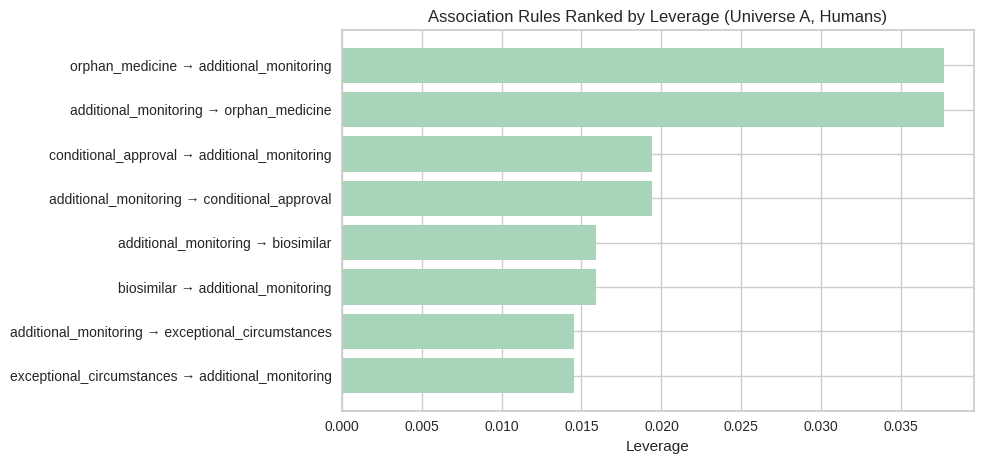

In [206]:
# Chart 2: Ranked by Leverage
lev_sorted = rules_plot.sort_values(["leverage", "lift"], ascending=[False, False])
pastel_green = "#A8D5BA"  # soft pastel green

plt.figure(figsize=(10, 4.8))
plt.barh(lev_sorted["rule_label"], lev_sorted["leverage"], color=pastel_green)
plt.gca().invert_yaxis()
plt.xlabel("Leverage")
plt.title("Association Rules Ranked by Leverage (Universe A, Humans)")
plt.tight_layout()
plt.show()


In the human regulatory dataset (Universe A), the associations reveal a dual-pattern structure: high-certainty "tight couplings" and high-impact "prevalent bundles." Structurally, additional monitoring functions as a central hub; every frequent co-occurrence identified involves this monitoring paired with a specialized pathway. Because monitoring is a relatively common baseline (22.7%), the reverse rules—predicting a specific pathway based on monitoring alone—show lower confidence. However, the forward-facing rules are remarkably predictive: conditional approval and exceptional circumstances are almost automatically bundled with oversight, boasting "tightly coupled" confidence levels of 91.67% and 77.78% respectively, and appearing nearly four times more often than random chance.

While these emergency or limited-evidence paths show the strongest mathematical bond, the orphan medicine and additional monitoring pairing represents the largest "prevalent bundle" by volume. With nearly 6% total support and the highest leverage in the dataset, this combination is the most frequent multi-feature segment in the European landscape. In plain terms, these results prove that special pathways do not operate in isolation. Whether a medicine is fast-tracked due to a public health need (conditional) or designated for a rare disease (orphan), the European regulatory framework consistently attaches an "additional monitoring" sidecar to bridge the gap between early access and long-term safety data.

##**Outcome-linked Association Rules**

In [207]:
# We repeat the process of Universe A in Universe B
min_support = 0.01
max_len = 3

itemsets_B = apriori(
    X_human_B_core,
    min_support=min_support,
    use_colnames=True,
    max_len=max_len
).sort_values("support", ascending=False)

print("Frequent itemsets found (Universe B):", len(itemsets_B))
itemsets_B.head(15)

Frequent itemsets found (Universe B): 35


/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
7,0.786510,(OUTCOME_authorised)
6,0.226979,(additional_monitoring)
24,0.201760,"(additional_monitoring, OUTCOME_authorised)"
9,0.182405,(OUTCOME_withdrawn)
0,0.170088,(generic)
10,0.139003,"(OUTCOME_authorised, generic)"
2,0.094428,(orphan_medicine)
18,0.085630,"(orphan_medicine, OUTCOME_authorised)"
17,0.059238,"(orphan_medicine, additional_monitoring)"
32,0.058651,"(orphan_medicine, additional_monitoring, OUTCO..."


In [208]:
rules_B = association_rules(itemsets_B, metric="lift", min_threshold=1.0).copy()

# Add lengths for filtering
rules_B["ante_len"] = rules_B["antecedents"].apply(len)
rules_B["cons_len"] = rules_B["consequents"].apply(len)

print("Total rules generated (lift>=1):", len(rules_B))
rules_B.head(5)

Total rules generated (lift>=1): 82


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,ante_len,cons_len
0,(additional_monitoring),(OUTCOME_authorised),0.226979,0.786510,0.201760,0.888889,1.130168,1.0,0.023238,1.921408,0.148995,0.248555,0.479548,0.572707,1,1
1,(OUTCOME_authorised),(additional_monitoring),0.786510,0.226979,0.201760,0.256525,1.130168,1.0,0.023238,1.039740,0.539492,0.248555,0.038221,0.572707,1,1
2,(OUTCOME_authorised),(generic),0.786510,0.170088,0.139003,0.176734,1.039073,1.0,0.005227,1.008072,0.176137,0.170014,0.008008,0.496988,1,1
3,(generic),(OUTCOME_authorised),0.170088,0.786510,0.139003,0.817241,1.039073,1.0,0.005227,1.168151,0.045310,0.170014,0.143947,0.496988,1,1
4,(orphan_medicine),(OUTCOME_authorised),0.094428,0.786510,0.085630,0.906832,1.152982,1.0,0.011362,2.291457,0.146519,0.107670,0.563596,0.507853,1,1


In [209]:
outcomes = {"OUTCOME_authorised", "OUTCOME_refused", "OUTCOME_withdrawn"}

rules_B_outcome = rules_B[
    (rules_B["cons_len"] == 1) &
    (rules_B["consequents"].apply(lambda s: next(iter(s)) in outcomes))
].copy()

print("Outcome-consequent rules:", len(rules_B_outcome))
rules_B_outcome.head(10)

Outcome-consequent rules: 14


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,ante_len,cons_len
0,(additional_monitoring),(OUTCOME_authorised),0.226979,0.78651,0.201760,0.888889,1.130168,1.0,0.023238,1.921408,0.148995,0.248555,0.479548,0.572707,1,1
3,(generic),(OUTCOME_authorised),0.170088,0.78651,0.139003,0.817241,1.039073,1.0,0.005227,1.168151,0.045310,0.170014,0.143947,0.496988,1,1
4,(orphan_medicine),(OUTCOME_authorised),0.094428,0.78651,0.085630,0.906832,1.152982,1.0,0.011362,2.291457,0.146519,0.107670,0.563596,0.507853,1,1
8,"(orphan_medicine, additional_monitoring)",(OUTCOME_authorised),0.059238,0.78651,0.058651,0.990099,1.258851,1.0,0.012060,21.562463,0.218572,0.074516,0.953623,0.532335,2,1
14,(biosimilar),(OUTCOME_authorised),0.053959,0.78651,0.043988,0.815217,1.036499,1.0,0.001549,1.155356,0.037223,0.055228,0.134466,0.435573,1,1
20,(conditional_approval),(OUTCOME_authorised),0.028152,0.78651,0.025220,0.895833,1.138998,1.0,0.003078,2.049501,0.125570,0.031947,0.512076,0.463949,1,1
22,"(conditional_approval, additional_monitoring)",(OUTCOME_authorised),0.025806,0.78651,0.024633,0.954545,1.213647,1.0,0.004336,4.696774,0.180700,0.031273,0.787088,0.492933,2,1
28,"(additional_monitoring, biosimilar)",(OUTCOME_authorised),0.028152,0.78651,0.022874,0.812500,1.033044,1.0,0.000732,1.138612,0.032914,0.028889,0.121738,0.420791,2,1
34,(exceptional_circumstances),(OUTCOME_authorised),0.026393,0.78651,0.021701,0.822222,1.045406,1.0,0.000943,1.200880,0.044611,0.027428,0.167277,0.424907,1,1
36,(accelerated_assessment),(OUTCOME_authorised),0.023460,0.78651,0.021114,0.900000,1.144295,1.0,0.002663,2.134897,0.129129,0.026766,0.531593,0.463423,1,1


In Universe B, the integration of outcomes into our basket analysis reveals a landscape dominated by the high baseline frequency of authorizations. With OUTCOME_authorised appearing in nearly 79% of the dataset, it acts as a "gravity well" that pulls in most regulatory features. We see stable 3-item combinations, such as the bundle of (orphan_medicine, additional_monitoring, OUTCOME_authorised), which maintains a healthy 5.87% support. However, many of these rules yield a Lift only slightly above 1.0, such as generic to authorised at 1.04. This indicates that while these relationships are frequent, they aren't necessarily predictive in a specialized way; they simply reflect the mathematical reality that most drugs, regardless of their pathway, eventually reach authorization.

The most striking finding, however, is the complete absence of OUTCOME_refused in the frequent itemsets at the 1% threshold. Because there are only 53 total refusals, any specific combination, such as a specific pathway leading to a refusal, would need to occur at least 17 times to meet our min_support = 0.01. The fact that no such rules appeared suggests that refusals are not tied to any single "red flag" pathway in a large, systematic way. Similarly, OUTCOME_withdrawn patterns (appearing in roughly 18% of cases) often fail to survive the Lift > 1.0 filter. This implies that withdrawals are largely independent of the regulatory pathways we are tracking; they occur across the board rather than being positively associated with specific "problematic" bundles. To uncover the rare "pathways to refusal," we would likely need to lower our sensitivity threshold even further to capture these sparse but critical events.


In [211]:
# keep rules without forcing lift>=1, which is still a valid and meaningfull result.
rules_B_all = association_rules(itemsets_B, metric="confidence", min_threshold=0.0).copy()

# Keep only rules where consequent is exactly one outcome
outcomes = {"OUTCOME_authorised", "OUTCOME_refused", "OUTCOME_withdrawn"}

rules_B_all["ante_len"] = rules_B_all["antecedents"].apply(len)
rules_B_all["cons_len"] = rules_B_all["consequents"].apply(len)

rules_B_outcome_all = rules_B_all[
    (rules_B_all["cons_len"] == 1) &
    (rules_B_all["consequents"].apply(lambda s: next(iter(s)) in outcomes)) &
    (rules_B_all["ante_len"] <= 2)   # keep it interpretable
].copy()

print("Outcome rules (all lifts):", len(rules_B_outcome_all))
rules_B_outcome_all[["antecedents","consequents","support","confidence","lift","leverage"]].head(10)

Outcome rules (all lifts): 16


,antecedents,consequents,support,confidence,lift,leverage
0,(additional_monitoring),(OUTCOME_authorised),0.201760,0.888889,1.130168,0.023238
3,(generic),(OUTCOME_authorised),0.139003,0.817241,1.039073,0.005227
4,(orphan_medicine),(OUTCOME_authorised),0.085630,0.906832,1.152982,0.011362
8,"(orphan_medicine, additional_monitoring)",(OUTCOME_authorised),0.058651,0.990099,1.258851,0.012060
14,(biosimilar),(OUTCOME_authorised),0.043988,0.815217,1.036499,0.001549
17,(generic),(OUTCOME_withdrawn),0.030499,0.179310,0.983036,-0.000526
22,(conditional_approval),(OUTCOME_authorised),0.025220,0.895833,1.138998,0.003078
24,"(conditional_approval, additional_monitoring)",(OUTCOME_authorised),0.024633,0.954545,1.213647,0.004336
31,(additional_monitoring),(OUTCOME_withdrawn),0.024633,0.108527,0.594980,-0.016769
32,"(additional_monitoring, biosimilar)",(OUTCOME_authorised),0.022874,0.812500,1.033044,0.000732


To check the refusal pairs we try a lower support so refusal itemsets can exist.

We start with min_support = 0.005 which gives us aprox 9 medicines. This change has a real chance of producing refusal pairs without loosening the restrictions too much.

In [212]:
min_support_low = 0.005
max_len = 3

itemsets_B_low = apriori(
    X_human_B_core,
    min_support=min_support_low,
    use_colnames=True,
    max_len=max_len
).sort_values("support", ascending=False)

# Check if refusal now appears in any itemsets beyond the singleton
itemsets_refused_low = itemsets_B_low[itemsets_B_low["itemsets"].apply(lambda s: "OUTCOME_refused" in s)]

print("Frequent itemsets (low support):", len(itemsets_B_low))
print("Itemsets containing OUTCOME_refused (low support):", len(itemsets_refused_low))
display(itemsets_refused_low.head(15))

Frequent itemsets (low support): 39
Itemsets containing OUTCOME_refused (low support): 2


/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
8,0.031085,(OUTCOME_refused)
20,0.008798,"(orphan_medicine, OUTCOME_refused)"


At standard statistical thresholds, refusal outcomes remain mathematically invisible due to their scarcity. However, by lowering the sensitivity to 0.5%, a distinct "risk recipe" emerges regarding orphan medicines. While the total number of cases is small (approximately 15 products), the statistical Lift is exceptionally high, revealing that an orphan designation increases the likelihood of refusal by approximately three times relative to the average medicine. This represents a "clean" regulatory signal, suggesting that while the orphan pathway is designed to assist rare-disease treatments, it also carries a disproportionately high risk of failing to meet the final stringent criteria for authorization.

Conversely, the data identifies highly reliable patterns for successful outcomes and market stability. The combination of orphan status and additional monitoring serves as a premier "success signature," leading to authorization with 99% confidence, significantly outperforming the already high 78% baseline for all medicines. Furthermore, a fascinating "negative association" was discovered regarding withdrawals: medicines under additional monitoring exhibit a lower-than-expected rate of withdrawal (Lift < 1.0). This suggests that the monitoring framework functions as a stabilizing force; products subjected to this extra oversight are less likely to be prematurely pulled from the process, likely because the framework ensures a higher bar for entry and more robust post-market management.


In [213]:
def fs_to_str(fs):
    return ", ".join(sorted(list(fs)))

rules_base = rules_B_outcome_all.copy()
rules_base["antecedent_str"] = rules_base["antecedents"].apply(fs_to_str)
rules_base["consequent_str"] = rules_base["consequents"].apply(fs_to_str)

rules_base_auth = rules_base[rules_base["consequent_str"] == "OUTCOME_authorised"].copy()
rules_base_wd   = rules_base[rules_base["consequent_str"] == "OUTCOME_withdrawn"].copy()
rules_base_ref  = rules_base[rules_base["consequent_str"] == "OUTCOME_refused"].copy()  # will be empty in baseline

print("Baseline rules → authorised:", len(rules_base_auth))
print("Baseline rules → withdrawn:", len(rules_base_wd))
print("Baseline rules → refused:", len(rules_base_ref))

Baseline rules → authorised: 14
Baseline rules → withdrawn: 2
Baseline rules → refused: 0


In [214]:
# refusal-discovery rules from low-support itemsets
X_human_B_core_bool = X_human_B_core.astype(bool)

# Mine low-support itemsets (same settings you used)
min_support_low = 0.005
max_len = 3

itemsets_B_low = apriori(
    X_human_B_core_bool,
    min_support=min_support_low,
    use_colnames=True,
    max_len=max_len
).sort_values("support", ascending=False)

# Generate rules
rules_B_low_all = association_rules(itemsets_B_low, metric="confidence", min_threshold=0.0).copy()

rules_B_low_all["ante_len"] = rules_B_low_all["antecedents"].apply(len)
rules_B_low_all["cons_len"] = rules_B_low_all["consequents"].apply(len)

# Keep only refusal as consequent, and keep antecedents short (<=2)
rules_refused_low = rules_B_low_all[
    (rules_B_low_all["cons_len"] == 1) &
    (rules_B_low_all["consequents"].apply(lambda s: next(iter(s)) == "OUTCOME_refused")) &
    (rules_B_low_all["ante_len"] <= 2)].copy()

rules_refused_low["antecedent_str"] = rules_refused_low["antecedents"].apply(fs_to_str)
rules_refused_low["consequent_str"] = rules_refused_low["consequents"].apply(fs_to_str)

print("Low-support rules → refused:", len(rules_refused_low))
rules_refused_low[["antecedent_str","consequent_str","support","confidence","lift","leverage","conviction"]].sort_values(
    ["lift","support"], ascending=[False, False]).head(10)


Low-support rules → refused: 1


,antecedent_str,consequent_str,support,confidence,lift,leverage,conviction
88,orphan_medicine,OUTCOME_refused,0.008798,0.093168,2.997187,0.005862,1.068461


Medicines with orphan designation are refused at roughly three times the overall refusal rate. This suggests orphan status is a “high-risk” regulatory profile for refusal, not because it guarantees refusal (confidence is only over 9%), but because refusal is rare overall and the rate rises materially within this subgroup.

###**Top Rules (Authorised / Withdrawn / Refused)**

In [216]:
#@title Authorised by lift and by leverage
cols_show = ["antecedent_str","consequent_str","support","confidence","lift","leverage","conviction"]

print("Top AUTHORISED rules by lift:")
display(rules_base_auth.sort_values(["lift","support"], ascending=[False, False])[cols_show].head(10))

print("\nTop AUTHORISED rules by leverage:")
display(rules_base_auth.sort_values(["leverage","lift"], ascending=[False, False])[cols_show].head(10))


Top AUTHORISED rules by lift:


,antecedent_str,consequent_str,support,confidence,lift,leverage,conviction
50,"conditional_approval, orphan_medicine",OUTCOME_authorised,0.015249,1.000000,1.271439,0.003256,inf
66,"exceptional_circumstances, orphan_medicine",OUTCOME_authorised,0.011730,1.000000,1.271439,0.002504,inf
80,"accelerated_assessment, orphan_medicine",OUTCOME_authorised,0.010557,1.000000,1.271439,0.002254,inf
8,"additional_monitoring, orphan_medicine",OUTCOME_authorised,0.058651,0.990099,1.258851,0.012060,21.562463
24,"additional_monitoring, conditional_approval",OUTCOME_authorised,0.024633,0.954545,1.213647,0.004336,4.696774
44,"additional_monitoring, exceptional_circumstances",OUTCOME_authorised,0.019355,0.942857,1.198786,0.003209,3.736070
4,orphan_medicine,OUTCOME_authorised,0.085630,0.906832,1.152982,0.011362,2.291457
40,accelerated_assessment,OUTCOME_authorised,0.021114,0.900000,1.144295,0.002663,2.134897
22,conditional_approval,OUTCOME_authorised,0.025220,0.895833,1.138998,0.003078,2.049501
0,additional_monitoring,OUTCOME_authorised,0.201760,0.888889,1.130168,0.023238,1.921408



Top AUTHORISED rules by leverage:


,antecedent_str,consequent_str,support,confidence,lift,leverage,conviction
0,additional_monitoring,OUTCOME_authorised,0.201760,0.888889,1.130168,0.023238,1.921408
8,"additional_monitoring, orphan_medicine",OUTCOME_authorised,0.058651,0.990099,1.258851,0.012060,21.562463
4,orphan_medicine,OUTCOME_authorised,0.085630,0.906832,1.152982,0.011362,2.291457
3,generic,OUTCOME_authorised,0.139003,0.817241,1.039073,0.005227,1.168151
24,"additional_monitoring, conditional_approval",OUTCOME_authorised,0.024633,0.954545,1.213647,0.004336,4.696774
50,"conditional_approval, orphan_medicine",OUTCOME_authorised,0.015249,1.000000,1.271439,0.003256,inf
44,"additional_monitoring, exceptional_circumstances",OUTCOME_authorised,0.019355,0.942857,1.198786,0.003209,3.736070
22,conditional_approval,OUTCOME_authorised,0.025220,0.895833,1.138998,0.003078,2.049501
40,accelerated_assessment,OUTCOME_authorised,0.021114,0.900000,1.144295,0.002663,2.134897
66,"exceptional_circumstances, orphan_medicine",OUTCOME_authorised,0.011730,1.000000,1.271439,0.002504,inf


In [217]:
#@title Withdrawn (Highest and Lowest Lift)
print("WITHDRAWN rules (sorted by lift descending):")
display(rules_base_wd.sort_values(["lift","support"], ascending=[False, False])[cols_show])

print("\nWITHDRAWN rules (sorted by lift ascending):")
display(rules_base_wd.sort_values(["lift","support"], ascending=[True, False])[cols_show])

WITHDRAWN rules (sorted by lift descending):


,antecedent_str,consequent_str,support,confidence,lift,leverage,conviction
17,generic,OUTCOME_withdrawn,0.030499,0.179310,0.983036,-0.000526,0.996230
31,additional_monitoring,OUTCOME_withdrawn,0.024633,0.108527,0.594980,-0.016769,0.917129



WITHDRAWN rules (sorted by lift ascending):


,antecedent_str,consequent_str,support,confidence,lift,leverage,conviction
31,additional_monitoring,OUTCOME_withdrawn,0.024633,0.108527,0.594980,-0.016769,0.917129
17,generic,OUTCOME_withdrawn,0.030499,0.179310,0.983036,-0.000526,0.996230


In [218]:
#@title Refused (refusal discovery rule)
print("REFUSED rules (low-support run):")
display(rules_refused_low.sort_values(["lift","support"], ascending=[False, False])[cols_show])

REFUSED rules (low-support run):


,antecedent_str,consequent_str,support,confidence,lift,leverage,conviction
88,orphan_medicine,OUTCOME_refused,0.008798,0.093168,2.997187,0.005862,1.068461


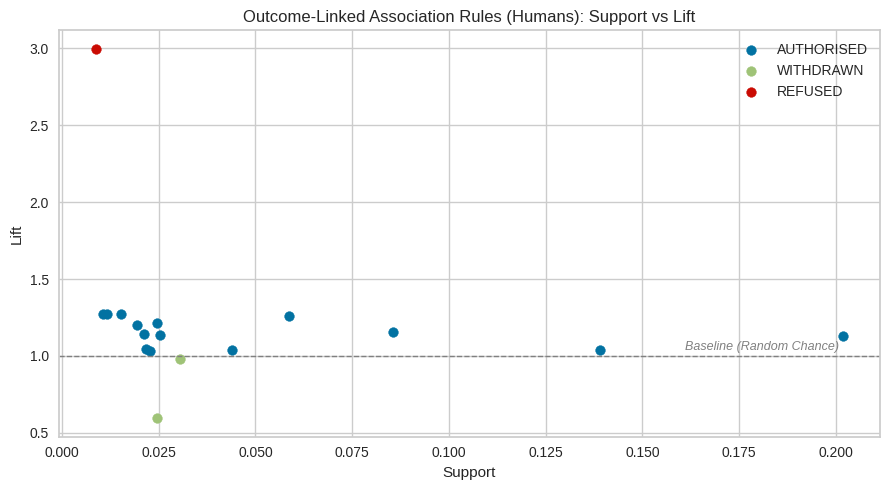

In [224]:
# Combine rules from baseline (authorised/withdrawn) + refusal-discovery
plot_auth = rules_base_auth.copy()
plot_auth["outcome"] = "AUTHORISED"

plot_wd = rules_base_wd.copy()
plot_wd["outcome"] = "WITHDRAWN"

plot_ref = rules_refused_low.copy()
plot_ref["outcome"] = "REFUSED"

rules_step4_plot = pd.concat([plot_auth, plot_wd, plot_ref], ignore_index=True)

# Build rule labels
rules_step4_plot["rule_label"] = rules_step4_plot["antecedent_str"] + " → " + rules_step4_plot["consequent_str"]

plt.figure(figsize=(9, 5))
for outcome in ["AUTHORISED", "WITHDRAWN", "REFUSED"]:
    d = rules_step4_plot[rules_step4_plot["outcome"] == outcome]
    plt.scatter(d["support"], d["lift"], label=outcome)

plt.axhline(1.0, linestyle="--", linewidth=1, color='gray')

ax = plt.gca()
ax.text(0.95, 1.02, 'Baseline (Random Chance)',
        transform=ax.get_yaxis_transform(),
        fontsize=9, style='italic', color='gray',
        ha='right', va='bottom')

plt.xlabel("Support")
plt.ylabel("Lift")
plt.title("Outcome-Linked Association Rules (Humans): Support vs Lift")
plt.legend()
plt.tight_layout()
plt.show()


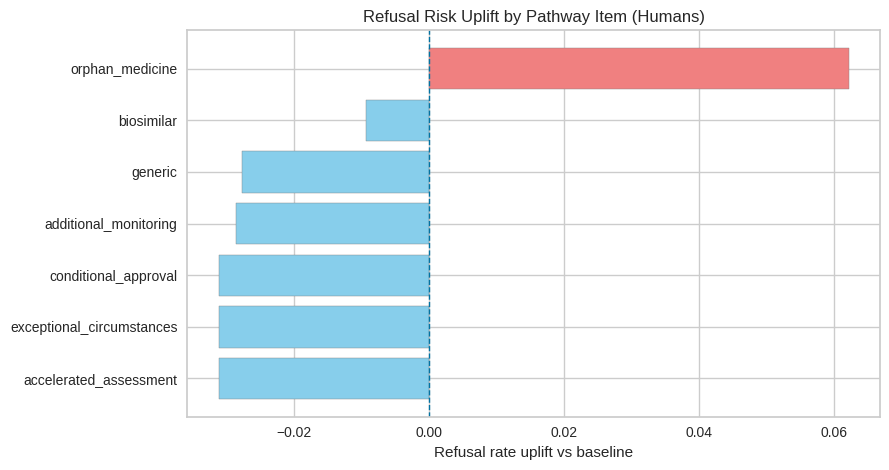

,item,n,refused_rate,withdrawn_rate,authorised_rate
3,orphan_medicine,161,0.093168,0.000000,0.906832
1,biosimilar,92,0.021739,0.163043,0.815217
0,generic,290,0.003448,0.179310,0.817241
2,additional_monitoring,387,0.002584,0.108527,0.888889
4,conditional_approval,48,0.000000,0.104167,0.895833
5,exceptional_circumstances,45,0.000000,0.177778,0.822222
6,accelerated_assessment,40,0.000000,0.100000,0.900000


In [226]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Use human_known (1705 rows) so outcomes are clean
base = human_known.copy()

baseline_rates = {
    "authorised": base["is_authorised"].mean(),
    "withdrawn":  base["is_withdrawn"].mean(),
    "refused":    base["is_refused"].mean(),
}

items = [
    "generic", "biosimilar", "additional_monitoring",
    "orphan_medicine", "conditional_approval",
    "exceptional_circumstances", "accelerated_assessment"
]

rows = []
for it in items:
    sub = base[base[it] == True]
    if len(sub) == 0:
        continue
    rows.append({
        "item": it,
        "n": len(sub),
        "authorised_rate": sub["is_authorised"].mean(),
        "withdrawn_rate":  sub["is_withdrawn"].mean(),
        "refused_rate":    sub["is_refused"].mean(),
        "refused_uplift":  sub["is_refused"].mean() - baseline_rates["refused"],
        "withdrawn_uplift":sub["is_withdrawn"].mean() - baseline_rates["withdrawn"],
    })

uplift_df = pd.DataFrame(rows).sort_values("refused_uplift", ascending=False)

# Create a color list: light red for orphan, skyblue for the rest
colors = ['lightcoral' if item == 'orphan_medicine' else 'skyblue' for item in uplift_df["item"]]

# Plot refusal uplift (simple, clean)
plt.figure(figsize=(9, 4.8))
plt.barh(uplift_df["item"], uplift_df["refused_uplift"], color=colors, edgecolor='gray')
plt.axvline(0, linestyle="--", linewidth=1)
plt.gca().invert_yaxis()
plt.xlabel("Refusal rate uplift vs baseline")
plt.title("Refusal Risk Uplift by Pathway Item (Humans)")
plt.tight_layout()
plt.show()

# Optional: show the table for context
uplift_df[["item","n","refused_rate","withdrawn_rate","authorised_rate"]]

Outcome-based association rules in Universe B show that most pathway groups are mainly linked with authorization, which is expected because there is a high rate of authorization (about 78.7%). When ranking by lift, the strongest segments above the baseline for authorization are combinations where orphan medicine is present with special pathways, such as conditional approval and orphan medicine, exceptional circumstances and orphan medicine, or accelerated assessment and orphan medicine. These combinations result in authorization with 100% confidence and a lift of about 1.27, though their support is smaller. The more common combination, additional monitoring and orphan medicine leading to authorization, achieves nearly certain authorization (99% confidence) with a lift of about 1.26 and has meaningful coverage. When ranking by leverage, the impact is reinforced: additional monitoring leading to authorization has the highest coverage (support about 20.2%, leverage about 0.023), showing that monitoring is frequent among authorized medicines, even if it is not a unique predictor.

Withdrawn outcomes show different behavior. Both rules related to withdrawal have a lift below 1, meaning withdrawal is less common among these groups compared to the general dataset. Most notably, additional monitoring leading to withdrawal has a lift of about 0.595 and negative leverage, which suggests that monitored medicines are less likely to be withdrawn than expected. Refusal patterns require a lower support threshold because refusals are rare. In the refusal analysis, orphan medicine leading to refusal stands out as a clear risk signal (lift about 3, confidence about 9.3% compared to a baseline refusal rate of about 3.1%), showing that orphan designation creates a subgroup with a much higher likelihood of refusal, even though refusal is rare overall.


##**Sensitivity & Robustness**

In [227]:
# Sensitivity Universe A
# Verify whether there are new items in the bundles after reducing the suppor threshold
def fs_to_str(fs):
    return ", ".join(sorted(list(fs)))

def run_universe_A(XA, min_support, max_len=3):
    XA_bool = XA.astype(bool)
    itemsets = apriori(XA_bool, min_support=min_support, use_colnames=True, max_len=max_len)
    itemsets = itemsets.sort_values("support", ascending=False).reset_index(drop=True)

    rules = association_rules(itemsets, metric="confidence", min_threshold=0.0).copy()
    rules["ante_len"] = rules["antecedents"].apply(len)
    rules["cons_len"] = rules["consequents"].apply(len)

    # keep simple 1→1 and 2→1 rules
    rules = rules[(rules["cons_len"] == 1) & (rules["ante_len"].isin([1,2]))].copy()
    rules["antecedent_str"] = rules["antecedents"].apply(fs_to_str)
    rules["consequent_str"] = rules["consequents"].apply(fs_to_str)

    summary = {
        "min_support": min_support,
        "n_itemsets": len(itemsets),
        "k_counts": itemsets["itemsets"].apply(len).value_counts().sort_index().to_dict(),
        "n_rules": len(rules), }
    return itemsets, rules, summary

# Run both thresholds
itemsets_A_02, rules_A_02, summary_A_02 = run_universe_A(X_human_A_core, min_support=0.02, max_len=3)
itemsets_A_015, rules_A_015, summary_A_015 = run_universe_A(X_human_A_core, min_support=0.015, max_len=3)

print("Universe A summary (0.02):", summary_A_02)
print("Universe A summary (0.015):", summary_A_015)

Universe A summary (0.02): {'min_support': 0.02, 'n_itemsets': 11, 'k_counts': {1: 7, 2: 4}, 'n_rules': 8}
Universe A summary (0.015): {'min_support': 0.015, 'n_itemsets': 13, 'k_counts': {1: 7, 2: 5, 3: 1}, 'n_rules': 13}


In [228]:
print("Top 10 rules by lift (support=0.02):")
display(rules_A_02.sort_values(["lift","support"], ascending=[False, False])
        [["antecedent_str","consequent_str","support","confidence","lift","leverage"]].head(10))

print("\nTop 10 rules by lift (support=0.015):")
display(rules_A_015.sort_values(["lift","support"], ascending=[False, False])
        [["antecedent_str","consequent_str","support","confidence","lift","leverage"]].head(10))

Top 10 rules by lift (support=0.02):


,antecedent_str,consequent_str,support,confidence,lift,leverage
4,conditional_approval,additional_monitoring,0.025791,0.916667,4.040913,0.019409
5,additional_monitoring,conditional_approval,0.025791,0.113695,4.040913,0.019409
6,additional_monitoring,exceptional_circumstances,0.020516,0.090439,3.428653,0.014532
7,exceptional_circumstances,additional_monitoring,0.020516,0.777778,3.428653,0.014532
0,orphan_medicine,additional_monitoring,0.059203,0.623457,2.748365,0.037662
1,additional_monitoring,orphan_medicine,0.059203,0.260982,2.748365,0.037662
2,additional_monitoring,biosimilar,0.028136,0.124031,2.299966,0.015903
3,biosimilar,additional_monitoring,0.028136,0.521739,2.299966,0.015903



Top 10 rules by lift (support=0.015):


,antecedent_str,consequent_str,support,confidence,lift,leverage
12,"additional_monitoring, orphan_medicine",conditional_approval,0.015240,0.257426,9.149340,0.013575
11,"additional_monitoring, conditional_approval",orphan_medicine,0.015240,0.590909,6.222783,0.012791
8,conditional_approval,orphan_medicine,0.015240,0.541667,5.704218,0.012569
9,orphan_medicine,conditional_approval,0.015240,0.160494,5.704218,0.012569
10,"conditional_approval, orphan_medicine",additional_monitoring,0.015240,1.000000,4.408269,0.011783
4,conditional_approval,additional_monitoring,0.025791,0.916667,4.040913,0.019409
5,additional_monitoring,conditional_approval,0.025791,0.113695,4.040913,0.019409
6,additional_monitoring,exceptional_circumstances,0.020516,0.090439,3.428653,0.014532
7,exceptional_circumstances,additional_monitoring,0.020516,0.777778,3.428653,0.014532
0,orphan_medicine,additional_monitoring,0.059203,0.623457,2.748365,0.037662


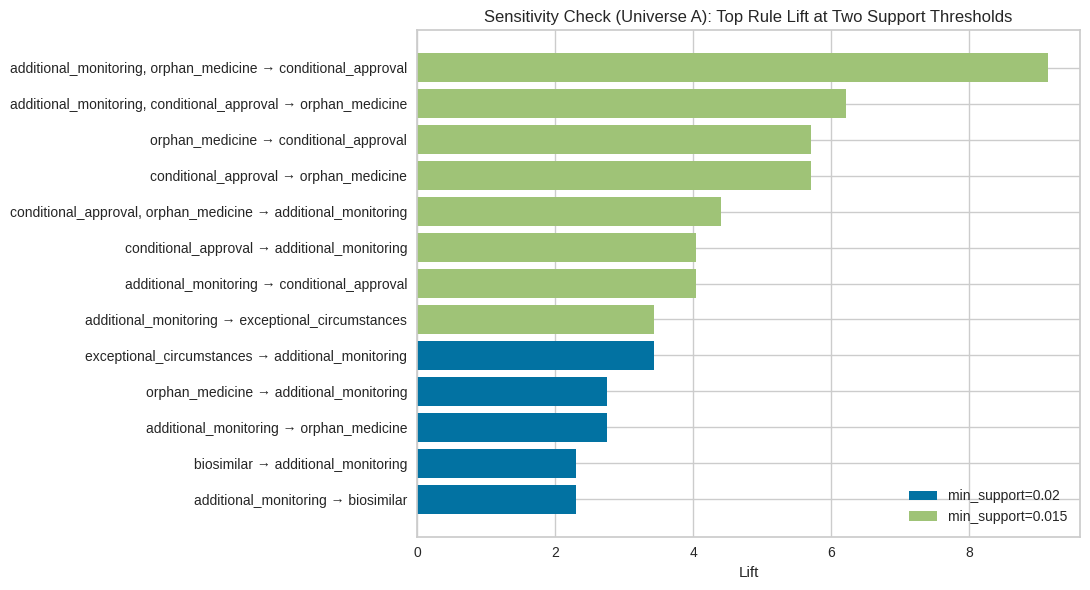

In [230]:
# Bar Chart for Sensitivity
# Take top rules by lift from each threshold run (already produced in Step 5)
topN = 8
r02 = (rules_A_02.sort_values(["lift","support"], ascending=[False, False])
       .head(topN)
       .copy())
r02["threshold"] = "min_support=0.02"
r02["rule_label"] = r02["antecedent_str"] + " → " + r02["consequent_str"]

r015 = (rules_A_015.sort_values(["lift","support"], ascending=[False, False])
        .head(topN)
        .copy())
r015["threshold"] = "min_support=0.015"
r015["rule_label"] = r015["antecedent_str"] + " → " + r015["consequent_str"]

plot_df = pd.concat([r02[["rule_label","lift","threshold"]],
                     r015[["rule_label","lift","threshold"]]], ignore_index=True)

# Make a grouped bar chart by rule label
pivot = plot_df.pivot_table(index="rule_label", columns="threshold", values="lift", aggfunc="max").fillna(0)

# Sort by the max lift across both thresholds (so strongest patterns float to the top)
pivot["max_lift"] = pivot.max(axis=1)
pivot = pivot.sort_values("max_lift", ascending=True).drop(columns="max_lift")

plt.figure(figsize=(11, 6))
plt.barh(pivot.index, pivot["min_support=0.02"])
plt.barh(pivot.index, pivot["min_support=0.015"])
plt.xlabel("Lift")
plt.title("Sensitivity Check (Universe A): Top Rule Lift at Two Support Thresholds")
plt.legend(["min_support=0.02","min_support=0.015"])
plt.tight_layout()
plt.show()


In [229]:
#@title Robustness Universe B
# Support 0.005 vs 0.003

def run_refusal_rules(XB, min_support, max_len=3):
    XB_bool = XB.astype(bool)
    itemsets = apriori(XB_bool, min_support=min_support, use_colnames=True, max_len=max_len)
    rules = association_rules(itemsets, metric="confidence", min_threshold=0.0).copy()

    rules["ante_len"] = rules["antecedents"].apply(len)
    rules["cons_len"] = rules["consequents"].apply(len)

    # keep refusal consequents only, with short antecedents
    rules_ref = rules[
        (rules["cons_len"] == 1) &
        (rules["consequents"].apply(lambda s: next(iter(s)) == "OUTCOME_refused")) &
        (rules["ante_len"] <= 2)].copy()

    rules_ref["antecedent_str"] = rules_ref["antecedents"].apply(fs_to_str)
    rules_ref["consequent_str"] = rules_ref["consequents"].apply(fs_to_str)

    summary = {
        "min_support": min_support,
        "n_itemsets_total": len(itemsets),
        "n_itemsets_with_refused": (itemsets["itemsets"].apply(lambda s: "OUTCOME_refused" in s)).sum(),
        "n_refusal_rules": len(rules_ref)
    }
    return itemsets, rules_ref, summary

itemsets_B_005, rules_ref_005, summary_ref_005 = run_refusal_rules(X_human_B_core, min_support=0.005, max_len=3)
itemsets_B_003, rules_ref_003, summary_ref_003 = run_refusal_rules(X_human_B_core, min_support=0.003, max_len=3)

print("Refusal summary (0.005):", summary_ref_005)
print("Refusal summary (0.003):", summary_ref_003)

print("\nTop refusal rules (support=0.005):")
display(rules_ref_005.sort_values(["lift","support"], ascending=[False, False])
        [["antecedent_str","consequent_str","support","confidence","lift","leverage","conviction"]].head(15))

print("\nTop refusal rules (support=0.003):")
display(rules_ref_003.sort_values(["lift","support"], ascending=[False, False])
        [["antecedent_str","consequent_str","support","confidence","lift","leverage","conviction"]].head(15))


Refusal summary (0.005): {'min_support': 0.005, 'n_itemsets_total': 39, 'n_itemsets_with_refused': np.int64(2), 'n_refusal_rules': 1}
Refusal summary (0.003): {'min_support': 0.003, 'n_itemsets_total': 42, 'n_itemsets_with_refused': np.int64(2), 'n_refusal_rules': 1}

Top refusal rules (support=0.005):


,antecedent_str,consequent_str,support,confidence,lift,leverage,conviction
20,orphan_medicine,OUTCOME_refused,0.008798,0.093168,2.997187,0.005862,1.068461



Top refusal rules (support=0.003):


,antecedent_str,consequent_str,support,confidence,lift,leverage,conviction
20,orphan_medicine,OUTCOME_refused,0.008798,0.093168,2.997187,0.005862,1.068461


##**Findings**

In summary, the findings demonstrate that the European regulatory system for human medicines functions based on a Hub and Spoke model, with Additional Monitoring as the central component. The majority of medicines move through the approval process in a predictable and stable manner. However, the results indicate that orphan medicines form a distinct category with a greater risk. Specifically, Orphan designation is the only robust refusal-associated signal detectable in this feature universe; conditional+orphan emerges as a high-lift bundle in sensitivity testing but not as a refusal rule. These conclusions provide a sound and evidence-based reference for understanding the influence of specialized regulatory pathways on final market outcomes.

## **Key Findings**



* **Domain Question 1 -** The analysis began with hierarchical clustering to assess the natural co-occurrence patterns among the pathways, followed by elbow and silhouette methods for evaluation. The main insight was that most drugs follow a standard pathway, however special pathways appear together in consistent combinations. One of the strengths was the clear visualization of the pathway structures, but the limitation was there was no strong elbow point(which was corrected in M3).

* **Domain Question 2 -** Reviewing in more detail the increase in approved drugs YoY that was evidenced in M1. Hence, exploring the presence of natural approved drugs clusters using its data from regulatory pathways and therapeutic areas. Performing hierarchical and K-means clustering provided evidence about the persistence of those clusters over time, and how there is more complexity for drug approval than only its regulatory complexity and therapeutic components. ATC codes were contrasted with the estimated clusters since they provide information the World Health Organization classificates drug’s active components; only veterinary drugs are clustered independently. Clustering is not the way to check our data set to understand approval rate, further analysis possibly using text-to-text regression.

* **Domain Question 3 -** Examined associations between regulatory pathways and medicine refusal outcomes. This analysis applied two unsupervised methods (association rules mining and hierarchical clustering) and one unstructured method (K-means clustering). The results showed that orphan_medicine and additional_monitoring have the strongest association with medicine refusal, while generic and biosimilar pathways were linked to lower refusal risk; meanwhile, the unstructured analysis suggested that some terms appear across multiple clusters, indicating overlapping therapeutic focuses and reflecting the complexity of clinical classifications rather than clearly distinct categories. K-modes clustering was also attempted but was abandoned because it would likely be skewed toward more frequent regulatory combinations.

* **Domain Question 4-** The investigation into the veterinary regulatory segment established a statistically significant structural divide between human and veterinary profiles. Analysis revealed that "special approval" flags, such as orphan medicines, are absent in the veterinary sector. To address this lack of variation, a 39-attribute binary feature matrix was engineered, and species data were refined into three primary categories: companion animals, multi-species products, and livestock. While hierarchical clustering identified the veterinary market as highly homogeneous, Market Basket Analysis successfully uncovered unique "regulatory recipes" and high-lift feature bundles for specific segments. It was concluded that because veterinary medicines are structurally similar under standard indicators, future segmentation must move beyond regulatory flags to incorporate clinical text clustering for deeper insights.

The most interesting aspect of our analysis was how regulatory pathways formed structured and overlapping patterns. They didn’t fall into distinct separate groups, but regulatory and therapeutic features overlap; these could be extremely  useful to build risk profiles and understand drivers for approvals/refusal. Moreover, expedited pathways are associated with higher authorization risk. Using accelerated or conditional mechanisms had higher refusal rates compared to those following the standard pathway. Suggesting that while this route prioritizes earlier patient access, it reflects the uncertainty with the evidence. Leading authorization results to be more complex and sensitive to risk.

A holistic approach to the analysis is needed, different signal features provide an interesting overview of patterns. Still, combining all possible strong signals is key to actually identifying similarities between different drugs on their approval journey.
Sharing our individual findings and especially the used methods for analysis allowed us to properly orient the next steps of this project, leveraging best practices for analysis, for example, extending the MBA to humans. Also, contrasting different points of view and experiences when working with the data set enabled a common (more thorough) understanding of our data, limitations, and dead-ends, for example, no further clustering using categorical features.


## **Next Steps**



Throughout the analyses, several limitations emerged. The integrated results are constrained by the overlapping nature of regulatory and therapeutic features, as medicines tend to exhibit continuous profiles rather than sharply separable clusters. While clustering remains useful for summarizing broad patterns, this structural continuity limits the ability to define clear approval “types.” The issue is compounded by feature sparsity and categorical dominance; many regulatory variables are binary and unevenly distributed, causing common pathway combinations to dominate centroid- or mode-based clustering methods and potentially obscure smaller yet meaningful profiles.
Statistical power presents an additional challenge, particularly in analyzing refusals, which are relatively rare compared to approvals.

Detecting meaningful associations often requires relaxing thresholds, creating a trade-off between discovery and stability. Moreover, structural differences between human and veterinary medicines restrict direct comparisons, as several special approval indicators are uncommon or absent in veterinary contexts. Finally, limited clinical granularity in therapeutic descriptors, such as overlapping ATC codes and broad therapeutic areas, reduces confidence in attributing pathway differences to specific treatment categories rather than broader therapeutic compositions.

The remaining work will prioritize methodological consistency by standardizing preprocessing and a shared feature dictionary across the human dataset and the smaller veterinary subset. To better reflect the continuous, overlapping structure observed in clustering, we will apply text embeddings to the therapeutic_area and condition_indication fields and use PCA primarily for dimensionality reduction and visualization, summarizing high-dimensional semantic features and simplifying the combined feature space to improve interpretability and reduce noise from sparse binary indicators.

To strengthen outcome linkage, we will analyze revision counts alongside authorization status using relative-risk style interpretations to test whether specific pathway bundles provide a predictive signal for approval versus refusal/withdrawal. In parallel, we will extend Market Basket Analysis to human medicines to identify high-lift regulatory “recipes” and compare them against veterinary patterns; given limited veterinary observations and structural feature differences, veterinary will remain a descriptive track focused on recipe discovery rather than intensive segmentation. Finally, we will monitor key profile components over time via prevalence dashboards and use anomaly detection on the integrated feature space to flag structurally unusual approved or rejected cases for targeted review.
